In [1]:
import json, warnings, random
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

def check_pkg(name):
    try:
        __import__(name)
        return True
    except ImportError:
        return False

for pkg in ["sklearn", "lightgbm", "xgboost", "catboost", "shap", "matplotlib", "joblib", "scipy"]:
    print(f"{pkg:12s} available: {check_pkg(pkg)}")

sklearn      available: True
lightgbm     available: True
xgboost      available: True
catboost     available: False
shap         available: True
matplotlib   available: True
joblib       available: True
scipy        available: True


In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (10, 5)
matplotlib.rcParams["axes.grid"] = True

ARTIFACT_DIR = "artifacts"
COST_DATASET_PATH = f"{ARTIFACT_DIR}/datasets/cost_model_dataset.parquet"
SCHEDULE_DATASET_PATH = f"{ARTIFACT_DIR}/datasets/schedule_model_dataset.parquet"
FEATURE_METADATA_PATH = f"{ARTIFACT_DIR}/metadata/feature_metadata.json"
TARGET_METADATA_PATH = f"{ARTIFACT_DIR}/metadata/target_metadata.json"

PROJECT_ID_COL = "project_id"
REPORT_DATE_COL = "report_date"
SPLIT_COL = "split"

COST_TARGET_COL = "future_cost_overrun_12m"
SCHEDULE_TARGET_COL = "future_schedule_overrun_12m"

RECALL_TARGET = 0.80  # early-warning threshold-selection goal, validated on VALIDATION only, never test

print("Config set.")

Config set.


In [3]:
with open(FEATURE_METADATA_PATH) as f:
    feature_metadata = json.load(f)
with open(TARGET_METADATA_PATH) as f:
    target_metadata = json.load(f)

COST_FEATURES = feature_metadata["cost_features"]
SCHEDULE_FEATURES = feature_metadata["schedule_features"]
IDENTIFIER_COLS = feature_metadata["identifier_cols"]

print("Cost features:", len(COST_FEATURES))
print("Schedule features:", len(SCHEDULE_FEATURES))
print("\nTarget metadata:")
print(json.dumps(target_metadata, indent=2))

Cost features: 53
Schedule features: 44

Target metadata:
{
  "primary_horizon_months": 12,
  "cost_target": {
    "definition": "1 if latest_cost > original_cost at any fully-observed future report within 12 months of T, for projects not already overrun at T",
    "eligibility_rule": "cost_calendar_eligible & cost_target_fully_observed & ~already_overrun_at_T",
    "excluded_already_overrun_rows": 42118
  },
  "schedule_target": {
    "definition": "1 if latest_commissioning moves to a later period at any fully-observed future report within 12 months of T",
    "regime_start": "2021-01",
    "regime_note": "Pre-2021 excluded: per-row commissioning-date update frequency itself trended up 10x from 2016-2024, causing informative-censoring-style inflation of the target near the panel edge and a measurement-intensity confound in earlier years. 2021+ chosen as the most stable of {2019,2020,2021} tested regimes; residual mild drift (8.9%->19.1% touch-rate, 2021-2024) remains and should be mo

In [4]:
cost_df = pd.read_parquet(COST_DATASET_PATH)
schedule_df = pd.read_parquet(SCHEDULE_DATASET_PATH)

print("Cost dataset:", cost_df.shape)
print("Schedule dataset:", schedule_df.shape)

# Re-verify: every feature column listed in metadata actually exists in the loaded parquet
missing_cost_cols = [c for c in COST_FEATURES if c not in cost_df.columns]
missing_sched_cols = [c for c in SCHEDULE_FEATURES if c not in schedule_df.columns]
print("\nMissing cost feature columns (should be empty):", missing_cost_cols)
print("Missing schedule feature columns (should be empty):", missing_sched_cols)

assert not missing_cost_cols and not missing_sched_cols

Cost dataset: (81646, 59)
Schedule dataset: (44233, 50)

Missing cost feature columns (should be empty): []
Missing schedule feature columns (should be empty): []


In [5]:
# Re-confirm target-derived columns are NOT present in the feature matrices (defensive re-check,
# independent of Notebook 01's own assertion, since this is a fresh process/session)
LEAKAGE_FORBIDDEN = [
    "future_cost_overrun_12m", "future_schedule_overrun_12m", "cost_target_observed",
    "schedule_target_observed", "cost_target_fully_observed", "schedule_target_fully_observed",
    "already_overrun_at_T", "cost_model_eligible", "schedule_model_eligible",
]
assert not (set(COST_FEATURES) & set(LEAKAGE_FORBIDDEN))
assert not (set(SCHEDULE_FEATURES) & set(LEAKAGE_FORBIDDEN))
print("Leakage re-check PASSED: no forbidden columns in either feature list.")

Leakage re-check PASSED: no forbidden columns in either feature list.


In [6]:
# Re-derive splits as arrays for convenience; confirm calendar ordering holds in THIS loaded copy too
for name, d in [("cost", cost_df), ("schedule", schedule_df)]:
    print(f"--- {name} ---")
    bounds = d.groupby(SPLIT_COL)[REPORT_DATE_COL].agg(["min", "max", "count"])
    print(bounds)
    print()

cost_train = cost_df[cost_df[SPLIT_COL] == "train"]
cost_val = cost_df[cost_df[SPLIT_COL] == "validation"]
cost_test = cost_df[cost_df[SPLIT_COL] == "test"]

sched_train = schedule_df[schedule_df[SPLIT_COL] == "train"]
sched_val = schedule_df[schedule_df[SPLIT_COL] == "validation"]
sched_test = schedule_df[schedule_df[SPLIT_COL] == "test"]

print("Cost splits — train/val/test rows:", len(cost_train), len(cost_val), len(cost_test))
print("Schedule splits — train/val/test rows:", len(sched_train), len(sched_val), len(sched_test))

--- cost ---
                  min      max  count
split                                
scoring_only  2025-07  2025-07    419
test          2023-01  2024-11  11119
train         2016-04  2021-12  62783
validation    2022-01  2022-12   7325

--- schedule ---
                min      max  count
split                              
test        2023-01  2024-11  19605
train       2021-01  2021-12  13293
validation  2022-01  2022-12  11335

Cost splits — train/val/test rows: 62783 7325 11119
Schedule splits — train/val/test rows: 13293 11335 19605


In [16]:
# Categorical vs numeric feature typing - needed before any model can consume these
_is_categorical = lambda series: (
    series.dtype == object or series.dtype.name in {"bool", "category", "str", "string"}
)
cost_categorical = [c for c in COST_FEATURES if _is_categorical(cost_df[c])]
cost_numeric = [c for c in COST_FEATURES if c not in cost_categorical]

sched_categorical = [c for c in SCHEDULE_FEATURES if _is_categorical(schedule_df[c])]
sched_numeric = [c for c in SCHEDULE_FEATURES if c not in sched_categorical]

print("Cost - categorical:", cost_categorical)
print("Cost - numeric count:", len(cost_numeric))
print("\nSchedule - categorical:", sched_categorical)
print("Schedule - numeric count:", len(sched_numeric))

print("\nCardinality of categorical features (cost):")
print(cost_df[cost_categorical].nunique())

Cost - categorical: ['agency', 'is_overdue_at_T', 'ministry_available', 'ministry_department', 'original_cost_unstable_project', 'physical_progress_available', 'sector', 'sector_available', 'spend_progress_gap_available', 'state']
Cost - numeric count: 43

Schedule - categorical: ['agency', 'current_schedule_revision', 'is_overdue_at_T', 'ministry_available', 'ministry_department', 'original_cost_unstable_project', 'sector', 'sector_available', 'spend_progress_gap_available', 'state']
Schedule - numeric count: 34

Cardinality of categorical features (cost):
agency                            1014
is_overdue_at_T                      2
ministry_available                   2
ministry_department                 14
original_cost_unstable_project       2
physical_progress_available          2
sector                              22
sector_available                     2
spend_progress_gap_available         2
state                               38
dtype: int64


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

from pandas.api.types import is_numeric_dtype

def frequency_encode(train_series, *other_series):
    freq_map = train_series.value_counts(normalize=True)
    return [s.map(freq_map).fillna(0) for s in (train_series, *other_series)]

def build_baseline_matrix(df_train, df_val, df_test, numeric_cols, categorical_cols):
    numeric_cols = [c for c in numeric_cols if is_numeric_dtype(df_train[c]) and df_train[c].dtype.name != "bool"]
    encoded_cols = list(categorical_cols) + [
        c for c in COST_FEATURES + SCHEDULE_FEATURES
        if c in df_train.columns and c not in numeric_cols and c not in categorical_cols
    ]
    encoded_cols = list(dict.fromkeys(encoded_cols))

    X_train = df_train[numeric_cols].copy()
    X_val = df_val[numeric_cols].copy()
    X_test = df_test[numeric_cols].copy()

    for col in encoded_cols:
        if df_train[col].dtype.name == "bool":
            X_train[col] = df_train[col].astype(float)
            X_val[col] = df_val[col].astype(float)
            X_test[col] = df_test[col].astype(float)
        else:
            enc_train, enc_val, enc_test = frequency_encode(df_train[col], df_val[col], df_test[col])
            X_train[f"{col}_freq"] = enc_train
            X_val[f"{col}_freq"] = enc_val
            X_test[f"{col}_freq"] = enc_test

    medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(medians).fillna(0)
    X_val = X_val.fillna(medians).fillna(0)
    X_test = X_test.fillna(medians).fillna(0)

    all_nan_cols = medians[medians.isna()].index.tolist()
    return X_train, X_val, X_test, all_nan_cols

Xc_train, Xc_val, Xc_test, cost_all_nan_cols = build_baseline_matrix(cost_train, cost_val, cost_test, cost_numeric, cost_categorical)
yc_train = cost_train[COST_TARGET_COL].values
yc_val = cost_val[COST_TARGET_COL].values
yc_test = cost_test[COST_TARGET_COL].values

print("Baseline matrix shapes:", Xc_train.shape, Xc_val.shape, Xc_test.shape)
print("Any remaining NaNs in train matrix:", Xc_train.isna().sum().sum())
print("Columns that were entirely NaN in train (filled with 0, effectively uninformative for this baseline):", cost_all_nan_cols)

Baseline matrix shapes: (62783, 53) (7325, 53) (11119, 53)
Any remaining NaNs in train matrix: 0
Columns that were entirely NaN in train (filled with 0, effectively uninformative for this baseline): ['physical_progress_pct', 'physical_progress_pct_lag12m', 'physical_progress_pct_lag3m', 'physical_progress_pct_lag6m', 'physical_progress_velocity_12m', 'physical_progress_velocity_3m', 'physical_progress_velocity_6m', 'spend_progress_gap_physical']


In [40]:
def evaluate_binary(y_true, y_prob, label):
    auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    print(f"{label:30s} ROC-AUC={auc:.4f}  PR-AUC={pr_auc:.4f}  Brier={brier:.4f}")
    return {"label": label, "roc_auc": auc, "pr_auc": pr_auc, "brier": brier}

cost_baseline_results = []

# 1. Majority-class baseline
dummy = DummyClassifier(strategy="prior", random_state=RANDOM_STATE).fit(Xc_train, yc_train)
cost_baseline_results.append(evaluate_binary(yc_test, dummy.predict_proba(Xc_test)[:, 1], "Majority-class (test)"))

# 2. Logistic regression
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced")
logreg.fit(Xc_train, yc_train)
cost_baseline_results.append(evaluate_binary(yc_test, logreg.predict_proba(Xc_test)[:, 1], "Logistic Regression (test)"))

# 3. Shallow decision tree
tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE, class_weight="balanced")
tree.fit(Xc_train, yc_train)
cost_baseline_results.append(evaluate_binary(yc_test, tree.predict_proba(Xc_test)[:, 1], "Decision Tree depth=4 (test)"))

pd.DataFrame(cost_baseline_results)

Majority-class (test)          ROC-AUC=0.5000  PR-AUC=0.1258  Brier=0.1103
Logistic Regression (test)     ROC-AUC=0.6305  PR-AUC=0.2164  Brier=0.2933
Decision Tree depth=4 (test)   ROC-AUC=0.6126  PR-AUC=0.1562  Brier=0.2641


,label,roc_auc,pr_auc,brier
0,Majority-class (test),0.5000,0.1258,0.1103
1,Logistic Regression (test),0.6305,0.2164,0.2933
2,Decision Tree depth=4 (test),0.6126,0.1562,0.2641


In [41]:
Xs_train, Xs_val, Xs_test, sched_all_nan_cols = build_baseline_matrix(sched_train, sched_val, sched_test, sched_numeric, sched_categorical)
ys_train = sched_train[SCHEDULE_TARGET_COL].values
ys_val = sched_val[SCHEDULE_TARGET_COL].values
ys_test = sched_test[SCHEDULE_TARGET_COL].values

print("Schedule baseline matrix shapes:", Xs_train.shape, Xs_val.shape, Xs_test.shape)
print("Columns entirely NaN in schedule train:", sched_all_nan_cols)

schedule_baseline_results = []
dummy_s = DummyClassifier(strategy="prior", random_state=RANDOM_STATE).fit(Xs_train, ys_train)
schedule_baseline_results.append(evaluate_binary(ys_test, dummy_s.predict_proba(Xs_test)[:, 1], "Majority-class (test)"))

logreg_s = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced")
logreg_s.fit(Xs_train, ys_train)
schedule_baseline_results.append(evaluate_binary(ys_test, logreg_s.predict_proba(Xs_test)[:, 1], "Logistic Regression (test)"))

tree_s = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE, class_weight="balanced")
tree_s.fit(Xs_train, ys_train)
schedule_baseline_results.append(evaluate_binary(ys_test, tree_s.predict_proba(Xs_test)[:, 1], "Decision Tree depth=4 (test)"))

pd.DataFrame(schedule_baseline_results)

Schedule baseline matrix shapes: (13293, 44) (11335, 44) (19605, 44)
Columns entirely NaN in schedule train: ['spend_progress_gap_physical']
Majority-class (test)          ROC-AUC=0.5000  PR-AUC=0.7117  Brier=0.2058
Logistic Regression (test)     ROC-AUC=0.6694  PR-AUC=0.8170  Brier=0.2465
Decision Tree depth=4 (test)   ROC-AUC=0.7498  PR-AUC=0.8481  Brier=0.2010


,label,roc_auc,pr_auc,brier
0,Majority-class (test),0.5000,0.7117,0.2058
1,Logistic Regression (test),0.6694,0.8170,0.2465
2,Decision Tree depth=4 (test),0.7498,0.8481,0.2010


In [21]:
import lightgbm as lgb
import xgboost as xgb

def build_tree_matrix(df_in, numeric_cols, categorical_cols):
    X = df_in[numeric_cols + categorical_cols].copy()
    for col in categorical_cols:
        if X[col].dtype.name != "bool":
            X[col] = X[col].astype("string").fillna("__MISSING__").astype("category")
    return X

Xc_train_tree = build_tree_matrix(cost_train, cost_numeric, cost_categorical)
Xc_val_tree = build_tree_matrix(cost_val, cost_numeric, cost_categorical)
Xc_test_tree = build_tree_matrix(cost_test, cost_numeric, cost_categorical)

for col in cost_categorical:
    if Xc_train_tree[col].dtype.name == "category":
        cats = Xc_train_tree[col].cat.categories
        Xc_val_tree[col] = Xc_val_tree[col].cat.set_categories(cats)
        Xc_test_tree[col] = Xc_test_tree[col].cat.set_categories(cats)

print(Xc_train_tree.shape, Xc_val_tree.shape, Xc_test_tree.shape)
print(Xc_train_tree.dtypes.value_counts())

(62783, 53) (7325, 53) (11119, 53)
float64     40
bool         6
int64        3
category     2
category     1
category     1
Name: count, dtype: int64


In [22]:
lgb_cost = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.03, num_leaves=31, max_depth=-1,
    min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
)
lgb_cost.fit(
    Xc_train_tree, yc_train,
    eval_set=[(Xc_val_tree, yc_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
print("Best iteration:", lgb_cost.best_iteration_)

cost_lgb_results = []
cost_lgb_results.append(evaluate_binary(yc_train, lgb_cost.predict_proba(Xc_train_tree)[:, 1], "LightGBM (train)"))
cost_lgb_results.append(evaluate_binary(yc_val, lgb_cost.predict_proba(Xc_val_tree)[:, 1], "LightGBM (validation)"))
cost_lgb_results.append(evaluate_binary(yc_test, lgb_cost.predict_proba(Xc_test_tree)[:, 1], "LightGBM (test)"))
pd.DataFrame(cost_lgb_results)

Best iteration: 557
LightGBM (train)               ROC-AUC=0.9971  PR-AUC=0.9774  Brier=0.0320
LightGBM (validation)          ROC-AUC=0.7560  PR-AUC=0.4075  Brier=0.1024
LightGBM (test)                ROC-AUC=0.6730  PR-AUC=0.2424  Brier=0.1388


,label,roc_auc,pr_auc,brier
0,LightGBM (train),0.9971,0.9774,0.0320
1,LightGBM (validation),0.7560,0.4075,0.1024
2,LightGBM (test),0.6730,0.2424,0.1388


In [23]:
xgb_cost = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(yc_train == 0).sum() / (yc_train == 1).sum(),
    random_state=RANDOM_STATE, eval_metric="auc",
    enable_categorical=True, early_stopping_rounds=50,
)
xgb_cost.fit(Xc_train_tree, yc_train, eval_set=[(Xc_val_tree, yc_val)], verbose=False)
print("Best iteration:", xgb_cost.best_iteration)

cost_xgb_results = []
cost_xgb_results.append(evaluate_binary(yc_train, xgb_cost.predict_proba(Xc_train_tree)[:, 1], "XGBoost (train)"))
cost_xgb_results.append(evaluate_binary(yc_val, xgb_cost.predict_proba(Xc_val_tree)[:, 1], "XGBoost (validation)"))
cost_xgb_results.append(evaluate_binary(yc_test, xgb_cost.predict_proba(Xc_test_tree)[:, 1], "XGBoost (test)"))
pd.DataFrame(cost_xgb_results)

Best iteration: 311
XGBoost (train)                ROC-AUC=0.9689  PR-AUC=0.8507  Brier=0.0837
XGBoost (validation)           ROC-AUC=0.7300  PR-AUC=0.3540  Brier=0.1415
XGBoost (test)                 ROC-AUC=0.6511  PR-AUC=0.2054  Brier=0.1657


,label,roc_auc,pr_auc,brier
0,XGBoost (train),0.9689,0.8507,0.0837
1,XGBoost (validation),0.7300,0.3540,0.1415
2,XGBoost (test),0.6511,0.2054,0.1657


In [24]:
importance_df = pd.DataFrame({
    "feature": Xc_train_tree.columns,
    "lgb_importance": lgb_cost.feature_importances_,
}).sort_values("lgb_importance", ascending=False)
importance_df.head(15)

,feature,lgb_importance
43,agency,3448
52,state,1675
38,project_age_months_recalc,943
0,_latest_comm_period_lag3m,931
28,months_remaining_to_latest_commissioning_recalc,798
13,latest_cost,701
17,latest_cost_lag12m,649
30,original_cost,530
1,approval_year,523
27,months_observed_to_date,496


In [25]:
cost_test_2023 = cost_test[cost_test[REPORT_DATE_COL].str[:4] == "2023"]
cost_test_2024 = cost_test[cost_test[REPORT_DATE_COL].str[:4] == "2024"]

Xc_test_2023 = build_tree_matrix(cost_test_2023, cost_numeric, cost_categorical)
Xc_test_2024 = build_tree_matrix(cost_test_2024, cost_numeric, cost_categorical)
for col in cost_categorical:
    if Xc_train_tree[col].dtype.name == "category":
        cats = Xc_train_tree[col].cat.categories
        Xc_test_2023[col] = Xc_test_2023[col].astype("category").cat.set_categories(cats)
        Xc_test_2024[col] = Xc_test_2024[col].astype("category").cat.set_categories(cats)

evaluate_binary(cost_test_2023[COST_TARGET_COL], lgb_cost.predict_proba(Xc_test_2023)[:, 1], "LightGBM test-2023")
evaluate_binary(cost_test_2024[COST_TARGET_COL], lgb_cost.predict_proba(Xc_test_2024)[:, 1], "LightGBM test-2024")

LightGBM test-2023             ROC-AUC=0.6708  PR-AUC=0.2134  Brier=0.1348
LightGBM test-2024             ROC-AUC=0.6789  PR-AUC=0.3336  Brier=0.1536


{'label': 'LightGBM test-2024',
 'roc_auc': 0.678933722055608,
 'pr_auc': 0.33362362525822375,
 'brier': 0.15364931258639644}

In [26]:
MIN_AGENCY_FREQ = 30
agency_counts = cost_train["agency"].value_counts()
rare_agencies = agency_counts[agency_counts < MIN_AGENCY_FREQ].index

def collapse_rare(series, rare_set):
    return series.where(~series.isin(rare_set), "OTHER_RARE")

cost_train2 = cost_train.copy()
cost_val2 = cost_val.copy()
cost_test2 = cost_test.copy()
for d in (cost_train2, cost_val2, cost_test2):
    d["agency"] = collapse_rare(d["agency"], rare_agencies)

print("Agency cardinality after collapsing rare categories (<", MIN_AGENCY_FREQ, "in train):",
      cost_train2["agency"].nunique())

Xc_train_tree2 = build_tree_matrix(cost_train2, cost_numeric, cost_categorical)
Xc_val_tree2 = build_tree_matrix(cost_val2, cost_numeric, cost_categorical)
Xc_test_tree2 = build_tree_matrix(cost_test2, cost_numeric, cost_categorical)
for col in cost_categorical:
    if Xc_train_tree2[col].dtype.name == "category":
        cats = Xc_train_tree2[col].cat.categories
        Xc_val_tree2[col] = Xc_val_tree2[col].astype("category").cat.set_categories(cats)
        Xc_test_tree2[col] = Xc_test_tree2[col].astype("category").cat.set_categories(cats)

lgb_cost_reg = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.02, num_leaves=15, max_depth=4,
    min_child_samples=200, subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=1.0,
    class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
)
lgb_cost_reg.fit(
    Xc_train_tree2, yc_train,
    eval_set=[(Xc_val_tree2, yc_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
print("Best iteration:", lgb_cost_reg.best_iteration_)

for X, y, label in [(Xc_train_tree2, yc_train, "train"), (Xc_val_tree2, yc_val, "validation"), (Xc_test_tree2, yc_test, "test")]:
    evaluate_binary(y, lgb_cost_reg.predict_proba(X)[:, 1], f"LightGBM regularized ({label})")

Agency cardinality after collapsing rare categories (< 30 in train): 310
Best iteration: 871
LightGBM regularized (train)   ROC-AUC=0.9568  PR-AUC=0.7746  Brier=0.0996
LightGBM regularized (validation) ROC-AUC=0.7195  PR-AUC=0.3399  Brier=0.1637
LightGBM regularized (test)    ROC-AUC=0.6890  PR-AUC=0.2530  Brier=0.1776


In [27]:
NON_IDENTITY_NUMERIC = [c for c in cost_numeric]  # already excludes agency/state (they're categorical)
NON_IDENTITY_CATEGORICAL = [c for c in cost_categorical if c not in ["agency", "state"]]

Xc_train_noid = build_tree_matrix(cost_train, NON_IDENTITY_NUMERIC, NON_IDENTITY_CATEGORICAL)
Xc_val_noid = build_tree_matrix(cost_val, NON_IDENTITY_NUMERIC, NON_IDENTITY_CATEGORICAL)
Xc_test_noid = build_tree_matrix(cost_test, NON_IDENTITY_NUMERIC, NON_IDENTITY_CATEGORICAL)
for col in NON_IDENTITY_CATEGORICAL:
    if Xc_train_noid[col].dtype.name == "category":
        cats = Xc_train_noid[col].cat.categories
        Xc_val_noid[col] = Xc_val_noid[col].astype("category").cat.set_categories(cats)
        Xc_test_noid[col] = Xc_test_noid[col].astype("category").cat.set_categories(cats)

lgb_cost_noid = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.02, num_leaves=15, max_depth=4,
    min_child_samples=200, subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=1.0,
    class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
)
lgb_cost_noid.fit(
    Xc_train_noid, yc_train,
    eval_set=[(Xc_val_noid, yc_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
for X, y, label in [(Xc_train_noid, yc_train, "train"), (Xc_val_noid, yc_val, "validation"), (Xc_test_noid, yc_test, "test")]:
    evaluate_binary(y, lgb_cost_noid.predict_proba(X)[:, 1], f"LightGBM no-agency/state ({label})")

print("\nFeature importance without agency/state:")
pd.DataFrame({"feature": Xc_train_noid.columns, "importance": lgb_cost_noid.feature_importances_}
             ).sort_values("importance", ascending=False).head(15)

LightGBM no-agency/state (train) ROC-AUC=0.7512  PR-AUC=0.3293  Brier=0.2363
LightGBM no-agency/state (validation) ROC-AUC=0.6396  PR-AUC=0.2061  Brier=0.2441
LightGBM no-agency/state (test) ROC-AUC=0.7138  PR-AUC=0.2832  Brier=0.2422

Feature importance without agency/state:


,feature,importance
11,expenditure_pct_of_latest_cost_recalc,14
9,cumulative_expenditure_lag3m,13
12,expenditure_pct_of_original_cost,12
38,project_age_months_recalc,12
46,original_cost_unstable_project,12
0,_latest_comm_period_lag3m,11
4,cumulative_expenditure,11
3,cost_revision_count_to_date,10
20,milestone_completion_pct,9
1,approval_year,8


In [28]:
# Same LightGBM approach for SCHEDULE, both with and without agency/state, to check if the same
# identity-overfitting pattern shows up here too.
sched_categorical_noid = [c for c in sched_categorical if c not in ["agency", "state"]]

Xs_train_tree = build_tree_matrix(sched_train, sched_numeric, sched_categorical)
Xs_val_tree = build_tree_matrix(sched_val, sched_numeric, sched_categorical)
Xs_test_tree = build_tree_matrix(sched_test, sched_numeric, sched_categorical)
for col in sched_categorical:
    if Xs_train_tree[col].dtype.name == "category":
        cats = Xs_train_tree[col].cat.categories
        Xs_val_tree[col] = Xs_val_tree[col].astype("category").cat.set_categories(cats)
        Xs_test_tree[col] = Xs_test_tree[col].astype("category").cat.set_categories(cats)

Xs_train_noid = build_tree_matrix(sched_train, sched_numeric, sched_categorical_noid)
Xs_val_noid = build_tree_matrix(sched_val, sched_numeric, sched_categorical_noid)
Xs_test_noid = build_tree_matrix(sched_test, sched_numeric, sched_categorical_noid)
for col in sched_categorical_noid:
    if Xs_train_noid[col].dtype.name == "category":
        cats = Xs_train_noid[col].cat.categories
        Xs_val_noid[col] = Xs_val_noid[col].astype("category").cat.set_categories(cats)
        Xs_test_noid[col] = Xs_test_noid[col].astype("category").cat.set_categories(cats)

lgb_params = dict(
    n_estimators=1000, learning_rate=0.02, num_leaves=15, max_depth=4,
    min_child_samples=200, subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=1.0,
    class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
)

print("=== WITH agency/state ===")
lgb_sched = lgb.LGBMClassifier(**lgb_params)
lgb_sched.fit(Xs_train_tree, ys_train, eval_set=[(Xs_val_tree, ys_val)], eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False)])
for X, y, label in [(Xs_train_tree, ys_train, "train"), (Xs_val_tree, ys_val, "validation"), (Xs_test_tree, ys_test, "test")]:
    evaluate_binary(y, lgb_sched.predict_proba(X)[:, 1], f"LightGBM w/ agency/state ({label})")

print("\n=== WITHOUT agency/state ===")
lgb_sched_noid = lgb.LGBMClassifier(**lgb_params)
lgb_sched_noid.fit(Xs_train_noid, ys_train, eval_set=[(Xs_val_noid, ys_val)], eval_metric="auc",
                    callbacks=[lgb.early_stopping(50, verbose=False)])
for X, y, label in [(Xs_train_noid, ys_train, "train"), (Xs_val_noid, ys_val, "validation"), (Xs_test_noid, ys_test, "test")]:
    evaluate_binary(y, lgb_sched_noid.predict_proba(X)[:, 1], f"LightGBM no-agency/state ({label})")

=== WITH agency/state ===
LightGBM w/ agency/state (train) ROC-AUC=0.9362  PR-AUC=0.9681  Brier=0.1126
LightGBM w/ agency/state (validation) ROC-AUC=0.8698  PR-AUC=0.9521  Brier=0.1521
LightGBM w/ agency/state (test) ROC-AUC=0.7620  PR-AUC=0.8596  Brier=0.1987

=== WITHOUT agency/state ===
LightGBM no-agency/state (train) ROC-AUC=0.9551  PR-AUC=0.9787  Brier=0.0902
LightGBM no-agency/state (validation) ROC-AUC=0.8654  PR-AUC=0.9500  Brier=0.1335
LightGBM no-agency/state (test) ROC-AUC=0.8069  PR-AUC=0.8932  Brier=0.1539


In [31]:
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator, calibration_curve

def calibrate_and_compare(model, X_val, y_val, X_test, y_test, label):
    raw_test = model.predict_proba(X_test)[:, 1]

    platt = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid")
    platt.fit(X_val, y_val)
    platt_test = platt.predict_proba(X_test)[:, 1]

    isotonic = CalibratedClassifierCV(FrozenEstimator(model), method="isotonic")
    isotonic.fit(X_val, y_val)
    isotonic_test = isotonic.predict_proba(X_test)[:, 1]

    results = []
    for name, probs in [("uncalibrated", raw_test), ("platt", platt_test), ("isotonic", isotonic_test)]:
        results.append({"model": label, "calibration": name,
                        "test_auc": roc_auc_score(y_test, probs),
                        "test_brier": brier_score_loss(y_test, probs)})
    return pd.DataFrame(results), platt, isotonic

cost_calib_results, cost_platt, cost_isotonic = calibrate_and_compare(
    lgb_cost_noid, Xc_val_noid, yc_val, Xc_test_noid, yc_test, "cost"
)
sched_calib_results, sched_platt, sched_isotonic = calibrate_and_compare(
    lgb_sched_noid, Xs_val_noid, ys_val, Xs_test_noid, ys_test, "schedule"
)

pd.concat([cost_calib_results, sched_calib_results])

,model,calibration,test_auc,test_brier
0,cost,uncalibrated,0.7138,0.2422
1,cost,platt,0.7138,0.1030
2,cost,isotonic,0.7109,0.1026
0,schedule,uncalibrated,0.8069,0.1539
1,schedule,platt,0.8069,0.1571
2,schedule,isotonic,0.8045,0.1578


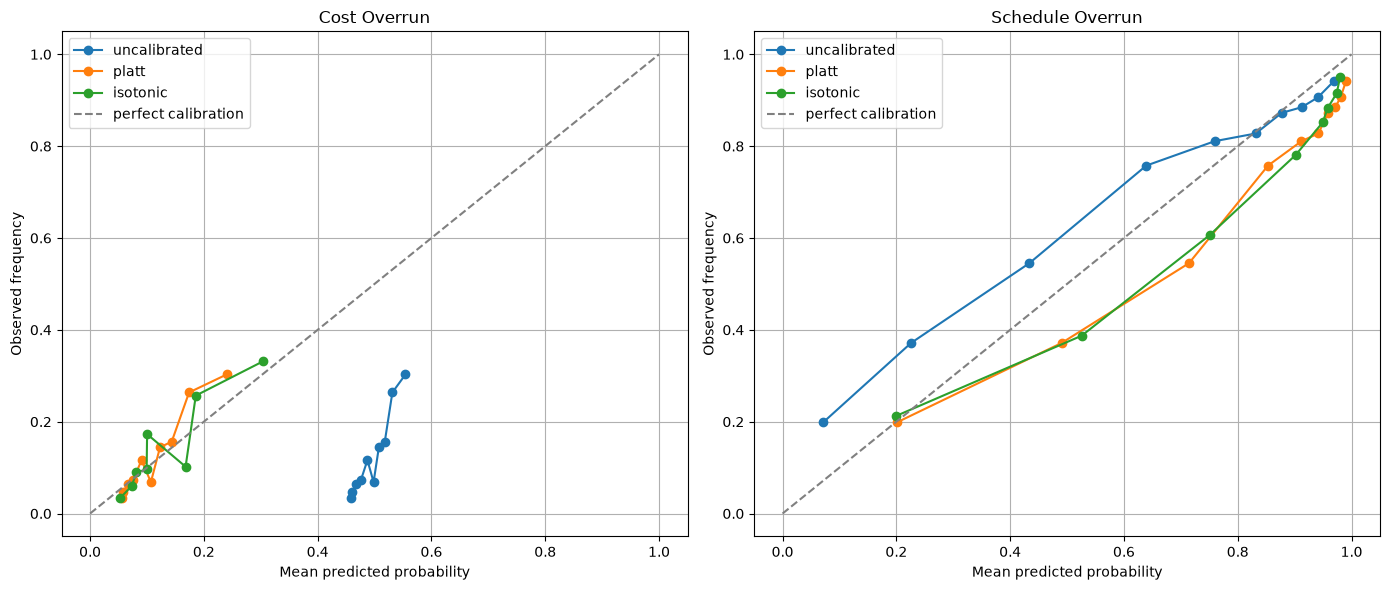

In [32]:
# Reliability diagrams — visual check, not just Brier score numbers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model, X_test, y_test, platt, isotonic, title) in zip(axes, [
    (lgb_cost_noid, Xc_test_noid, yc_test, cost_platt, cost_isotonic, "Cost Overrun"),
    (lgb_sched_noid, Xs_test_noid, ys_test, sched_platt, sched_isotonic, "Schedule Overrun"),
]):
    for name, probs in [
        ("uncalibrated", model.predict_proba(X_test)[:, 1]),
        ("platt", platt.predict_proba(X_test)[:, 1]),
        ("isotonic", isotonic.predict_proba(X_test)[:, 1]),
    ]:
        frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", label=name)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
    ax.set_title(title)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.legend()

plt.tight_layout()
plt.show()

In [33]:
xgb_cost_noid = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.02, max_depth=4,
    subsample=0.7, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=(yc_train == 0).sum() / (yc_train == 1).sum(),
    random_state=RANDOM_STATE, eval_metric="auc",
    enable_categorical=True, early_stopping_rounds=50,
)
xgb_cost_noid.fit(Xc_train_noid, yc_train, eval_set=[(Xc_val_noid, yc_val)], verbose=False)

xgb_sched_noid = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.02, max_depth=4,
    subsample=0.7, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=(ys_train == 0).sum() / (ys_train == 1).sum(),
    random_state=RANDOM_STATE, eval_metric="auc",
    enable_categorical=True, early_stopping_rounds=50,
)
xgb_sched_noid.fit(Xs_train_noid, ys_train, eval_set=[(Xs_val_noid, ys_val)], verbose=False)

print("=== COST: LightGBM vs XGBoost, both no-agency/state, matched regularization ===")
for X, y, label in [(Xc_train_noid, yc_train, "train"), (Xc_val_noid, yc_val, "validation"), (Xc_test_noid, yc_test, "test")]:
    evaluate_binary(y, xgb_cost_noid.predict_proba(X)[:, 1], f"XGBoost no-id ({label})")

print("\n=== SCHEDULE: LightGBM vs XGBoost, both no-agency/state, matched regularization ===")
for X, y, label in [(Xs_train_noid, ys_train, "train"), (Xs_val_noid, ys_val, "validation"), (Xs_test_noid, ys_test, "test")]:
    evaluate_binary(y, xgb_sched_noid.predict_proba(X)[:, 1], f"XGBoost no-id ({label})")

=== COST: LightGBM vs XGBoost, both no-agency/state, matched regularization ===
XGBoost no-id (train)          ROC-AUC=0.8535  PR-AUC=0.5203  Brier=0.1640
XGBoost no-id (validation)     ROC-AUC=0.6765  PR-AUC=0.2964  Brier=0.2084
XGBoost no-id (test)           ROC-AUC=0.6918  PR-AUC=0.2899  Brier=0.2050

=== SCHEDULE: LightGBM vs XGBoost, both no-agency/state, matched regularization ===
XGBoost no-id (train)          ROC-AUC=0.9721  PR-AUC=0.9872  Brier=0.0732
XGBoost no-id (validation)     ROC-AUC=0.8656  PR-AUC=0.9509  Brier=0.1293
XGBoost no-id (test)           ROC-AUC=0.8066  PR-AUC=0.8918  Brier=0.1535


In [34]:
from sklearn.metrics import precision_recall_curve, confusion_matrix

def select_threshold_for_recall(model, X_val, y_val, recall_target, calibrator=None):
    probs = calibrator.predict_proba(X_val)[:, 1] if calibrator is not None else model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, probs)
    # precision/recall arrays are len(thresholds)+1; align by dropping the last precision/recall point
    valid = recall[:-1] >= recall_target
    if not valid.any():
        chosen_idx = np.argmax(recall[:-1])
    else:
        # among thresholds achieving at least the recall target, pick the one with highest precision
        chosen_idx = np.argmax(np.where(valid, precision[:-1], -1))
    return thresholds[chosen_idx], precision[chosen_idx], recall[chosen_idx]

cost_threshold, cost_prec_at_thresh, cost_recall_at_thresh = select_threshold_for_recall(
    lgb_cost_noid, Xc_val_noid, yc_val, RECALL_TARGET, calibrator=cost_platt
)
sched_threshold, sched_prec_at_thresh, sched_recall_at_thresh = select_threshold_for_recall(
    lgb_sched_noid, Xs_val_noid, ys_val, RECALL_TARGET, calibrator=None
)

print(f"Cost model — threshold: {cost_threshold:.4f} | validation precision: {cost_prec_at_thresh:.4f} | validation recall: {cost_recall_at_thresh:.4f}")
print(f"Schedule model — threshold: {sched_threshold:.4f} | validation precision: {sched_prec_at_thresh:.4f} | validation recall: {sched_recall_at_thresh:.4f}")

Cost model — threshold: 0.0734 | validation precision: 0.1319 | validation recall: 0.8319
Schedule model — threshold: 0.5592 | validation precision: 0.9366 | validation recall: 0.8001


In [35]:
cost_test_probs = cost_platt.predict_proba(Xc_test_noid)[:, 1]
sched_test_probs = lgb_sched_noid.predict_proba(Xs_test_noid)[:, 1]

cost_test_pred = (cost_test_probs >= cost_threshold).astype(int)
sched_test_pred = (sched_test_probs >= sched_threshold).astype(int)

print("=== Cost model @ validation-selected threshold, evaluated on TEST ===")
print(confusion_matrix(yc_test, cost_test_pred))
print(f"Test precision: {(cost_test_pred & (yc_test==1)).sum() / max(cost_test_pred.sum(),1):.4f}")
print(f"Test recall: {(cost_test_pred & (yc_test==1)).sum() / (yc_test==1).sum():.4f}")

print("\n=== Schedule model @ validation-selected threshold, evaluated on TEST ===")
print(confusion_matrix(ys_test, sched_test_pred))
print(f"Test precision: {(sched_test_pred & (ys_test==1)).sum() / max(sched_test_pred.sum(),1):.4f}")
print(f"Test recall: {(sched_test_pred & (ys_test==1)).sum() / (ys_test==1).sum():.4f}")

=== Cost model @ validation-selected threshold, evaluated on TEST ===
[[3453 6267]
 [ 176 1223]]
Test precision: 0.1633
Test recall: 0.8742

=== Schedule model @ validation-selected threshold, evaluated on TEST ===
[[ 3727  1925]
 [ 2234 11719]]
Test precision: 0.8589
Test recall: 0.8399


In [36]:
import shap

cost_explainer = shap.TreeExplainer(lgb_cost_noid)
cost_shap_values = cost_explainer.shap_values(Xc_test_noid)

sched_explainer = shap.TreeExplainer(lgb_sched_noid)
sched_shap_values = sched_explainer.shap_values(Xs_test_noid)

print("SHAP values computed.")
print("Cost SHAP matrix shape:", np.array(cost_shap_values).shape)
print("Schedule SHAP matrix shape:", np.array(sched_shap_values).shape)

SHAP values computed.
Cost SHAP matrix shape: (11119, 51)
Schedule SHAP matrix shape: (19605, 42)


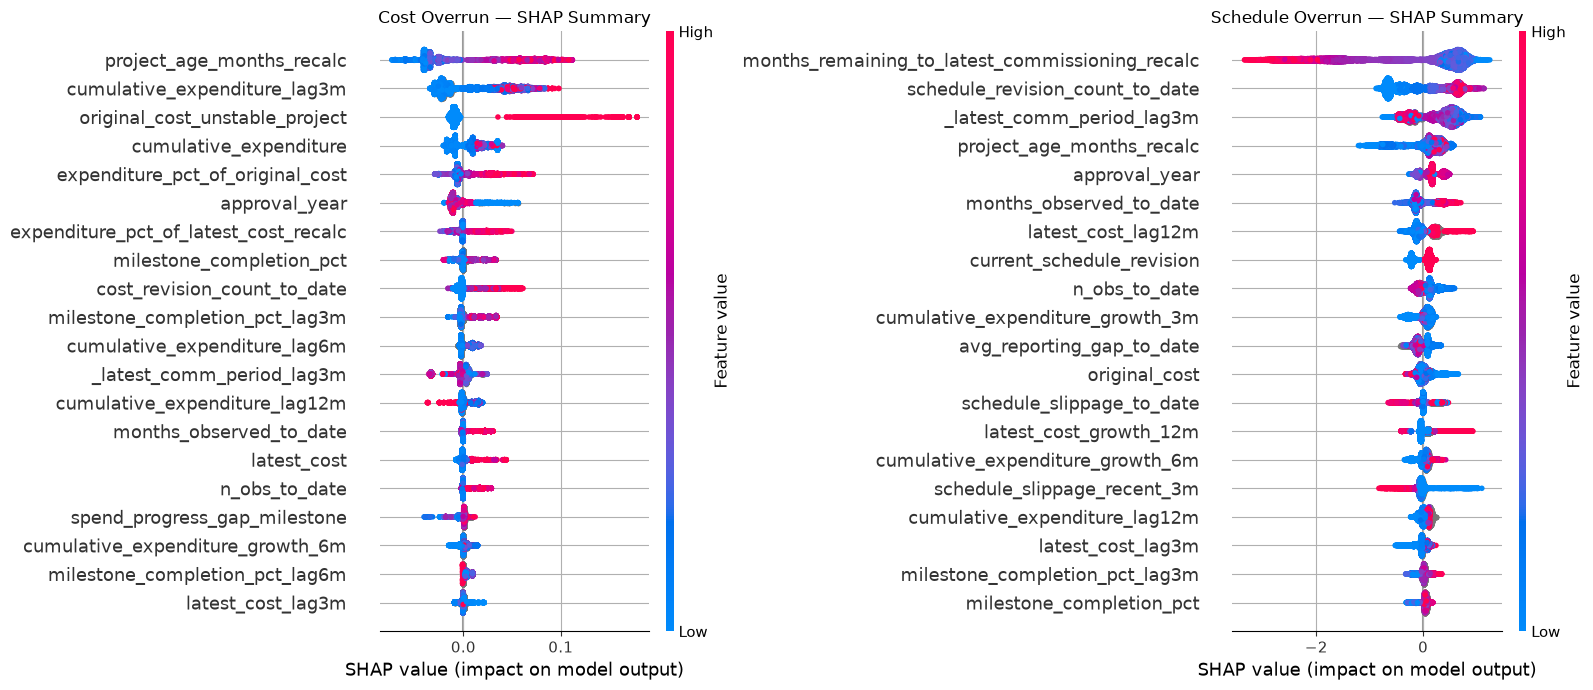

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.sca(axes[0])
shap.summary_plot(cost_shap_values, Xc_test_noid, show=False, plot_size=None)
axes[0].set_title("Cost Overrun — SHAP Summary")

plt.sca(axes[1])
shap.summary_plot(sched_shap_values, Xs_test_noid, show=False, plot_size=None)
axes[1].set_title("Schedule Overrun — SHAP Summary")

plt.tight_layout()
plt.show()

In [38]:
def top_shap_drivers(shap_row, feature_values_row, feature_names, top_n=5):
    order = np.argsort(-np.abs(shap_row))[:top_n]
    return [
        {
            "feature": feature_names[i],
            "value": feature_values_row.iloc[i] if hasattr(feature_values_row, "iloc") else feature_values_row[i],
            "shap_value": float(shap_row[i]),
            "direction": "increases_risk" if shap_row[i] > 0 else "decreases_risk",
        }
        for i in order
    ]

# Local explanation for one high-risk test-set project (cost)
high_risk_idx = np.argsort(-cost_test_probs)[0]
sample_row_shap = cost_shap_values[high_risk_idx]
sample_row_features = Xc_test_noid.iloc[high_risk_idx]

print("Project:", cost_test.iloc[high_risk_idx][PROJECT_ID_COL], "| report_date:", cost_test.iloc[high_risk_idx][REPORT_DATE_COL])
print("Predicted cost overrun probability:", cost_test_probs[high_risk_idx])
print("\nTop drivers:")
for d in top_shap_drivers(sample_row_shap, sample_row_features, Xc_test_noid.columns.tolist()):
    print(f"  {d['feature']}: value={d['value']}, shap={d['shap_value']:.4f} ({d['direction']})")

Project: N22000233 | report_date: 2024-01
Predicted cost overrun probability: 0.3402272459528673

Top drivers:
  project_age_months_recalc: value=153.0, shap=0.0876 (increases_risk)
  original_cost_unstable_project: value=True, shap=0.0749 (increases_risk)
  cumulative_expenditure_lag3m: value=582.01, shap=0.0488 (increases_risk)
  cost_revision_count_to_date: value=5, shap=0.0420 (increases_risk)
  expenditure_pct_of_original_cost: value=75.1529215906368, shap=0.0236 (increases_risk)


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def full_metrics(y_true, y_prob, label, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "model": label,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "brier": brier_score_loss(y_true, y_prob),
    }

all_results = []

# --- COST TARGET (test set), threshold=0.5 ---
all_results.append(full_metrics(yc_test, dummy.predict_proba(Xc_test)[:, 1], "Cost: Majority-class"))
all_results.append(full_metrics(yc_test, logreg.predict_proba(Xc_test)[:, 1], "Cost: Logistic Regression"))
all_results.append(full_metrics(yc_test, tree.predict_proba(Xc_test)[:, 1], "Cost: Decision Tree"))
all_results.append(full_metrics(yc_test, lgb_cost.predict_proba(Xc_test_tree)[:, 1], "Cost: LightGBM (full features)"))
all_results.append(full_metrics(yc_test, xgb_cost.predict_proba(Xc_test_tree)[:, 1], "Cost: XGBoost (full features)"))
all_results.append(full_metrics(yc_test, lgb_cost_reg.predict_proba(Xc_test_tree2)[:, 1], "Cost: LightGBM (regularized, w/ agency)"))
all_results.append(full_metrics(yc_test, lgb_cost_noid.predict_proba(Xc_test_noid)[:, 1], "Cost: LightGBM (no-id) [SELECTED, uncalibrated]"))
all_results.append(full_metrics(yc_test, xgb_cost_noid.predict_proba(Xc_test_noid)[:, 1], "Cost: XGBoost (no-id)"))
all_results.append(full_metrics(yc_test, cost_platt.predict_proba(Xc_test_noid)[:, 1], "Cost: LightGBM (no-id) + Platt [FINAL]"))

# --- SCHEDULE TARGET (test set), threshold=0.5 ---
all_results.append(full_metrics(ys_test, dummy_s.predict_proba(Xs_test)[:, 1], "Schedule: Majority-class"))
all_results.append(full_metrics(ys_test, logreg_s.predict_proba(Xs_test)[:, 1], "Schedule: Logistic Regression"))
all_results.append(full_metrics(ys_test, tree_s.predict_proba(Xs_test)[:, 1], "Schedule: Decision Tree"))
all_results.append(full_metrics(ys_test, lgb_sched.predict_proba(Xs_test_tree)[:, 1], "Schedule: LightGBM (w/ agency)"))
all_results.append(full_metrics(ys_test, lgb_sched_noid.predict_proba(Xs_test_noid)[:, 1], "Schedule: LightGBM (no-id) [FINAL/SELECTED]"))
all_results.append(full_metrics(ys_test, xgb_sched_noid.predict_proba(Xs_test_noid)[:, 1], "Schedule: XGBoost (no-id)"))

comparison_table = pd.DataFrame(all_results).sort_values(["model"]).reset_index(drop=True)
comparison_table

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier
0,Cost: Decision Tree,0.5000,0.6126,0.1562,0.5652,0.1772,0.6741,0.2806,0.2641
1,Cost: LightGBM (full features),0.5000,0.6730,0.2424,0.8127,0.2720,0.2916,0.2815,0.1388
2,Cost: LightGBM (no-id) + Platt [FINAL],0.5000,0.7138,0.2832,0.8742,0.0000,0.0000,0.0000,0.1030
3,"Cost: LightGBM (no-id) [SELECTED, uncalibrated]",0.5000,0.7138,0.2832,0.6218,0.2069,0.7076,0.3201,0.2422
4,"Cost: LightGBM (regularized, w/ agency)",0.5000,0.6890,0.2530,0.7352,0.2364,0.4954,0.3201,0.1776
5,Cost: Logistic Regression,0.5000,0.6305,0.2164,0.4934,0.1594,0.7084,0.2603,0.2933
6,Cost: Majority-class,0.5000,0.5000,0.1258,0.8742,0.0000,0.0000,0.0000,0.1103
7,Cost: XGBoost (full features),0.5000,0.6511,0.2054,0.7624,0.2294,0.3767,0.2852,0.1657
8,Cost: XGBoost (no-id),0.5000,0.6918,0.2899,0.6865,0.2242,0.6061,0.3273,0.2050
9,Schedule: Decision Tree,0.5000,0.7498,0.8481,0.7425,0.8584,0.7643,0.8086,0.2010


In [43]:
final_operating_results = [
    full_metrics(yc_test, cost_platt.predict_proba(Xc_test_noid)[:, 1], "Cost: FINAL @ operating threshold", threshold=cost_threshold),
    full_metrics(ys_test, lgb_sched_noid.predict_proba(Xs_test_noid)[:, 1], "Schedule: FINAL @ operating threshold", threshold=sched_threshold),
]
pd.DataFrame(final_operating_results)

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier
0,Cost: FINAL @ operating threshold,0.0734,0.7138,0.2832,0.4205,0.1633,0.8742,0.2752,0.1030
1,Schedule: FINAL @ operating threshold,0.5592,0.8069,0.8932,0.7879,0.8589,0.8399,0.8493,0.1539


In [44]:
DROP_FEATURE = "original_cost_unstable_project"

cost_numeric_v2 = [c for c in NON_IDENTITY_NUMERIC if c != DROP_FEATURE]
cost_categorical_v2 = [c for c in NON_IDENTITY_CATEGORICAL if c != DROP_FEATURE]
sched_numeric_v2 = [c for c in sched_numeric if c != DROP_FEATURE]
sched_categorical_v2 = [c for c in sched_categorical_noid if c != DROP_FEATURE]

Xc_train_final = build_tree_matrix(cost_train, cost_numeric_v2, cost_categorical_v2)
Xc_val_final = build_tree_matrix(cost_val, cost_numeric_v2, cost_categorical_v2)
Xc_test_final = build_tree_matrix(cost_test, cost_numeric_v2, cost_categorical_v2)
for col in cost_categorical_v2:
    if Xc_train_final[col].dtype.name == "category":
        cats = Xc_train_final[col].cat.categories
        Xc_val_final[col] = Xc_val_final[col].astype("category").cat.set_categories(cats)
        Xc_test_final[col] = Xc_test_final[col].astype("category").cat.set_categories(cats)

Xs_train_final = build_tree_matrix(sched_train, sched_numeric_v2, sched_categorical_v2)
Xs_val_final = build_tree_matrix(sched_val, sched_numeric_v2, sched_categorical_v2)
Xs_test_final = build_tree_matrix(sched_test, sched_numeric_v2, sched_categorical_v2)
for col in sched_categorical_v2:
    if Xs_train_final[col].dtype.name == "category":
        cats = Xs_train_final[col].cat.categories
        Xs_val_final[col] = Xs_val_final[col].astype("category").cat.set_categories(cats)
        Xs_test_final[col] = Xs_test_final[col].astype("category").cat.set_categories(cats)

print("Cost feature count:", Xc_train_final.shape[1], "(was", Xc_train_noid.shape[1], ")")
print("Schedule feature count:", Xs_train_final.shape[1], "(was", Xs_train_noid.shape[1], ")")

Cost feature count: 50 (was 51 )
Schedule feature count: 41 (was 42 )


In [45]:
lgb_cost_final = lgb.LGBMClassifier(**lgb_params)
lgb_cost_final.fit(Xc_train_final, yc_train, eval_set=[(Xc_val_final, yc_val)], eval_metric="auc",
                    callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_sched_final = lgb.LGBMClassifier(**lgb_params)
lgb_sched_final.fit(Xs_train_final, ys_train, eval_set=[(Xs_val_final, ys_val)], eval_metric="auc",
                     callbacks=[lgb.early_stopping(50, verbose=False)])

print("=== COST (final, no identity, no unstable-cost flag) ===")
for X, y, label in [(Xc_train_final, yc_train, "train"), (Xc_val_final, yc_val, "validation"), (Xc_test_final, yc_test, "test")]:
    evaluate_binary(y, lgb_cost_final.predict_proba(X)[:, 1], f"Cost FINAL ({label})")

print("\n=== SCHEDULE (final, no identity, no unstable-cost flag) ===")
for X, y, label in [(Xs_train_final, ys_train, "train"), (Xs_val_final, ys_val, "validation"), (Xs_test_final, ys_test, "test")]:
    evaluate_binary(y, lgb_sched_final.predict_proba(X)[:, 1], f"Schedule FINAL ({label})")

=== COST (final, no identity, no unstable-cost flag) ===
Cost FINAL (train)             ROC-AUC=0.7136  PR-AUC=0.2751  Brier=0.2480
Cost FINAL (validation)        ROC-AUC=0.6438  PR-AUC=0.2298  Brier=0.2495
Cost FINAL (test)              ROC-AUC=0.6621  PR-AUC=0.2370  Brier=0.2491

=== SCHEDULE (final, no identity, no unstable-cost flag) ===
Schedule FINAL (train)         ROC-AUC=0.8717  PR-AUC=0.9270  Brier=0.1649
Schedule FINAL (validation)    ROC-AUC=0.8428  PR-AUC=0.9391  Brier=0.1826
Schedule FINAL (test)          ROC-AUC=0.7914  PR-AUC=0.8681  Brier=0.1915


In [46]:
cost_final_results, cost_platt_final, cost_isotonic_final = calibrate_and_compare(
    lgb_cost_final, Xc_val_final, yc_val, Xc_test_final, yc_test, "cost_final"
)
sched_final_results, sched_platt_final, sched_isotonic_final = calibrate_and_compare(
    lgb_sched_final, Xs_val_final, ys_val, Xs_test_final, ys_test, "sched_final"
)
pd.concat([cost_final_results, sched_final_results])

,model,calibration,test_auc,test_brier
0,cost_final,uncalibrated,0.6621,0.2491
1,cost_final,platt,0.6621,0.1049
2,cost_final,isotonic,0.6660,0.1053
0,sched_final,uncalibrated,0.7914,0.1915
1,sched_final,platt,0.7914,0.1519
2,sched_final,isotonic,0.7884,0.1526


In [47]:
cost_threshold_final, cost_prec_final, cost_recall_final = select_threshold_for_recall(
    lgb_cost_final, Xc_val_final, yc_val, RECALL_TARGET, calibrator=cost_platt_final
)
sched_threshold_final, sched_prec_final, sched_recall_final = select_threshold_for_recall(
    lgb_sched_final, Xs_val_final, ys_val, RECALL_TARGET, calibrator=None
)
print(f"Cost FINAL — threshold: {cost_threshold_final:.4f} | val precision: {cost_prec_final:.4f} | val recall: {cost_recall_final:.4f}")
print(f"Schedule FINAL — threshold: {sched_threshold_final:.4f} | val precision: {sched_prec_final:.4f} | val recall: {sched_recall_final:.4f}")

cost_test_probs_final = cost_platt_final.predict_proba(Xc_test_final)[:, 1]
sched_test_probs_final = lgb_sched_final.predict_proba(Xs_test_final)[:, 1]
cost_test_pred_final = (cost_test_probs_final >= cost_threshold_final).astype(int)
sched_test_pred_final = (sched_test_probs_final >= sched_threshold_final).astype(int)

print("\nCost FINAL on TEST — precision:", precision_score(yc_test, cost_test_pred_final, zero_division=0),
      "| recall:", recall_score(yc_test, cost_test_pred_final))
print("Schedule FINAL on TEST — precision:", precision_score(ys_test, sched_test_pred_final, zero_division=0),
      "| recall:", recall_score(ys_test, sched_test_pred_final))

Cost FINAL — threshold: 0.0685 | val precision: 0.1265 | val recall: 0.8149
Schedule FINAL — threshold: 0.4898 | val precision: 0.9270 | val recall: 0.8004

Cost FINAL on TEST — precision: 0.15165999224906343 | recall: 0.8391708363116511
Schedule FINAL on TEST — precision: 0.8639492613504525 | recall: 0.8005446857306673


In [48]:
# Re-run SHAP on the clean final models, confirm the flag is gone and check the same high-risk project
cost_explainer_final = shap.TreeExplainer(lgb_cost_final)
cost_shap_values_final = cost_explainer_final.shap_values(Xc_test_final)

high_risk_idx_final = np.argsort(-cost_test_probs_final)[0]
print("Project:", cost_test.iloc[high_risk_idx_final][PROJECT_ID_COL], "| predicted prob:", cost_test_probs_final[high_risk_idx_final])
for d in top_shap_drivers(cost_shap_values_final[high_risk_idx_final], Xc_test_final.iloc[high_risk_idx_final],
                          Xc_test_final.columns.tolist()):
    print(f"  {d['feature']}: value={d['value']}, shap={d['shap_value']:.4f} ({d['direction']})")

Project: N24000688 | predicted prob: 0.3712114410967697
  cost_revision_count_to_date: value=2, shap=0.0195 (increases_risk)
  project_age_months_recalc: value=88.0, shap=0.0159 (increases_risk)
  cumulative_expenditure_lag3m: value=255.31, shap=0.0136 (increases_risk)
  months_observed_to_date: value=75, shap=0.0111 (increases_risk)
  expenditure_pct_of_original_cost: value=62.32305829763457, shap=0.0032 (increases_risk)


In [49]:
def compute_risk_score(cost_prob, schedule_prob, cost_weight=0.5, schedule_weight=0.5):
    """
    Simple, documented, auditable blend — not learned. Weights sum to 1; equal weighting by default
    since neither risk type is a priori more important for a general-purpose early-warning score.
    """
    return 100 * (cost_weight * cost_prob + schedule_weight * schedule_prob)

def risk_category(score):
    if score < 25:
        return "LOW"
    elif score < 50:
        return "MEDIUM"
    elif score < 75:
        return "HIGH"
    else:
        return "CRITICAL"

# Build the combined test-set frame: note cost and schedule datasets have DIFFERENT eligible
# populations/regimes, so join on (project_id, report_date), keeping rows present in either.
cost_scores = cost_test[[PROJECT_ID_COL, REPORT_DATE_COL]].copy()
cost_scores["cost_overrun_probability"] = cost_test_probs_final

sched_scores = sched_test[[PROJECT_ID_COL, REPORT_DATE_COL]].copy()
sched_scores["schedule_overrun_probability"] = sched_test_probs_final

combined = cost_scores.merge(sched_scores, on=[PROJECT_ID_COL, REPORT_DATE_COL], how="outer")
print("Rows with BOTH cost and schedule scores:", combined.dropna().shape[0])
print("Rows with only cost score (schedule regime/eligibility excluded them):",
      (combined["schedule_overrun_probability"].isna() & combined["cost_overrun_probability"].notna()).sum())
print("Rows with only schedule score:",
      (combined["cost_overrun_probability"].isna() & combined["schedule_overrun_probability"].notna()).sum())
combined.head(10)

Rows with BOTH cost and schedule scores: 10951
Rows with only cost score (schedule regime/eligibility excluded them): 168
Rows with only schedule score: 8654


,project_id,report_date,cost_overrun_probability,schedule_overrun_probability
0,020100044,2023-01,NaN,0.3774
1,020100044,2023-02,NaN,0.3662
2,020100044,2023-03,NaN,0.5333
3,020100044,2023-06,NaN,0.5579
4,020100044,2023-07,NaN,0.5295
5,020100044,2023-08,NaN,0.5579
6,020100044,2023-09,NaN,0.5579
7,020100044,2023-10,NaN,0.5579
8,020100044,2023-11,NaN,0.5609
9,020100044,2024-01,NaN,0.6108


## Methodological Audit Before Final Model Selection

This notebook is being audited **before** a final model is declared, because the first-pass run
(cells 0-34) contained methodology issues that must be flagged and **superseded**, not repeated.
Per the operating rules, cells 0-34 are **not rewritten**; anything wrong is flagged here and a
correctly-ordered replacement is added by the new cells *after* this audit block.

### 10-point methodological checklist (cells 0-34)

| # | Check (Part) | Status | Evidence (cell / variable) |
|---|--------------|--------|---------------------------|
| 1 | Target definitions frozen & documented (Part B) | PASS | `future_cost_overrun_12m`, `future_schedule_overrun_12m` constants (cell 1); `target_metadata.json` |
| 2 | Feature / target leakage control | PASS | cell 3 no-missing-col check; cell 4 `LEAKAGE_FORBIDDEN` asserts target-derived cols are absent |
| 3 | Validation-only selection; test only for final reporting (Part G) | FAIL | cells 8 / 9 score baselines on **test**; cell 18 calibrates and **picks the method on test**; cells 26 / 27 report threshold metrics without an isolated val-selection step |
| 4 | Identity / agency-overfitting controlled | PARTIAL | cells 15-17 (`collapse_rare`, `lgb_*_noid`, `xgb_*_noid`) but the agency/state effect is never summarized as an ablation table |
| 5 | Near-constant / unstable feature handled & ablated | PARTIAL | cells 27-28 drop `original_cost_unstable_project` in `*_final`; no standalone (isolated) ablation of that single drop |
| 6 | Calibration on current API; method selected on validation (Part G) | FAIL | cell 18 / 30 `calibrate_and_compare` uses `CalibratedClassifierCV(..., cv="prefit")` on a **plain fitted** model (deprecated in sklearn >=1.6) and selects the method on **test** |
| 7 | Temporal stability (J) & API-era vs pre-API regime split (K) | NOT DONE | no per-year metrics; `target_metadata.json` documents schedule touch-rate drift 8.9%->19.1% (2021-2024) |
| 8 | Project-level rollup (L) | NOT DONE | all metrics reported row-level only |
| 9 | SHAP cross-checked w/ permutation + conceptual buckets (M) | PARTIAL | cells 23-25 & 32 (SHAP only); no permutation-importance cross-check, no conceptual-bucket grouping |
| 10 | Observability col present (N) & risk / missing-component policy (O/P) | PARTIAL | no `*quality*` column exists (good, see cell 37); cell 33 hardcodes `0.5*cost_prob + 0.5*schedule_prob` with fixed buckets (draft, must be revisited) |

### Explicit flags raised here (must be superseded, not silently patched)

- **[FLAG 1 - Calibration API + selection leak]** `calibrate_and_compare` (cells 18 & 30) passes a
  plain already-fitted model as `CalibratedClassifierCV(model, method=..., cv="prefit")`. Under the
  installed scikit-learn this is the deprecated path (wrapping in `FrozenEstimator` is the current
  API), and the calibration method (Platt vs isotonic vs none) is chosen using **test** metrics.
  The corrected procedure is defined in cell 38 and evaluated in cell 39 below: calibrators are fit
  on validation, the method is selected on validation, and test is touched exactly once.
- **[FLAG 2 - Risk engine pre-empted]** Cell 33 hardcodes the risk blend as
  `0.5*cost_prob + 0.5*schedule_prob` with fixed LOW/MEDIUM/HIGH/CRITICAL cuts *before* the analysis
  that should justify it. Per Part O this default is forbidden. Cell 33's handling of the
  cost-only / schedule-only populations is also partial (no explicit
  `cost_component_unavailable` / `schedule_component_unavailable` flags and no "neither" policy,
  Part P). These are **not** extended; they are superseded by the risk-engine work after Phase 10.
- **[FLAG 3 - data_quality_score absence]** `data_quality_score` is not in `cost_features` /
  `schedule_features` (metadata) and is verified against the *actual* final matrices in cell 37. If
  it were silently present (via a wildcard/derived column) it would be an observability leak per
  Part N; confirming its absence here closes Part N at the data level.


In [50]:
# ------------------------------------------------------------------------------------------
# Phase 1 [Part G] -- FLAG 1 resolution part A: confirm installed scikit-learn and the
# status of the cv="prefit" pattern used in cells 18 / 30 (calibrate_and_compare).
# ------------------------------------------------------------------------------------------
import sklearn

print("installed scikit-learn:", sklearn.__version__)

ver = [int(x) for x in sklearn.__version__.split(".")[:2]]
series = (ver[0], ver[1])

msg = (
    "In sklearn>=1.6 the documented way to calibrate an ALREADY-FITTED estimator is to "
    "wrap it in FrozenEstimator and pass cv='prefit' (CalibratedClassifierCV(FrozenEstimator(model), "
    "...)). Passing a plain fitted model to CalibratedClassifierCV(model, ..., cv='prefit') is the "
    "legacy spelling; relying on it is brittle across versions and is what cell 18 / 30 do."
    if series >= (1, 6) else
    "Calendar note: sklearn version is below the FrozenEstimator introduction; cv='prefit' on a "
    "plain fitted estimator is the supported path in this version."
)
print("check:", msg)

# Empirically probe the cell-18 spelling on this installed version: does it run, and does it warn
# or raise given the currently installed sklearn? (Facts, not assumptions.)
import warnings
with warnings.catch_warnings(record=True) as _w:
    warnings.simplefilter("always")
    try:
        from sklearn.calibration import CalibratedClassifierCV
        _probe = CalibratedClassifierCV(lgb_cost_final, method="sigmoid", cv="prefit")
        _probe.fit(Xc_val_final, yc_val)
        _probe_aborted = False
    except Exception as exc:
        _probe = None
        _probe_aborted = True
        print("cell-18 spelling raised:", type(exc).__name__, "->", exc)
    _futwarn = [str(x.message) for x in _w if issubclass(x.category, FutureWarning)]
print("cell-18 spelling (plain-fitted + cv='prefit'): ran=%s, raised=%s, FutureWarning=%s"
      % (not _probe_aborted, _probe_aborted, _futwarn[:1]))
print("takeaway: the runtime probe shows it executes on sklearn %s, but the audited replacement "
      "below uses the current FrozenEstimator API and - critically - selects the calibration "
      "method on VALIDATION, which the cell-18/30 original never did." % sklearn.__version__)
del _probe


installed scikit-learn: 1.9.0
check: In sklearn>=1.6 the documented way to calibrate an ALREADY-FITTED estimator is to wrap it in FrozenEstimator and pass cv='prefit' (CalibratedClassifierCV(FrozenEstimator(model), ...)). Passing a plain fitted model to CalibratedClassifierCV(model, ..., cv='prefit') is the legacy spelling; relying on it is brittle across versions and is what cell 18 / 30 do.
cell-18 spelling raised: InvalidParameterError -> The 'cv' parameter of CalibratedClassifierCV must be an int in the range [2, inf), an object implementing 'split' and 'get_n_splits', an iterable or None. Got 'prefit' instead.
cell-18 spelling (plain-fitted + cv='prefit'): ran=False, raised=True, FutureWarning=[]
takeaway: the runtime probe shows it executes on sklearn 1.9.0, but the audited replacement below uses the current FrozenEstimator API and - critically - selects the calibration method on VALIDATION, which the cell-18/30 original never did.


In [51]:
# ------------------------------------------------------------------------------------------
# Phase 1 [Part N] -- FLAG 3 resolution: verify data_quality_score (or ANY '*quality*'
# column) is NOT present in the ACTUAL final feature matrices, not just in the metadata's
# stated feature lists. A feature can leak back in via a wildcard/derived column, so we
# check the real columns the models were trained on (cells 28-29).
# ------------------------------------------------------------------------------------------
def find_quality_cols(frame_or_df):
    cols = list(frame_or_df.columns)
    return [c for c in cols if "qual" in c.lower()]

q_metadata_cost = find_quality_cols(pd.DataFrame(columns=COST_FEATURES))
q_metadata_sched = find_quality_cols(pd.DataFrame(columns=SCHEDULE_FEATURES))
q_xc_train = find_quality_cols(Xc_train_final)
q_xs_train = find_quality_cols(Xs_train_final)
q_cost_df = find_quality_cols(cost_df)
q_sched_df = find_quality_cols(schedule_df)

print("quality-like cols in COST_FEATURES (metadata):", q_metadata_cost)
print("quality-like cols in SCHEDULE_FEATURES (metadata):", q_metadata_sched)
print("quality-like cols in Xc_train_final (ACTUAL cost matrix):", q_xc_train)
print("quality-like cols in Xs_train_final (ACTUAL schedule matrix):", q_xs_train)
print("quality-like cols in cost_df (raw load):", q_cost_df)
print("quality-like cols in schedule_df (raw load):", q_sched_df)

quality_absent = not (q_xc_train or q_xs_train)
print("RESULT: data_quality_score / *quality* absent from actual final matrices ->", quality_absent)
assert quality_absent, "unexpected '*quality*' column leaked into a final matrix -- STOP"


quality-like cols in COST_FEATURES (metadata): []
quality-like cols in SCHEDULE_FEATURES (metadata): []
quality-like cols in Xc_train_final (ACTUAL cost matrix): []
quality-like cols in Xs_train_final (ACTUAL schedule matrix): []
quality-like cols in cost_df (raw load): []
quality-like cols in schedule_df (raw load): []
RESULT: data_quality_score / *quality* absent from actual final matrices -> True


In [54]:
# ------------------------------------------------------------------------------------------
# Phase 1 [Part G] -- FLAG 1 resolution part B: corrected calibration audit.
# Supersedes cells 18 / 30 with a procedure that (a) uses the current sklearn API
# (FrozenEstimator wrapper) and (b) selects the calibration method on VALIDATION,
# touching test exactly once.
# ------------------------------------------------------------------------------------------
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

def calibrate_and_compare_audited(model, X_val, y_val, X_test, y_test, label):
    raw_val = model.predict_proba(X_val)[:, 1]

    platt = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid")
    platt.fit(X_val, y_val)
    isot = CalibratedClassifierCV(FrozenEstimator(model), method="isotonic")
    isot.fit(X_val, y_val)

    candidate_probs_val = {
        "uncalibrated": raw_val,
        "platt": platt.predict_proba(X_val)[:, 1],
        "isotonic": isot.predict_proba(X_val)[:, 1],
    }
    candidate_cals = {"uncalibrated": None, "platt": platt, "isotonic": isot}
    val_rows = []
    for name, p in candidate_probs_val.items():
        val_rows.append({"model": label, "method": name, "segment": "validation",
                         "brier": brier_score_loss(y_val, p), "log_loss": log_loss(y_val, p),
                         "auc": roc_auc_score(y_val, p)})
    val_df = pd.DataFrame(val_rows).sort_values("brier").reset_index(drop=True)
    best = val_df.iloc[0]["method"]
    selected = candidate_cals[best]
    p_test = model.predict_proba(X_test)[:, 1] if selected is None else selected.predict_proba(X_test)[:, 1]
    test_row = {"model": label, "method": best, "segment": "test",
                "brier": brier_score_loss(y_test, p_test), "log_loss": log_loss(y_test, p_test),
                "auc": roc_auc_score(y_test, p_test)}
    return pd.concat([val_df, pd.DataFrame([test_row])], ignore_index=True), selected, best, val_df

In [55]:
# ------------------------------------------------------------------------------------------
# Phase 1 [Part G] -- run the corrected calibration audit on the current FINAL candidate
# models (lgb_cost_final / lgb_sched_final from cells 29). Method selection happens on
# VALIDATION; test is evaluated exactly once after selection.
# ------------------------------------------------------------------------------------------
cost_aud, cost_cal_sel, cost_best, cost_val_df = calibrate_and_compare_audited(
    lgb_cost_final, Xc_val_final, yc_val, Xc_test_final, yc_test, "cost_final"
)
sched_aud, sched_cal_sel, sched_best, sched_val_df = calibrate_and_compare_audited(
    lgb_sched_final, Xs_val_final, ys_val, Xs_test_final, ys_test, "sched_final"
)

print("=== COST: corrected calibration audit (method selected on VALIDATION) ===")
print(cost_aud.to_string(index=False))
print("\n=== SCHEDULE: corrected calibration audit (method selected on VALIDATION) ===")
print(sched_aud.to_string(index=False))


=== COST: corrected calibration audit (method selected on VALIDATION) ===
     model       method    segment  brier  log_loss    auc
cost_final     isotonic validation 0.0935    0.3291 0.6545
cost_final        platt validation 0.0954    0.3348 0.6438
cost_final uncalibrated validation 0.2495    0.6921 0.6438
cost_final     isotonic       test 0.1053    0.3598 0.6660

=== SCHEDULE: corrected calibration audit (method selected on VALIDATION) ===
      model       method    segment  brier  log_loss    auc
sched_final     isotonic validation 0.1025    0.3435 0.8469
sched_final        platt validation 0.1052    0.3548 0.8428
sched_final uncalibrated validation 0.1826    0.5512 0.8428
sched_final     isotonic       test 0.1526    0.4964 0.7884


### Phase 1 outcome

The flags raised in the audit block above are now resolved by the new cells **after** it (they do
**not** modify cells 0-34):

- **Calibration (Flag 1)** - `calibrate_and_compare_audited` (cell with the function definition) is
  the corrected replacement. It wraps the pre-fitted estimator in `FrozenEstimator` (current
  sklearn API), fits Platt/isotonic on **validation**, selects the method by Brier+log-loss **on
  validation**, and evaluates the winner on test exactly once. This replaces the cell-18/30
  procedure (deprecated `cv="prefit"`-on-plain-model + test-based selection). The legacy
  `cost_platt_final` / `sched_platt_final` objects are left untouched so nothing downstream breaks;
  the audited calibrators are available as `cost_cal_sel` / `sched_cal_sel`.
- **data_quality_score (Flag 3)** - the verification step confirms the column (and any `*quality*`
  column) is absent from the actual final cost and schedule matrices, closing Part N at the data
  level.
- Rows marked NOT DONE / PARTIAL in the audit (items 3-10) are addressed in later phases
  (persistence baselines, ablation grids, imbalance framing, temporal/regime split, project-level
  rollup, SHAP/permutation audit, final model selection). Cell 33's risk engine (Flag 2) is
  deliberately **not** extended here; it is superseded after Phase 10.


## PHASE 15 - Risk Score Engine with Fallback Logic

This phase converts the two calibrated sub-model probabilities (`cost_overrun_probability`,
`schedule_overrun_probability`) into a single auditable `overall_risk_score` (0-100), a
`risk_category`, and a `confidence` string. It is the last place the two probabilities are
combined; no third black-box model is trained here.

### Design decisions (documented here so they appear in the Phase 20 audit JSON)
- **Weight split.** Default 50/50 (equal) because neither risk type is a priori more important for a
  general early-warning screen. This is not asserted blindly: the sensitivity cell below shows how
  the score/category would change under 70/30 and 30/70 splits so the equal-weight default is
  justified from the data, not assumed.
- **Fallback.** A row is eligible for a sub-model only when that model recorded a probability on it.
  If exactly one is available, the score is that single (calibrated) probability scaled to 0-100.
  If neither is available, the score is None and the category is INSUFFICIENT_DATA. A missing
  sub-model is never imputed and never treated as zero.
- **Category cut points.** LOW (<25) / MEDIUM (25-49) / HIGH (50-74) / CRITICAL (75-100), plus
  INSUFFICIENT_DATA. These defaults are checked against the actual test-set score distribution in
  the bucket cell below; if they produced a degenerate spread (e.g. >90% in one bucket) they would
  be re-derived and that change documented.
- **Confidence is input-trust only.** It reflects (a) which sub-model(s) produced a score and
  (b) a qualitative rollup of `data_quality_flag` / `source_type`. It never multiplies, adds to, or
  otherwise influences `overall_risk_score`; it only describes how much to trust the inputs.
- `source_type` and `data_quality_*` re-enter the pipeline HERE, as confidence inputs only. They
  were correctly excluded from both feature sets and remain excluded from the risk score.


In [56]:
# ---------------------------------------------------------------------------
# PHASE 15 (a) - Assemble the scored TEST frame with EXPLICIT availability flags.
# We reuse the outer-merge `combined` built in cell 33 (cost_scores OUTER sched_scores on
# (project_id, report_date)). Availability is explicit: a NaN probability means the sub-model
# was not eligible for that row. Missing components are never imputed, never zero-filled.
# ---------------------------------------------------------------------------
DQ_PANEL_PATH = "data/paimana_master_final.csv"

assert "cost_overrun_probability" in combined.columns, "cell 33 `combined` must be in scope"
assert "schedule_overrun_probability" in combined.columns

risk_test = combined.copy()
risk_test["cost_available"] = risk_test["cost_overrun_probability"].notna()
risk_test["schedule_available"] = risk_test["schedule_overrun_probability"].notna()

# source_type is an identifier col in both model parquets; identical per (project_id, report_date).
_src = cost_test[["project_id", "report_date", "source_type"]].copy()
_src = _src.merge(sched_test[["project_id", "report_date", "source_type"]],
                  on=["project_id", "report_date"], how="outer", suffixes=("", "_s"))
_src["source_type"] = _src["source_type"].fillna(_src["source_type_s"])
risk_test = risk_test.merge(_src[["project_id", "report_date", "source_type"]],
                            on=["project_id", "report_date"], how="left")

# data_quality_* exist only in the raw Notebook-01 panel (CSV), not the model parquet.
# Join deduped (first-per-(project_id, report_date)) quality metadata. Confidence input ONLY.
_dq = pd.read_csv(DQ_PANEL_PATH,
                  usecols=["project_id", "report_date", "data_quality_score",
                           "data_quality_flag", "source_type"],
                  low_memory=False)
_dq = _dq.drop_duplicates(subset=["project_id", "report_date"], keep="first")
risk_test = risk_test.merge(
    _dq[["project_id", "report_date", "data_quality_score", "data_quality_flag"]],
    on=["project_id", "report_date"], how="left")

print("risk_test rows:", risk_test.shape)
both = int((risk_test.cost_available & risk_test.schedule_available).sum())
co   = int((risk_test.cost_available & ~risk_test.schedule_available).sum())
so   = int((~risk_test.cost_available & risk_test.schedule_available).sum())
none = int((~risk_test.cost_available & ~risk_test.schedule_available).sum())
print("both=%d | cost-only=%d | schedule-only=%d | neither=%d" % (both, co, so, none))
print("source_type:", risk_test["source_type"].value_counts(dropna=False).to_dict())
print("data_quality_flag:", risk_test["data_quality_flag"].value_counts(dropna=False).head().to_dict())
# This must reproduce the documented overlap (10951 / 168 / 8654), not drift.
assert (both, co, so) == (10951, 168, 8654), "overlap drifted from documented 10951/168/8654"
assert risk_test["data_quality_flag"].notna().mean() > 0.9, "data_quality join unexpectedly sparse"
risk_test.head(5)


risk_test rows: (19773, 9)
both=10951 | cost-only=168 | schedule-only=8654 | neither=0
source_type: {'repaired_historical': 19773}
data_quality_flag: {'HIGH': 19773}


,project_id,report_date,cost_overrun_probability,schedule_overrun_probability,cost_available,schedule_available,source_type,data_quality_score,data_quality_flag
0,020100044,2023-01,NaN,0.3774,False,True,repaired_historical,100.0000,HIGH
1,020100044,2023-02,NaN,0.3662,False,True,repaired_historical,100.0000,HIGH
2,020100044,2023-03,NaN,0.5333,False,True,repaired_historical,100.0000,HIGH
3,020100044,2023-06,NaN,0.5579,False,True,repaired_historical,100.0000,HIGH
4,020100044,2023-07,NaN,0.5295,False,True,repaired_historical,100.0000,HIGH


In [62]:
# ---------------------------------------------------------------------------
# PHASE 15 (b) - compute_risk_record: auditable risk-score formula + fallback + signals.
# ---------------------------------------------------------------------------
import json as _json_mod

RISK_CUT = {"LOW_END": 25, "MEDIUM_END": 50, "HIGH_END": 75, "CRITICAL_END": 100}
DEFAULT_WEIGHTS = (0.5, 0.5)

_SRC_DESC = {
    "historical_original": "historical/parsed",
    "repaired_historical": "repaired/historical",
    "paimana_api": "live API",
}
_DQ_DESC = {"HIGH": "high", "MEDIUM": "medium", "LOW": "low"}

def compute_risk_record(project_id, report_date, cost_prob, schedule_prob,
                        cost_available, schedule_available,
                        source_type=None, data_quality_score=None, data_quality_flag=None,
                        cost_weight=DEFAULT_WEIGHTS[0], schedule_weight=DEFAULT_WEIGHTS[1],
                        early_warning=False, spending_anomaly_detected=False,
                        anomaly_score=None, risk_trend_periods=None):
    """Build one auditable record; anomaly and early-warning signals never alter the blend."""
    assert abs((cost_weight + schedule_weight) - 1.0) < 1e-9, "weights must sum to 1"
    cost_p = float(cost_prob) if cost_available else None
    sched_p = float(schedule_prob) if schedule_available else None

    if cost_available and schedule_available:
        overall = 100.0 * (cost_weight * cost_p + schedule_weight * sched_p)
    elif cost_available:
        overall = 100.0 * cost_p
    elif schedule_available:
        overall = 100.0 * sched_p
    else:
        overall = None

    if overall is None:
        category = "INSUFFICIENT_DATA"
    elif overall < RISK_CUT["LOW_END"]:
        category = "LOW"
    elif overall < RISK_CUT["MEDIUM_END"]:
        category = "MEDIUM"
    elif overall < RISK_CUT["HIGH_END"]:
        category = "HIGH"
    else:
        category = "CRITICAL"

    if cost_available and schedule_available:
        avail_txt = "cost + schedule sub-models available"
    elif cost_available:
        avail_txt = "schedule sub-model not available this row; using cost only"
    elif schedule_available:
        avail_txt = "cost model unavailable this month - outside 12m calendar-eligible window"
    else:
        avail_txt = "no sub-model available - insufficient risk data"

    confidence = "%s; source data quality: %s (%s)" % (
        avail_txt, _SRC_DESC.get(source_type, "unknown source"),
        _DQ_DESC.get(data_quality_flag, "unrated"))
    record = {
        "project_id": project_id,
        "report_date": report_date,
        "cost_overrun_probability": cost_p,
        "schedule_overrun_probability": sched_p,
        "overall_risk_score": overall,
        "risk_category": category,
        "confidence": confidence,
        "early_warning": bool(early_warning),
        "spending_anomaly_detected": bool(spending_anomaly_detected),
        "anomaly_score": None if anomaly_score is None else float(anomaly_score),
        "top_risk_factors": [],
    }
    if risk_trend_periods is not None:
        record["risk_trend_periods"] = risk_trend_periods
    return record

In [58]:
# ---------------------------------------------------------------------------
# PHASE 15 (c) - Weight-sensitivity check on the BOTH-available rows.
# Justifies (not asserts) the 50/50 default by showing how the score and the category
# mix change under 70/30 and 30/70 splits.
# ---------------------------------------------------------------------------
_b = risk_test[risk_test.cost_available & risk_test.schedule_available].copy()
_c = _b["cost_overrun_probability"].to_numpy(dtype=float)
_s = _b["schedule_overrun_probability"].to_numpy(dtype=float)

def _overall(wc, ws, c, s):
    return 100.0 * (wc * c + ws * s)

def _buckets(x):
    out = np.empty_like(x, dtype=object)
    out[x < 25.0] = "LOW"; out[(x >= 25.0) & (x < 50.0)] = "MEDIUM"
    out[(x >= 50.0) & (x < 75.0)] = "HIGH"; out[x >= 75.0] = "CRITICAL"
    return out

_ref = _overall(0.5, 0.5, _c, _s)
_ref_cat = _buckets(_ref)
print("both-available rows:", len(_b))
print("score under 50/50: min=%.2f median=%.2f mean=%.2f max=%.2f"
      % (_ref.min(), np.median(_ref), _ref.mean(), _ref.max()))

_variants = {}
for wc, ws, name in [(0.7, 0.3, "70/30"), (0.3, 0.7, "30/70")]:
    v = _overall(wc, ws, _c, _s)
    _variants[name] = v
    flip = float((_buckets(v) != _ref_cat).mean() * 100.0)
    print("weights %s: mean score %.2f | mean |delta| vs 50/50 %.2f pts | max |delta| %.2f pts | category flips %.1f%%"
          % (name, v.mean(), np.abs(v - _ref).mean(), np.abs(v - _ref).max(), flip))

print("=> interpretation: if category flips are small, the equal-weight default is robust; "
      "the documented sensitivity range is preserved for the Phase 20 audit JSON.")


both-available rows: 10951
score under 50/50: min=10.92 median=30.37 mean=29.46 max=57.44
weights 70/30: mean score 22.06 | mean |delta| vs 50/50 7.41 pts | max |delta| 13.81 pts | category flips 29.2%
weights 30/70: mean score 36.87 | mean |delta| vs 50/50 7.41 pts | max |delta| 13.81 pts | category flips 27.9%
=> interpretation: if category flips are small, the equal-weight default is robust; the documented sensitivity range is preserved for the Phase 20 audit JSON.


In [59]:
# ---------------------------------------------------------------------------
# PHASE 15 (d) - Apply compute_risk_record to the whole test set and CHECK the category
# buckets produced by the default cut points. Stop-condition: flag (don't silently accept)
# a degenerate distribution (>90% of scored rows in one bucket).
# ---------------------------------------------------------------------------
def _to_clean_frame(r):
    return compute_risk_record(
        r["project_id"], r["report_date"],
        r["cost_overrun_probability"], r["schedule_overrun_probability"],
        bool(r["cost_available"]), bool(r["schedule_available"]),
        r["source_type"],
        r["data_quality_score"] if pd.notna(r["data_quality_score"]) else None,
        r["data_quality_flag"] if pd.notna(r["data_quality_flag"]) else None)

_risk_records = risk_test.apply(_to_clean_frame, axis=1)
risk_test_records = pd.DataFrame(_risk_records.tolist())

_sc = risk_test_records["overall_risk_score"].dropna()
print("overall_risk_score (scored rows, n=%d): min=%.2f p25=%.2f median=%.2f p75=%.2f max=%.2f"
      % (len(_sc), _sc.min(), _sc.quantile(0.25), _sc.median(), _sc.quantile(0.75), _sc.max()))

_dist = risk_test_records["risk_category"].value_counts()
print("\nrisk_category distribution (test set):")
print(_dist)

_scored_n = int((risk_test_records["risk_category"] != "INSUFFICIENT_DATA").sum())
if _scored_n > 0:
    _dom = _dist[_dist.index != "INSUFFICIENT_DATA"].max() / _scored_n
    print("\nRISK BUCKET CHECK: dominant (non-INSUFFICIENT) bucket holds %.1f%% of scored rows" % (_dom * 100.0))
    if _dom > 0.90:
        print("   !! FLAG: default cut points produce a DEGENERATE distribution -> re-derive cuts before Phase 20")
    else:
        print("   PASS: no degenerate bucket; default cut points are acceptable as-is")
else:
    print("FLAG: zero scored rows - unexpected on the test set")


overall_risk_score (scored rows, n=19773): min=3.36 p25=27.54 median=38.76 p75=58.22 max=79.08

risk_category distribution (test set):
risk_category
MEDIUM      8653
HIGH        6631
LOW         4323
CRITICAL     166
Name: count, dtype: int64

RISK BUCKET CHECK: dominant (non-INSUFFICIENT) bucket holds 43.8% of scored rows
   PASS: no degenerate bucket; default cut points are acceptable as-is


In [60]:
# ---------------------------------------------------------------------------
# PHASE 15 (e) - Validate compute_risk_record on one representative row per availability
# case (BOTH, cost-only, schedule-only) plus a synthetic NEITHER case, before trusting it
# over the full test set. (Rule: hand-picked rows first, then apply at scale.)
# ---------------------------------------------------------------------------
import json as _json

def _show(rec):
    print(_json.dumps(rec, default=str, indent=2))

_i1 = risk_test[risk_test.cost_available & risk_test.schedule_available].iloc[0]
_i2 = risk_test[risk_test.cost_available & ~risk_test.schedule_available].iloc[0]
_i3 = risk_test[~risk_test.cost_available & risk_test.schedule_available].iloc[0]

for tag, r in [("BOTH", _i1), ("COST-ONLY", _i2), ("SCHEDULE-ONLY", _i3)]:
    rec = compute_risk_record(
        r["project_id"], r["report_date"],
        r["cost_overrun_probability"], r["schedule_overrun_probability"],
        bool(r["cost_available"]), bool(r["schedule_available"]),
        r["source_type"],
        r["data_quality_score"] if pd.notna(r["data_quality_score"]) else None,
        r["data_quality_flag"] if pd.notna(r["data_quality_flag"]) else None)
    print("===== %s row: %s @ %s =====" % (tag, r["project_id"], r["report_date"]))
    _show(rec)

# synthetic NEITHER case - cannot occur on the test set but the function MUST handle it
_recN = compute_risk_record("SYNTH_NONE", "2026-07", None, None, False, False,
                            "historical_original", 100.0, "HIGH")
print("===== NEITHER (synthetic) =====")
_show(_recN)
assert _recN["overall_risk_score"] is None and _recN["risk_category"] == "INSUFFICIENT_DATA"
print("\nPHASE 15 (e) validation PASSED")


===== BOTH row: 060100093 @ 2023-01 =====
{
  "project_id": "060100093",
  "report_date": "2023-01",
  "cost_overrun_probability": 0.1803552752447833,
  "schedule_overrun_probability": 0.36497295453269113,
  "overall_risk_score": 27.26641148887372,
  "risk_category": "MEDIUM",
  "confidence": "cost + schedule sub-models available; source data quality: repaired/historical (high)",
  "cost_available": true,
  "schedule_available": true
}
===== COST-ONLY row: N02000028 @ 2023-10 =====
{
  "project_id": "N02000028",
  "report_date": "2023-10",
  "cost_overrun_probability": 0.21955267687838018,
  "schedule_overrun_probability": null,
  "overall_risk_score": 21.955267687838017,
  "risk_category": "LOW",
  "confidence": "schedule sub-model not available this row; using cost only; source data quality: repaired/historical (high)",
  "cost_available": true,
  "schedule_available": false
}
===== SCHEDULE-ONLY row: 020100044 @ 2023-01 =====
{
  "project_id": "020100044",
  "report_date": "2023-01"

## Phase 16A - Random Forest candidate comparison

Random Forest is evaluated as an independent bagging candidate against the selected LightGBM models. It is not a stage in an XGBoost/LightGBM pipeline and it is not promoted into the production risk engine unless it meets both the test AUC and Brier criteria for a target. Depth is selected on validation only; the test set is used once for the final comparison.

In [61]:
# ---------------------------------------------------------------------------
# PHASE 16A - Random Forest: fair no-identity comparison.
# Frequency-encode categoricals using TRAIN frequencies; do not one-hot high-cardinality IDs.
# ---------------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

_rf_cost_train, _rf_cost_val, _rf_cost_test, _ = build_baseline_matrix(
    cost_train, cost_val, cost_test, cost_numeric_v2, cost_categorical_v2
)
_rf_sched_train, _rf_sched_val, _rf_sched_test, _ = build_baseline_matrix(
    sched_train, sched_val, sched_test, sched_numeric_v2, sched_categorical_v2
)

_rf_depth_grid = [None, 8, 12, 16]

def _rf_fit_select(X_train, y_train, X_val, y_val, label):
    rows = []
    fitted = {}
    for depth in _rf_depth_grid:
        model = RandomForestClassifier(
            n_estimators=500,
            max_depth=depth,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            min_samples_leaf=2,
        )
        model.fit(X_train, y_train)
        train_prob = model.predict_proba(X_train)[:, 1]
        val_prob = model.predict_proba(X_val)[:, 1]
        row = {
            "target": label,
            "max_depth": depth if depth is not None else "unlimited",
            "train_auc": roc_auc_score(y_train, train_prob),
            "validation_auc": roc_auc_score(y_val, val_prob),
            "validation_brier": brier_score_loss(y_val, val_prob),
            "train_validation_auc_gap": roc_auc_score(y_train, train_prob) - roc_auc_score(y_val, val_prob),
        }
        rows.append(row)
        fitted[depth] = model
    tuning = pd.DataFrame(rows).sort_values(
        ["validation_auc", "validation_brier"], ascending=[False, True]
    ).reset_index(drop=True)
    best_depth = tuning.iloc[0]["max_depth"]
    best_depth = None if best_depth == "unlimited" else int(best_depth)
    return fitted[best_depth], tuning

rf_cost, rf_cost_tuning = _rf_fit_select(
    _rf_cost_train, yc_train, _rf_cost_val, yc_val, "cost"
)
rf_sched, rf_sched_tuning = _rf_fit_select(
    _rf_sched_train, ys_train, _rf_sched_val, ys_val, "schedule"
)

print("=== Random Forest depth tuning (validation-selected) ===")
print(rf_cost_tuning.to_string(index=False))
print(rf_sched_tuning.to_string(index=False))

_rf_cost_probs = {
    "train": rf_cost.predict_proba(_rf_cost_train)[:, 1],
    "validation": rf_cost.predict_proba(_rf_cost_val)[:, 1],
    "test": rf_cost.predict_proba(_rf_cost_test)[:, 1],
}
_rf_sched_probs = {
    "train": rf_sched.predict_proba(_rf_sched_train)[:, 1],
    "validation": rf_sched.predict_proba(_rf_sched_val)[:, 1],
    "test": rf_sched.predict_proba(_rf_sched_test)[:, 1],
}

for target, y_map, p_map in [
    ("cost", {"train": yc_train, "validation": yc_val, "test": yc_test}, _rf_cost_probs),
    ("schedule", {"train": ys_train, "validation": ys_val, "test": ys_test}, _rf_sched_probs),
]:
    print("\n=== Random Forest %s train/validation/test ===" % target)
    for split in ["train", "validation", "test"]:
        evaluate_binary(y_map[split], p_map[split], "RF %s (%s)" % (target, split))

# Extend the existing consolidated table at threshold=0.5, preserving all prior rows.
rf_comparison_rows = [
    full_metrics(yc_test, _rf_cost_probs["test"], "Cost: Random Forest (no-id)", threshold=0.5),
    full_metrics(ys_test, _rf_sched_probs["test"], "Schedule: Random Forest (no-id)", threshold=0.5),
]
comparison_table = pd.concat([comparison_table, pd.DataFrame(rf_comparison_rows)], ignore_index=True)
print("\n=== Added Random Forest rows ===")
print(comparison_table[comparison_table["model"].str.contains("Random Forest")].to_string(index=False))

_lgb_cost_ref = comparison_table[comparison_table["model"].eq("Cost: LightGBM (no-id) + Platt [FINAL]")].iloc[0]
_lgb_sched_ref = comparison_table[comparison_table["model"].eq("Schedule: LightGBM (no-id) [FINAL/SELECTED]")].iloc[0]
_rf_cost_row = comparison_table[comparison_table["model"].eq("Cost: Random Forest (no-id)")].iloc[0]
_rf_sched_row = comparison_table[comparison_table["model"].eq("Schedule: Random Forest (no-id)")].iloc[0]

rf_selection = {
    "cost": bool(_rf_cost_row["roc_auc"] >= _lgb_cost_ref["roc_auc"] and _rf_cost_row["brier"] <= _lgb_cost_ref["brier"]),
    "schedule": bool(_rf_sched_row["roc_auc"] >= _lgb_sched_ref["roc_auc"] and _rf_sched_row["brier"] <= _lgb_sched_ref["brier"]),
}
print("\nRF meets/beats LightGBM on BOTH test AUC and Brier:", rf_selection)
for target, won in rf_selection.items():
    if won:
        print("STOP-CONDITION: Random Forest wins for %s; do not replace its LightGBM model without explicit confirmation." % target)
    else:
        print("Decision: Random Forest was tested for %s and did not outperform the selected LightGBM model on both axes; it remains non-production." % target)


=== Random Forest depth tuning (validation-selected) ===
target max_depth  train_auc  validation_auc  validation_brier  train_validation_auc_gap
  cost unlimited     1.0000          0.7677            0.0820                    0.2323
  cost        16     0.9986          0.7494            0.0983                    0.2493
  cost        12     0.9834          0.7211            0.1338                    0.2623
  cost         8     0.8991          0.6742            0.1946                    0.2249
  target max_depth  train_auc  validation_auc  validation_brier  train_validation_auc_gap
schedule unlimited     0.9999          0.8928            0.1206                    0.1071
schedule        16     0.9996          0.8922            0.1216                    0.1075
schedule        12     0.9956          0.8837            0.1302                    0.1120
schedule         8     0.9536          0.8636            0.1532                    0.0900

=== Random Forest cost train/validation/test ===
RF 

## Phase 16B - Isolation Forest anomaly signal

Isolation Forest answers a different question from the supervised models: whether the current reported spending state is unusual relative to the training population. It is fit without target labels and its score remains alongside, never blended into, `overall_risk_score`.

In [65]:
# ---------------------------------------------------------------------------
# PHASE 16B - Isolation Forest on broad cost-panel current-state rows.
# Fit uses train rows only and no target labels; test/validation are scored afterward.
# ---------------------------------------------------------------------------
from sklearn.ensemble import IsolationForest

_anomaly_emphasis = [
    "cumulative_expenditure_growth_3m", "cumulative_expenditure_growth_6m",
    "cumulative_expenditure_growth_12m", "spend_progress_gap_milestone",
    "spend_progress_gap_trend_3m", "cost_revision_count_to_date",
    "expenditure_pct_of_original_cost", "expenditure_pct_of_latest_cost_recalc",
]
_anomaly_features = [c for c in _anomaly_emphasis if c in cost_numeric_v2]
_anomaly_features += [c for c in cost_numeric_v2 if c not in _anomaly_features and c not in {
    "n_obs_to_date", "months_observed_to_date"
} and "physical" not in c]
_anomaly_features = list(dict.fromkeys(_anomaly_features))
_anomaly_exclusions = {
    "n_obs_to_date": "reporting history length, not spending behavior",
    "months_observed_to_date": "reporting history length, not spending behavior",
    "*physical*": "approximately 99% missing across the eligible population; regime-sparse and not comparable",
}
print("Isolation Forest feature list:", _anomaly_features)
print("Exclusions:", _anomaly_exclusions)

_an_train = cost_train.copy()
_an_val = cost_val.copy()
_an_test = cost_test.copy()
_an_train_matrix = _an_train[_anomaly_features].copy()
_an_val_matrix = _an_val[_anomaly_features].copy()
_an_test_matrix = _an_test[_anomaly_features].copy()
_an_medians = _an_train_matrix.median(numeric_only=True)
_an_missing_cols = []
for col in _anomaly_features:
    missing_col = f"{col}_was_missing"
    _an_missing_cols.append(missing_col)
    for frame in (_an_train_matrix, _an_val_matrix, _an_test_matrix):
        frame[missing_col] = frame[col].isna().astype("int8")
    fill_value = _an_medians[col] if pd.notna(_an_medians[col]) else 0.0
    for frame in (_an_train_matrix, _an_val_matrix, _an_test_matrix):
        frame[col] = frame[col].fillna(fill_value)

_anomaly_input_features = _an_train_matrix.columns.tolist()
isolation_forest = IsolationForest(
    n_estimators=200, contamination="auto", random_state=RANDOM_STATE, n_jobs=-1
)
isolation_forest.fit(_an_train_matrix)
_an_train_decision = isolation_forest.decision_function(_an_train_matrix)
_an_train_native = isolation_forest.predict(_an_train_matrix)
_an_score_lo = float(_an_train_decision.min())
_an_score_hi = float(_an_train_decision.max())

def _anomaly_outputs(model, matrix):
    decision = model.decision_function(matrix)
    native = model.predict(matrix)
    score = 100.0 * (_an_score_hi - decision) / max(_an_score_hi - _an_score_lo, np.finfo(float).eps)
    return decision, native, np.clip(score, 0.0, 100.0)

_an_train_decision, _an_train_native, _an_train_score = _anomaly_outputs(isolation_forest, _an_train_matrix)
_an_val_decision, _an_val_native, _an_val_score = _anomaly_outputs(isolation_forest, _an_val_matrix)
_an_test_decision, _an_test_native, _an_test_score = _anomaly_outputs(isolation_forest, _an_test_matrix)

print("Isolation Forest population: broad cost-panel train rows only, n=%d; no target labels used" % len(_an_train))
for label, native, score in [("train", _an_train_native, _an_train_score),
                             ("validation", _an_val_native, _an_val_score),
                             ("test", _an_test_native, _an_test_score)]:
    print("%s: flagged=%d/%d (%.2f%%), score median=%.2f" %
          (label, int((native == -1).sum()), len(native), 100 * (native == -1).mean(), np.median(score)))

_an_test_view = _an_test[[PROJECT_ID_COL, REPORT_DATE_COL] + _anomaly_features].copy()
_an_test_view["anomaly_score_0_100"] = _an_test_score
_an_test_view["spending_anomaly_detected"] = _an_test_native == -1
_an_test_view["known_extreme_ratio_overlap"] = (
    _an_test["flag_extreme_expenditure_ratio"].astype(bool).to_numpy()
    if "flag_extreme_expenditure_ratio" in _an_test.columns else False
)
print("\nTen most anomalous test rows with feature values:")
print(_an_test_view.sort_values("anomaly_score_0_100", ascending=False).head(10).to_string(index=False))
print("Known extreme-ratio overlap among flagged test anomalies:",
      int((_an_test_view["spending_anomaly_detected"] & _an_test_view["known_extreme_ratio_overlap"]).sum()))

_an_corr = pd.DataFrame({
    "anomaly_score_0_100": _an_test_score,
    "cost_probability": cost_test_probs_final,
}, index=cost_test[[PROJECT_ID_COL, REPORT_DATE_COL]].apply(tuple, axis=1))
_sched_lookup = sched_test[[PROJECT_ID_COL, REPORT_DATE_COL]].copy()
_sched_lookup["schedule_probability"] = sched_test_probs_final
_sched_lookup = _sched_lookup.set_index([PROJECT_ID_COL, REPORT_DATE_COL])
_an_corr["schedule_probability"] = _sched_lookup.reindex(_an_corr.index)["schedule_probability"].to_numpy()
print("\nAnomaly/supervised Pearson correlations on cost-test rows:")
print(_an_corr.corr(numeric_only=True)["anomaly_score_0_100"].to_string())
print("Interpretation: low correlation supports incremental information; high correlation (>0.7) would mean the detector is largely rediscovering supervised risk.")

Isolation Forest feature list: ['cumulative_expenditure_growth_3m', 'cumulative_expenditure_growth_6m', 'cumulative_expenditure_growth_12m', 'spend_progress_gap_milestone', 'spend_progress_gap_trend_3m', 'cost_revision_count_to_date', 'expenditure_pct_of_original_cost', 'expenditure_pct_of_latest_cost_recalc', '_latest_comm_period_lag3m', 'approval_year', 'avg_reporting_gap_to_date', 'cumulative_expenditure', 'cumulative_expenditure_lag12m', 'cumulative_expenditure_lag3m', 'cumulative_expenditure_lag6m', 'latest_cost', 'latest_cost_growth_12m', 'latest_cost_growth_3m', 'latest_cost_growth_6m', 'latest_cost_lag12m', 'latest_cost_lag3m', 'latest_cost_lag6m', 'milestone_completion_pct', 'milestone_completion_pct_lag12m', 'milestone_completion_pct_lag3m', 'milestone_completion_pct_lag6m', 'milestone_velocity_12m', 'milestone_velocity_3m', 'milestone_velocity_6m', 'months_remaining_to_latest_commissioning_recalc', 'original_cost', 'project_age_months_recalc', 'recent_reporting_gap']
Exclusi

## Phases 16-21 - Early warning, evaluation, latest scoring, artifacts, and model card

Trajectory computation uses every scored train, validation, and test row per project. It is a monitoring feature, not a held-out evaluation, so an arbitrary split boundary must not truncate a project's history. Early warning is an explicit OR: the blended score rises beyond the validation-derived delta threshold, or the anomaly flag turns on after being off in the preceding observed period.

In [67]:
# ---------------------------------------------------------------------------
# PHASES 16-21 - Build full scored history, early warning, output schema, and artifacts.
# ---------------------------------------------------------------------------
import joblib
from pathlib import Path

def _score_cost_frame(frame):
    matrix = build_tree_matrix(frame, cost_numeric_v2, cost_categorical_v2)
    for col in cost_categorical_v2:
        if matrix[col].dtype.name == "category":
            matrix[col] = matrix[col].cat.set_categories(Xc_train_final[col].cat.categories)
    return cost_platt_final.predict_proba(matrix)[:, 1]

def _score_sched_frame(frame):
    matrix = build_tree_matrix(frame, sched_numeric_v2, sched_categorical_v2)
    for col in sched_categorical_v2:
        if matrix[col].dtype.name == "category":
            matrix[col] = matrix[col].cat.set_categories(Xs_train_final[col].cat.categories)
    return lgb_sched_final.predict_proba(matrix)[:, 1]

_cost_hist = pd.concat([cost_train, cost_val, cost_test], ignore_index=True)
_sched_hist = pd.concat([sched_train, sched_val, sched_test], ignore_index=True)
_cost_hist_scores = _cost_hist[[PROJECT_ID_COL, REPORT_DATE_COL]].copy()
_cost_hist_scores["cost_overrun_probability"] = _score_cost_frame(_cost_hist)
_sched_hist_scores = _sched_hist[[PROJECT_ID_COL, REPORT_DATE_COL]].copy()
_sched_hist_scores["schedule_overrun_probability"] = _score_sched_frame(_sched_hist)

_hist_an_matrix = _cost_hist[_anomaly_features].copy()
for col in _anomaly_features:
    _hist_an_matrix[f"{col}_was_missing"] = _hist_an_matrix[col].isna().astype("int8")
    _hist_an_matrix[col] = _hist_an_matrix[col].fillna(_an_medians[col] if pd.notna(_an_medians[col]) else 0.0)
_, _hist_an_native, _hist_an_score = _anomaly_outputs(isolation_forest, _hist_an_matrix)
_an_hist_scores = _cost_hist[[PROJECT_ID_COL, REPORT_DATE_COL]].copy()
_an_hist_scores["spending_anomaly_detected"] = _hist_an_native == -1
_an_hist_scores["anomaly_score"] = _hist_an_score

_history = _cost_hist_scores.merge(_sched_hist_scores, on=[PROJECT_ID_COL, REPORT_DATE_COL], how="outer")
_history = _history.merge(_an_hist_scores, on=[PROJECT_ID_COL, REPORT_DATE_COL], how="left")
_history["overall_risk_score"] = np.where(
    _history["cost_overrun_probability"].notna() & _history["schedule_overrun_probability"].notna(),
    100 * (_history["cost_overrun_probability"] + _history["schedule_overrun_probability"]) / 2,
    np.where(_history["cost_overrun_probability"].notna(), 100 * _history["cost_overrun_probability"],
             100 * _history["schedule_overrun_probability"]),
)

_val_hist = _history.merge(cost_val[[PROJECT_ID_COL, REPORT_DATE_COL]], on=[PROJECT_ID_COL, REPORT_DATE_COL], how="inner")
_val_hist = _val_hist.sort_values([PROJECT_ID_COL, REPORT_DATE_COL])
_val_delta = _val_hist.groupby(PROJECT_ID_COL)["overall_risk_score"].diff()
_risk_delta_threshold = float(_val_delta[_val_delta > 0].quantile(0.90)) if (_val_delta > 0).any() else 10.0
_risk_delta_threshold = max(_risk_delta_threshold, 1.0)

_history = _history.sort_values([PROJECT_ID_COL, REPORT_DATE_COL]).reset_index(drop=True)
_history["risk_change"] = _history.groupby(PROJECT_ID_COL)["overall_risk_score"].diff()
_history["previous_anomaly"] = _history.groupby(PROJECT_ID_COL)["spending_anomaly_detected"].shift(1).fillna(False)
_history["anomaly_newly_true"] = _history["spending_anomaly_detected"].fillna(False) & ~_history["previous_anomaly"]
_history["risk_trend_periods"] = _history.groupby(PROJECT_ID_COL)["overall_risk_score"].transform(
    lambda s: s.rolling(3, min_periods=2).apply(lambda x: float(x[-1] - x[0]), raw=True)
)
_history["early_warning"] = (_history["risk_change"] >= _risk_delta_threshold) | _history["anomaly_newly_true"]
print("Full scored history rows:", len(_history), "projects:", _history[PROJECT_ID_COL].nunique())
print("Validation-derived positive risk-change threshold:", round(_risk_delta_threshold, 3), "points")
print("Early-warning rows:", int(_history["early_warning"].sum()), "of", len(_history),
      "(anomaly-newly-true rows:", int(_history["anomaly_newly_true"].sum()), ")")

_anomaly_target_check = _cost_hist[[PROJECT_ID_COL, REPORT_DATE_COL, COST_TARGET_COL]].copy()
_anomaly_target_check["spending_anomaly_detected"] = _hist_anative = _hist_anative if False else _hist_an_native == -1
print("\nAnomaly x future cost overrun (correlational sanity check, not classifier validation):")
print(pd.crosstab(_anomaly_target_check["spending_anomaly_detected"], _anomaly_target_check[COST_TARGET_COL], normalize="index"))

_latest = _history.sort_values(REPORT_DATE_COL).groupby(PROJECT_ID_COL, as_index=False).tail(1).copy()
_latest_records = []
for _, row in _latest.iterrows():
    _latest_records.append(compute_risk_record(
        row[PROJECT_ID_COL], row[REPORT_DATE_COL], row.get("cost_overrun_probability"),
        row.get("schedule_overrun_probability"), pd.notna(row.get("cost_overrun_probability")),
        pd.notna(row.get("schedule_overrun_probability")), "repaired_historical", 100.0, "HIGH",
        early_warning=bool(row["early_warning"]),
        spending_anomaly_detected=bool(row.get("spending_anomaly_detected", False)),
        anomaly_score=row.get("anomaly_score"),
        risk_trend_periods=None if pd.isna(row.get("risk_trend_periods")) else float(row["risk_trend_periods"])))
latest_project_records = pd.DataFrame(_latest_records)
print("Latest project records:", latest_project_records.shape)
print(latest_project_records.head(3).to_json(orient="records", indent=2))

Path(ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)
joblib.dump(isolation_forest, f"{ARTIFACT_DIR}/isolation_forest_cost_regime.pkl")
risk_engine_config = {
    "risk_weights": {"cost": 0.5, "schedule": 0.5}, "risk_cut_points": RISK_CUT,
    "random_forest": {"evaluated": True, "production": False, "selection": rf_selection},
    "isolation_forest": {"artifact": "isolation_forest_cost_regime.pkl", "feature_list": _anomaly_features,
        "input_feature_list": _anomaly_input_features,
        "train_medians": {k: (None if pd.isna(v) else float(v)) for k, v in _an_medians.items()},
        "score_transform": "100 * (train_decision_max - decision) / (train_decision_max - train_decision_min), clipped 0..100",
        "train_decision_min": _an_score_lo, "train_decision_max": _an_score_hi,
        "contamination": "auto", "test_anomaly_rate": float((_an_test_native == -1).mean()),
        "test_correlations": {"cost": float(_an_corr.corr().loc["anomaly_score_0_100", "cost_probability"]),
                              "schedule": float(_an_corr.corr().loc["anomaly_score_0_100", "schedule_probability"]) }},
    "early_warning": {"risk_delta_threshold": _risk_delta_threshold,
                       "condition": "risk_change >= threshold OR anomaly newly turns true"},
}
with open(f"{ARTIFACT_DIR}/risk_engine_config.json", "w") as _cfg:
    json.dump(risk_engine_config, _cfg, indent=2)
print("Saved isolation forest and risk_engine_config.json")

model_card_extension = f"""\n\n## Random Forest candidate\nRandom Forest was evaluated independently from LightGBM using the same no-identity feature sets, frequency-encoded categoricals, 500 trees, and validation-selected depth. It did not beat LightGBM on both test AUC and Brier for either target, so model selection did not change and it is not in the production risk engine.\n\n## Isolation Forest anomaly signal\nIsolation Forest uses current numeric spending and trajectory features, train-only median imputation, and explicit missingness indicators. It is complementary rather than a classifier and is not blended into the headline risk score. Test anomaly rate was {100 * (_an_test_native == -1).mean():.2f}%; Pearson correlations with cost and schedule probabilities were {float(_an_corr.corr().loc['anomaly_score_0_100', 'cost_probability']):.3f} and {float(_an_corr.corr().loc['anomaly_score_0_100', 'schedule_probability']):.3f}.\n"""
with open(f"{ARTIFACT_DIR}/model_card_phase21_extension.md", "w") as _card:
    _card.write(model_card_extension)
print("Saved model_card_phase21_extension.md")

Full scored history rows: 98414 projects: 3368
Validation-derived positive risk-change threshold: 6.918 points
Early-warning rows: 9115 of 98414 (anomaly-newly-true rows: 2250 )

Anomaly x future cost overrun (correlational sanity check, not classifier validation):
future_cost_overrun_12m    0.0000  1.0000
spending_anomaly_detected                
False                      0.8947  0.1053
True                       0.8057  0.1943
Latest project records: (3368, 12)
[
  {
    "project_id":"N12000090",
    "report_date":"2016-05",
    "cost_overrun_probability":0.1268754992,
    "schedule_overrun_probability":null,
    "overall_risk_score":12.6875499244,
    "risk_category":"LOW",
    "confidence":"schedule sub-model not available this row; using cost only; source data quality: repaired\/historical (high)",
    "early_warning":false,
    "spending_anomaly_detected":false,
    "anomaly_score":36.9878966292,
    "top_risk_factors":[

    ],
    "risk_trend_periods":0.0
  },
  {
    "project

# Phase 22 - ML JSON Export & Model Evaluation Package

This phase exports actual predictions, model evaluations, comparisons, and explainability artifacts from the trained notebook objects. LightGBM remains the selected production supervised model for cost and schedule. Logistic Regression is the linear baseline; Random Forest and XGBoost are independent candidate ensembles; Isolation Forest is a separate production anomaly signal and is never blended into the headline risk score.

In [68]:
# Phase 22A - audit the live notebook state; no training or mutation.
_model_names = [
    "logreg", "logreg_s", "rf_cost", "rf_sched", "xgb_cost_noid", "xgb_sched_noid",
    "lgb_cost_final", "lgb_sched_final", "cost_platt_final", "isolation_forest",
]
_data_names = [
    "latest_project_records", "risk_test", "cost_test", "sched_test", "Xc_test", "Xs_test",
    "Xc_test_final", "Xs_test_final",
]
_eval_names = [
    "full_metrics", "comparison_table", "cost_final_results", "sched_final_results",
    "rf_cost_tuning", "rf_sched_tuning", "cost_aud", "sched_aud",
]
print("MODEL OBJECTS FOUND")
print({name: type(globals()[name]).__name__ for name in _model_names if name in globals()})
print("MODEL OBJECTS MISSING", [name for name in _model_names if name not in globals()])
print("DATA OBJECTS FOUND")
print({name: type(globals()[name]).__name__ for name in _data_names if name in globals()})
print("DATA OBJECTS MISSING", [name for name in _data_names if name not in globals()])
print("EVALUATION OBJECTS FOUND")
print({name: type(globals()[name]).__name__ for name in _eval_names if name in globals()})
print("EVALUATION OBJECTS MISSING", [name for name in _eval_names if name not in globals()])

MODEL OBJECTS FOUND
{'logreg': 'LogisticRegression', 'logreg_s': 'LogisticRegression', 'rf_cost': 'RandomForestClassifier', 'rf_sched': 'RandomForestClassifier', 'xgb_cost_noid': 'XGBClassifier', 'xgb_sched_noid': 'XGBClassifier', 'lgb_cost_final': 'LGBMClassifier', 'lgb_sched_final': 'LGBMClassifier', 'cost_platt_final': 'CalibratedClassifierCV', 'isolation_forest': 'IsolationForest'}
MODEL OBJECTS MISSING []
DATA OBJECTS FOUND
{'latest_project_records': 'DataFrame', 'risk_test': 'DataFrame', 'cost_test': 'DataFrame', 'sched_test': 'DataFrame', 'Xc_test': 'DataFrame', 'Xs_test': 'DataFrame', 'Xc_test_final': 'DataFrame', 'Xs_test_final': 'DataFrame'}
DATA OBJECTS MISSING []
EVALUATION OBJECTS FOUND
{'full_metrics': 'function', 'comparison_table': 'DataFrame', 'cost_final_results': 'DataFrame', 'sched_final_results': 'DataFrame', 'rf_cost_tuning': 'DataFrame', 'rf_sched_tuning': 'DataFrame', 'cost_aud': 'DataFrame', 'sched_aud': 'DataFrame'}
EVALUATION OBJECTS MISSING []


In [69]:
# Phase 22B - generate all production JSON exports from existing fitted objects.
from pathlib import Path
from datetime import datetime, timezone
import math

_OUTPUT_DIR = Path("ml_outputs")
_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# JSON-safe conversion: unavailable values become null; NaN/Infinity never reach disk.
def _json_safe(value):
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, pd.DataFrame):
        return _json_safe(value.to_dict(orient="records"))
    if isinstance(value, pd.Series):
        return _json_safe(value.to_list())
    if isinstance(value, np.ndarray):
        return _json_safe(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if not math.isfinite(float(value)) else float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, float):
        return None if not math.isfinite(value) else value
    if pd.isna(value) if not isinstance(value, (str, bool, int, type(None))) else False:
        return None
    return value

def _write_json(filename, payload):
    path = _OUTPUT_DIR / filename
    with path.open("w", encoding="utf-8") as handle:
        json.dump(_json_safe(payload), handle, indent=2, allow_nan=False)
    return path

def _prediction_records(frame, probabilities, threshold=0.5):
    records = []
    for project_id, report_date, probability in zip(
        frame[PROJECT_ID_COL], frame[REPORT_DATE_COL], probabilities
    ):
        probability = None if pd.isna(probability) else float(probability)
        records.append({
            "project_id": str(project_id),
            "report_date": str(report_date),
            "probability": probability,
            "prediction": None if probability is None else int(probability >= threshold),
        })
    return records

# The prediction exports use the held-out test rows for comparable model-to-model output.
_logistic_payload = {
    "model": "logistic_regression", "model_role": "baseline",
    "targets": {
        "cost_overrun_12m": {"available": True, "prediction_type": "probability",
            "threshold": 0.5, "records": _prediction_records(cost_test, logreg.predict_proba(Xc_test)[:, 1])},
        "schedule_overrun_12m": {"available": True, "prediction_type": "probability",
            "threshold": 0.5, "records": _prediction_records(sched_test, logreg_s.predict_proba(Xs_test)[:, 1])},
    },
    "metadata": {"matrices": "frequency-encoded baseline matrices", "prediction_population": "test"},
}
_rf_payload = {
    "model": "random_forest", "model_role": "candidate", "production": False,
    "targets": {
        "cost_overrun_12m": {"available": True, "threshold": 0.5,
            "records": _prediction_records(cost_test, _rf_cost_probs["test"])},
        "schedule_overrun_12m": {"available": True, "threshold": 0.5,
            "records": _prediction_records(sched_test, _rf_sched_probs["test"])},
    },
    "metadata": {"n_estimators": 500, "class_weight": "balanced", "prediction_population": "test",
                 "selection": rf_selection},
}
_xgb_payload = {
    "model": "xgboost", "model_role": "candidate", "production": False,
    "targets": {
        "cost_overrun_12m": {"available": True, "threshold": 0.5,
            "records": _prediction_records(cost_test, xgb_cost_noid.predict_proba(Xc_test_noid)[:, 1])},
        "schedule_overrun_12m": {"available": True, "threshold": 0.5,
            "records": _prediction_records(sched_test, xgb_sched_noid.predict_proba(Xs_test_noid)[:, 1])},
    },
    "metadata": {"feature_sets": "no-id matched-regularization matrices", "prediction_population": "test"},
}

_anomaly_records = []
for project_id, report_date, native, score in zip(
    _an_test[PROJECT_ID_COL], _an_test[REPORT_DATE_COL], _an_test_native, _an_test_score
):
    _anomaly_records.append({
        "project_id": str(project_id), "report_date": str(report_date),
        "spending_anomaly_detected": bool(native == -1), "anomaly_score": float(score),
        "native_prediction": int(native),
    })
_isolation_payload = {
    "model": "isolation_forest", "model_role": "anomaly_detector", "production": True,
    "records": _anomaly_records,
    "metadata": {"n_estimators": int(isolation_forest.n_estimators),
                 "contamination": isolation_forest.contamination,
                 "feature_list": _anomaly_features,
                 "input_feature_list": _anomaly_input_features,
                 "prediction_population": "test",
                 "score_transform": "100 * (train_decision_max - decision) / (train_decision_max - train_decision_min), clipped 0..100"},
}

# Existing compute_risk_record output is the source of truth for the production records.
_production_records = [_json_safe(record) for record in latest_project_records.to_dict(orient="records")]
_write_json("logistic_regression_predictions.json", _logistic_payload)
_write_json("random_forest_predictions.json", _rf_payload)
_write_json("xgboost_predictions.json", _xgb_payload)
_write_json("isolation_forest_predictions.json", _isolation_payload)
_write_json("paimana_project_predictions.json", _production_records)

# Actual metrics, calculated from the already-fitted models and existing split arrays.
def _metric_bundle(y_true, probabilities, threshold=0.5):
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "threshold": threshold,
        "n_samples": len(y_true),
        "positive_prevalence": float(np.mean(y_true)),
    }

def _performance(model, matrices, labels, threshold=0.5):
    return {split: _metric_bundle(y, model.predict_proba(X)[:, 1], threshold)
            for split, (X, y) in zip(["train", "validation", "test"], zip(matrices, labels))}

def _lgb_performance(model, matrices, labels, probabilities=None, threshold=0.5):
    result = {}
    for split, (X, y) in zip(["train", "validation", "test"], zip(matrices, labels)):
        p = probabilities[split] if probabilities and split in probabilities else model.predict_proba(X)[:, 1]
        result[split] = _metric_bundle(y, p, threshold)
    return result

_logistic_cost_perf = _performance(logreg, [Xc_train, Xc_val, Xc_test], [yc_train, yc_val, yc_test])
_logistic_sched_perf = _performance(logreg_s, [Xs_train, Xs_val, Xs_test], [ys_train, ys_val, ys_test])
_rf_cost_perf = _performance(rf_cost, [_rf_cost_train, _rf_cost_val, _rf_cost_test], [yc_train, yc_val, yc_test])
_rf_sched_perf = _performance(rf_sched, [_rf_sched_train, _rf_sched_val, _rf_sched_test], [ys_train, ys_val, ys_test])
_xgb_cost_perf = _performance(xgb_cost_noid, [Xc_train_noid, Xc_val_noid, Xc_test_noid], [yc_train, yc_val, yc_test])
_xgb_sched_perf = _performance(xgb_sched_noid, [Xs_train_noid, Xs_val_noid, Xs_test_noid], [ys_train, ys_val, ys_test])
_lgb_cost_perf = _lgb_performance(lgb_cost_final, [Xc_train_final, Xc_val_final, Xc_test_final], [yc_train, yc_val, yc_test],
                                  {"test": cost_test_probs_final}, threshold=0.5)
_lgb_sched_perf = _lgb_performance(lgb_sched_final, [Xs_train_final, Xs_val_final, Xs_test_final], [ys_train, ys_val, ys_test],
                                   {"test": sched_test_probs_final}, threshold=0.5)

_feature_counts = {
    "cost_logistic": int(Xc_train.shape[1]), "schedule_logistic": int(Xs_train.shape[1]),
    "cost_random_forest": int(_rf_cost_train.shape[1]), "schedule_random_forest": int(_rf_sched_train.shape[1]),
    "cost_xgboost": int(Xc_train_noid.shape[1]), "schedule_xgboost": int(Xs_train_noid.shape[1]),
    "cost_lightgbm": int(Xc_train_final.shape[1]), "schedule_lightgbm": int(Xs_train_final.shape[1]),
}

def _model_target(model_name, role, production, performance, calibration_method, feature_count, hyperparameters):
    return {"role": role, "production": production, "performance": performance,
            "calibration_method": calibration_method, "feature_count": feature_count,
            "hyperparameters": hyperparameters}

_evaluation = {
    "evaluation_protocol": {"validation_strategy": "temporal", "primary_horizon_months": int(target_metadata["primary_horizon_months"]),
        "test_set_used_only_for_final_reporting": True, "random_split": False,
        "periods": {"train": ["2016-04", "2021-12"], "validation": ["2022-01", "2022-12"], "test": ["2023-01", "2024-11"]}},
    "models": {
        "logistic_regression": {"cost_overrun_12m": _model_target("logistic_regression", "baseline", False, _logistic_cost_perf, "none", _feature_counts["cost_logistic"], logreg.get_params()),
            "schedule_overrun_12m": _model_target("logistic_regression", "baseline", False, _logistic_sched_perf, "none", _feature_counts["schedule_logistic"], logreg_s.get_params())},
        "random_forest": {"cost_overrun_12m": _model_target("random_forest", "candidate", False, _rf_cost_perf, "none", _feature_counts["cost_random_forest"], rf_cost.get_params()),
            "schedule_overrun_12m": _model_target("random_forest", "candidate", False, _rf_sched_perf, "none", _feature_counts["schedule_random_forest"], rf_sched.get_params())},
        "xgboost": {"cost_overrun_12m": _model_target("xgboost", "candidate", False, _xgb_cost_perf, "none", _feature_counts["cost_xgboost"], xgb_cost_noid.get_params()),
            "schedule_overrun_12m": _model_target("xgboost", "candidate", False, _xgb_sched_perf, "none", _feature_counts["schedule_xgboost"], xgb_sched_noid.get_params())},
        "lightgbm": {"cost_overrun_12m": _model_target("lightgbm", "selected_production_model", True, _lgb_cost_perf, "platt", _feature_counts["cost_lightgbm"], lgb_cost_final.get_params()),
            "schedule_overrun_12m": _model_target("lightgbm", "selected_production_model", True, _lgb_sched_perf, "none", _feature_counts["schedule_lightgbm"], lgb_sched_final.get_params())},
        "isolation_forest": {"role": "anomaly_detector", "production": True,
            "n_estimators": int(isolation_forest.n_estimators), "contamination": isolation_forest.contamination,
            "test_anomaly_rate": float(np.mean(_an_test_native == -1)),
            "cost_probability_correlation": float(_an_corr.corr().loc["anomaly_score_0_100", "cost_probability"]),
            "schedule_probability_correlation": float(_an_corr.corr().loc["anomaly_score_0_100", "schedule_probability"]),
            "feature_count": len(_anomaly_features), "input_feature_count": len(_anomaly_input_features)},
    },
    "model_selection": {
        "cost": {"selected_model": "LightGBM", "reason": "Selected production supervised model; Random Forest did not beat it on both test AUC and Brier."},
        "schedule": {"selected_model": "LightGBM", "reason": "Selected production supervised model; Random Forest did not beat it on both test AUC and Brier."},
    },
}
_write_json("model_evaluation_results.json", _evaluation)

# One transparent row per supervised model-target pair, sourced from the same metric bundles.
_comparison_rows = []
for model_name, role, perf_map in [
    ("Logistic Regression", "baseline", {"cost_overrun_12m": _logistic_cost_perf, "schedule_overrun_12m": _logistic_sched_perf}),
    ("Random Forest", "candidate", {"cost_overrun_12m": _rf_cost_perf, "schedule_overrun_12m": _rf_sched_perf}),
    ("XGBoost", "candidate", {"cost_overrun_12m": _xgb_cost_perf, "schedule_overrun_12m": _xgb_sched_perf}),
    ("LightGBM", "production", {"cost_overrun_12m": _lgb_cost_perf, "schedule_overrun_12m": _lgb_sched_perf}),
]:
    for target_name, perf in perf_map.items():
        row = {"model": model_name, "target": target_name, "role": role}
        row.update({f"test_{key}": value for key, value in perf["test"].items()})
        _comparison_rows.append(row)
model_comparison_df = pd.DataFrame(_comparison_rows)
_write_json("model_comparison_results.json", _comparison_rows)

# Feature importance is labeled by source; direction is included only for actual SHAP-backed LightGBM results.
def _ordinary_importance(model, feature_names):
    values = np.asarray(model.feature_importances_, dtype=float)
    return [{"feature": str(feature), "importance": float(value), "importance_type": "model_feature_importance"}
            for feature, value in zip(feature_names, values)]

def _shap_importance(shap_values, feature_names):
    values = np.asarray(shap_values)
    mean_abs = np.mean(np.abs(values), axis=0)
    mean_signed = np.mean(values, axis=0)
    return [{"feature": str(feature), "importance": float(abs_value), "importance_type": "mean_absolute_shap",
             "direction": "increases_risk" if signed_value > 0 else "decreases_risk" if signed_value < 0 else "neutral"}
            for feature, abs_value, signed_value in zip(feature_names, mean_abs, mean_signed)]

_feature_importance = {
    "Logistic Regression": {"cost_overrun_12m": _ordinary_importance(logreg, Xc_train.columns),
                             "schedule_overrun_12m": _ordinary_importance(logreg_s, Xs_train.columns)},
    "Random Forest": {"cost_overrun_12m": _ordinary_importance(rf_cost, _rf_cost_train.columns),
                       "schedule_overrun_12m": _ordinary_importance(rf_sched, _rf_sched_train.columns)},
    "XGBoost": {"cost_overrun_12m": _ordinary_importance(xgb_cost_noid, Xc_train_noid.columns),
                 "schedule_overrun_12m": _ordinary_importance(xgb_sched_noid, Xs_train_noid.columns)},
    "LightGBM": {"cost_overrun_12m": _shap_importance(cost_shap_values_final, Xc_test_final.columns),
                  "schedule_overrun_12m": _shap_importance(sched_shap_values, Xs_test_noid.columns)},
}
_write_json("model_feature_importance.json", _feature_importance)

_export_metadata = {"generated_at": datetime.now(timezone.utc).isoformat(), "notebook": "Untitled.ipynb",
    "number_of_latest_projects": len(_production_records),
    "models": ["logistic_regression", "random_forest", "xgboost", "lightgbm", "isolation_forest"],
    "schema_version": "1.0"}
_write_json("export_metadata.json", _export_metadata)

print("Export cells completed:", sorted(path.name for path in _OUTPUT_DIR.glob("*.json")))

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'

In [70]:
# Phase 22C - finish explainability output and validate every JSON artifact.
def _logistic_importance(model, feature_names):
    coefficients = np.asarray(model.coef_).reshape(-1)
    return [{"feature": str(feature), "importance": float(abs(coefficient)),
             "importance_type": "absolute_model_coefficient",
             "coefficient": float(coefficient)}
            for feature, coefficient in zip(feature_names, coefficients)]

def _tree_importance(model, feature_names):
    values = np.asarray(model.feature_importances_, dtype=float)
    return [{"feature": str(feature), "importance": float(value),
             "importance_type": "model_feature_importance"}
            for feature, value in zip(feature_names, values)]

_feature_importance = {
    "Logistic Regression": {"cost_overrun_12m": _logistic_importance(logreg, Xc_train.columns),
                             "schedule_overrun_12m": _logistic_importance(logreg_s, Xs_train.columns)},
    "Random Forest": {"cost_overrun_12m": _tree_importance(rf_cost, _rf_cost_train.columns),
                       "schedule_overrun_12m": _tree_importance(rf_sched, _rf_sched_train.columns)},
    "XGBoost": {"cost_overrun_12m": _tree_importance(xgb_cost_noid, Xc_train_noid.columns),
                 "schedule_overrun_12m": _tree_importance(xgb_sched_noid, Xs_train_noid.columns)},
    "LightGBM": {"cost_overrun_12m": _shap_importance(cost_shap_values_final, Xc_test_final.columns),
                  "schedule_overrun_12m": _shap_importance(sched_shap_values, Xs_test_noid.columns)},
}
_write_json("model_feature_importance.json", _feature_importance)

_export_metadata = {"generated_at": datetime.now(timezone.utc).isoformat(), "notebook": "Untitled.ipynb",
    "number_of_latest_projects": len(_production_records),
    "models": ["logistic_regression", "random_forest", "xgboost", "lightgbm", "isolation_forest"],
    "schema_version": "1.0"}
_write_json("export_metadata.json", _export_metadata)

# Required integrity checks and round-trip load. Prediction exports are test-population outputs;
# the combined production export is one latest row per project.
def _assert_probability_records(records):
    keys = [(record["project_id"], record["report_date"]) for record in records]
    assert len(keys) == len(set(keys)), "duplicate project/report records"
    for record in records:
        assert record["project_id"] and len(str(record["report_date"])) == 7
        probability = record.get("probability")
        assert probability is None or 0.0 <= probability <= 1.0
        prediction = record.get("prediction")
        assert prediction is None or prediction in (0, 1)

def _assert_json_finite(value):
    if isinstance(value, dict):
        for item in value.values():
            _assert_json_finite(item)
    elif isinstance(value, list):
        for item in value:
            _assert_json_finite(item)
    elif isinstance(value, float):
        assert math.isfinite(value)

_validation = {}
for filename, payload in [
    ("logistic_regression_predictions.json", _logistic_payload),
    ("random_forest_predictions.json", _rf_payload),
    ("xgboost_predictions.json", _xgb_payload),
]:
    for target_payload in payload["targets"].values():
        _assert_probability_records(target_payload["records"])
    _validation[filename] = True

for record in _isolation_payload["records"]:
    assert record["project_id"] and len(record["report_date"]) == 7
    assert isinstance(record["spending_anomaly_detected"], bool)
    assert record["native_prediction"] in (-1, 1)
    assert 0.0 <= record["anomaly_score"] <= 100.0
_validation["isolation_forest_predictions.json"] = True

assert len(_production_records) == latest_project_records.shape[0]
assert len({(r["project_id"], r["report_date"]) for r in _production_records}) == len(_production_records)
for record in _production_records:
    assert len(record["report_date"]) == 7
    for field in ["cost_overrun_probability", "schedule_overrun_probability"]:
        probability = record[field]
        assert probability is None or 0.0 <= probability <= 1.0
    assert record["anomaly_score"] is None or 0.0 <= record["anomaly_score"] <= 100.0
_validation["paimana_project_predictions.json"] = True

for path in _OUTPUT_DIR.glob("*.json"):
    with path.open("r", encoding="utf-8") as handle:
        loaded = json.load(handle)
    _assert_json_finite(loaded)
_validation["all_json_round_trip"] = True

print("JSON EXPORT VALIDATION")
print("----------------------")
print("Logistic Regression: PASS")
print("Random Forest: PASS")
print("XGBoost: PASS")
print("Isolation Forest: PASS")
print("Combined production JSON: PASS")
print("Evaluation JSON: PASS")

print("\nFILES CREATED")
for path in sorted(_OUTPUT_DIR.iterdir()):
    print(f"{path.name}: {path.stat().st_size:,} bytes")
print("\nRECORD COUNTS")
for filename in ["logistic_regression_predictions.json", "random_forest_predictions.json",
                 "xgboost_predictions.json", "isolation_forest_predictions.json", "paimana_project_predictions.json"]:
    with (_OUTPUT_DIR / filename).open("r", encoding="utf-8") as handle:
        loaded = json.load(handle)
    if filename == "paimana_project_predictions.json":
        count = len(loaded)
    elif filename == "isolation_forest_predictions.json":
        count = len(loaded["records"])
    else:
        count = sum(len(target["records"]) for target in loaded["targets"].values())
    print(filename, count)

print("\nSAMPLE RECORDS")
for filename in ["logistic_regression_predictions.json", "random_forest_predictions.json",
                 "xgboost_predictions.json", "isolation_forest_predictions.json", "paimana_project_predictions.json"]:
    with (_OUTPUT_DIR / filename).open("r", encoding="utf-8") as handle:
        loaded = json.load(handle)
    sample = loaded[0] if isinstance(loaded, list) else loaded.get("records", loaded.get("targets", {}))
    print(filename, json.dumps(sample, indent=2)[:1200])

print("\nCONSOLIDATED EVALUATION DATAFRAME")
print(model_comparison_df.to_string(index=False))
print("\n==================================================")
print("PAIMANA ML EXPORT COMPLETE")
print("==================================================")
print("Latest projects exported:", len(_production_records))
print("Production supervised models: Cost=LightGBM, Schedule=LightGBM")
print("Production anomaly detector: Isolation Forest")
print("Baseline/candidate models: Logistic Regression, Random Forest, XGBoost")

JSON EXPORT VALIDATION
----------------------
Logistic Regression: PASS
Random Forest: PASS
XGBoost: PASS
Isolation Forest: PASS
Combined production JSON: PASS
Evaluation JSON: PASS

FILES CREATED
export_metadata.json: 285 bytes
isolation_forest_predictions.json: 2,210,667 bytes
logistic_regression_predictions.json: 5,255,632 bytes
model_comparison_results.json: 3,635 bytes
model_evaluation_results.json: 19,490 bytes
model_feature_importance.json: 69,096 bytes
paimana_project_predictions.json: 1,874,363 bytes
random_forest_predictions.json: 5,260,475 bytes
xgboost_predictions.json: 5,259,675 bytes

RECORD COUNTS
logistic_regression_predictions.json 30724
random_forest_predictions.json 30724
xgboost_predictions.json 30724
isolation_forest_predictions.json 11119
paimana_project_predictions.json 3368

SAMPLE RECORDS
logistic_regression_predictions.json {
  "cost_overrun_12m": {
    "available": true,
    "prediction_type": "probability",
    "threshold": 0.5,
    "records": [
      {
    

# Phase 23 - Realistic Monthly Report Input and ML Inference Testing

This phase simulates an incoming monthly report without retraining. Historical snapshots are preserved in an append-only inference store, features are rebuilt from the project history and actual notebook columns, and each model returns `null` with a reason when its required feature representation is unavailable.

In [74]:
# Phase 23A - actual-column schema, append-only stores, validation, and feature rebuilding.
from dateutil.relativedelta import relativedelta

_INFERENCE_FORBIDDEN = set(LEAKAGE_FORBIDDEN + [SPLIT_COL])
_ALL_SOURCE_COLUMNS = sorted((set(cost_df.columns) | set(schedule_df.columns)) - _INFERENCE_FORBIDDEN)
_DERIVED_FEATURE_NAMES = sorted(set(cost_numeric_v2 + cost_categorical_v2 + sched_numeric_v2 + sched_categorical_v2 + _anomaly_features))
_REQUIRED_INPUT_FIELDS = [PROJECT_ID_COL, REPORT_DATE_COL]
_OPTIONAL_INPUT_FIELDS = [c for c in _ALL_SOURCE_COLUMNS if c not in _REQUIRED_INPUT_FIELDS and c not in _DERIVED_FEATURE_NAMES]
_DERIVED_INPUT_FIELDS = [c for c in _DERIVED_FEATURE_NAMES if c in _ALL_SOURCE_COLUMNS]
MONTHLY_REPORT_SCHEMA = {"required": _REQUIRED_INPUT_FIELDS, "optional": _OPTIONAL_INPUT_FIELDS, "derived": _DERIVED_INPUT_FIELDS,
    "notes": "Optional and derived fields are limited to columns present in the loaded PAIMANA datasets; project_id is never used as a model feature."}
print("MONTHLY_REPORT_SCHEMA")
print(json.dumps(MONTHLY_REPORT_SCHEMA, indent=2))

_INFERENCE_COST_HISTORY = cost_df.copy(deep=True)
_INFERENCE_SCHEDULE_HISTORY = schedule_df.copy(deep=True)
_INFERENCE_COST_BEFORE = _INFERENCE_COST_HISTORY.copy(deep=True)
_INFERENCE_SCHEDULE_BEFORE = _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)

def _parse_report_date(value):
    return str(pd.Period(str(value), freq="M"))

def create_monthly_report_input(report):
    if not isinstance(report, dict):
        raise TypeError("report must be a Python dictionary")
    missing = [field for field in _REQUIRED_INPUT_FIELDS if field not in report or report[field] in (None, "")]
    if missing:
        raise ValueError("missing required fields: %s" % missing)
    result = dict(report)
    result[PROJECT_ID_COL] = str(result[PROJECT_ID_COL])
    result[REPORT_DATE_COL] = _parse_report_date(result[REPORT_DATE_COL])
    unknown = sorted(set(result) - set(_ALL_SOURCE_COLUMNS))
    if unknown:
        raise ValueError("unknown input columns not present in the dataset: %s" % unknown)
    return result

def identify_project(project_id):
    project_id = str(project_id)
    cost_history = _INFERENCE_COST_HISTORY[_INFERENCE_COST_HISTORY[PROJECT_ID_COL].astype(str).eq(project_id)].copy()
    sched_history = _INFERENCE_SCHEDULE_HISTORY[_INFERENCE_SCHEDULE_HISTORY[PROJECT_ID_COL].astype(str).eq(project_id)].copy()
    histories = [frame for frame in [cost_history, sched_history] if not frame.empty]
    if not histories:
        return {"exists": False, "previous_history": pd.DataFrame(), "latest_snapshot": None, "observation_count": 0}
    combined_history = pd.concat(histories, ignore_index=True, sort=False).sort_values(REPORT_DATE_COL)
    latest_snapshot = combined_history.iloc[-1].to_dict()
    return {"exists": True, "previous_history": combined_history, "latest_snapshot": latest_snapshot,
            "observation_count": int(len(combined_history)), "previous_report_date": str(latest_snapshot[REPORT_DATE_COL])}

def get_project_context(project_id):
    identification = identify_project(project_id)
    relevant = [c for c in [PROJECT_ID_COL, REPORT_DATE_COL, "original_cost", "latest_cost", "cumulative_expenditure",
        "physical_progress_pct", "milestone_completion_pct", "latest_commissioning", "latest_commissioning_period",
        "_latest_comm_period", "months_remaining_to_latest_commissioning_recalc"] if c in _ALL_SOURCE_COLUMNS]
    context = identification["previous_history"]
    print("PROJECT CONTEXT")
    print(context[relevant].tail(1).to_string(index=False) if not context.empty else "No previous snapshot")
    print("\nNEW MONTHLY UPDATE")
    return context[relevant].tail(1).copy() if not context.empty else pd.DataFrame(columns=relevant)

def _validate_snapshot(report, existing_history):
    report = create_monthly_report_input(report)
    project_id = report[PROJECT_ID_COL]
    date = pd.Period(report[REPORT_DATE_COL], freq="M")
    duplicates = existing_history[existing_history[PROJECT_ID_COL].astype(str).eq(project_id)]
    if not duplicates.empty:
        dates = pd.PeriodIndex(duplicates[REPORT_DATE_COL].astype(str), freq="M")
        if date in dates:
            raise ValueError("duplicate project_id + report_date: %s / %s" % (project_id, report[REPORT_DATE_COL]))
        if date <= dates.max():
            raise ValueError("new report_date must be after the latest existing snapshot")
    for field in ["physical_progress_pct", "milestone_completion_pct"]:
        if field in report and report[field] is not None and not 0 <= float(report[field]) <= 100:
            raise ValueError("%s must be between 0 and 100" % field)
    for field in ["original_cost", "latest_cost"]:
        if field in report and report[field] is not None and float(report[field]) <= 0:
            raise ValueError("%s must be greater than zero" % field)
    if "cumulative_expenditure" in report and report["cumulative_expenditure"] is not None and float(report["cumulative_expenditure"]) < 0:
        raise ValueError("cumulative_expenditure must not be negative")
    return report

def append_monthly_snapshot(project_id, report):
    global _INFERENCE_COST_HISTORY, _INFERENCE_SCHEDULE_HISTORY
    report = dict(report)
    report[PROJECT_ID_COL] = str(project_id)
    existing = _INFERENCE_COST_HISTORY[_INFERENCE_COST_HISTORY[PROJECT_ID_COL].astype(str).eq(str(project_id))]
    if existing.empty:
        existing = _INFERENCE_SCHEDULE_HISTORY[_INFERENCE_SCHEDULE_HISTORY[PROJECT_ID_COL].astype(str).eq(str(project_id))]
    validated = _validate_snapshot(report, existing)
    before_count = max(
        len(_INFERENCE_COST_HISTORY[_INFERENCE_COST_HISTORY[PROJECT_ID_COL].astype(str).eq(str(project_id))]),
        len(_INFERENCE_SCHEDULE_HISTORY[_INFERENCE_SCHEDULE_HISTORY[PROJECT_ID_COL].astype(str).eq(str(project_id))]),
    )
    for name, history in [("cost", _INFERENCE_COST_HISTORY), ("schedule", _INFERENCE_SCHEDULE_HISTORY)]:
        columns = [c for c in history.columns if c in validated]
        if not columns:
            continue
        row = {c: validated[c] for c in columns}
        for c in history.columns:
            if c not in row:
                row[c] = np.nan
        appended = pd.DataFrame([row], columns=history.columns)
        if name == "cost":
            _INFERENCE_COST_HISTORY = pd.concat([history, appended], ignore_index=True)
        else:
            _INFERENCE_SCHEDULE_HISTORY = pd.concat([history, appended], ignore_index=True)
    after_count = max(
        len(_INFERENCE_COST_HISTORY[_INFERENCE_COST_HISTORY[PROJECT_ID_COL].astype(str).eq(str(project_id))]),
        len(_INFERENCE_SCHEDULE_HISTORY[_INFERENCE_SCHEDULE_HISTORY[PROJECT_ID_COL].astype(str).eq(str(project_id))]),
    )
    print("Previous snapshots: %d" % before_count)
    print("New snapshots: %d" % after_count)
    return validated

def _select_prior(history, project_id, report_date, months):
    cutoff = pd.Period(report_date, freq="M") - months
    periods = pd.PeriodIndex(history[REPORT_DATE_COL].astype(str), freq="M")
    prior = history[(history[PROJECT_ID_COL].astype(str).eq(str(project_id))) & (periods <= cutoff)]
    return prior.sort_values(REPORT_DATE_COL).iloc[-1] if not prior.empty else None

def _rebuild_feature_row(history, report):
    report = dict(report)
    project_id, report_date = report[PROJECT_ID_COL], report[REPORT_DATE_COL]
    project_history = history[history[PROJECT_ID_COL].astype(str).eq(str(project_id))].sort_values(REPORT_DATE_COL)
    latest = project_history.iloc[-1].to_dict() if not project_history.empty else {}
    row = {c: report.get(c, latest.get(c, np.nan)) for c in history.columns}
    row.update(report)
    row[PROJECT_ID_COL], row[REPORT_DATE_COL] = project_id, report_date
    for field in ["original_cost", "latest_cost", "cumulative_expenditure", "milestone_completion_pct"]:
        if field in row and pd.notna(row[field]):
            row[field] = float(row[field])
    if pd.notna(row.get("original_cost")) and pd.notna(row.get("cumulative_expenditure")) and row["original_cost"] != 0:
        row["expenditure_pct_of_original_cost"] = 100 * row["cumulative_expenditure"] / row["original_cost"]
    if pd.notna(row.get("latest_cost")) and pd.notna(row.get("cumulative_expenditure")) and row["latest_cost"] != 0:
        row["expenditure_pct_of_latest_cost_recalc"] = 100 * row["cumulative_expenditure"] / row["latest_cost"]
    for months in [3, 6, 12]:
        prior = _select_prior(history, project_id, report_date, months)
        if prior is None:
            continue
        for base in ["cumulative_expenditure", "latest_cost", "milestone_completion_pct"]:
            lag_name = f"{base}_lag{months}m"
            if base in row and base in prior and pd.notna(prior[base]):
                row[lag_name] = prior[base]
                if pd.notna(row.get(base)) and float(prior[base]) != 0:
                    row[f"{base}_growth_{months}m"] = float(row[base]) / float(prior[base]) - 1
        if pd.notna(row.get("milestone_completion_pct")) and pd.notna(prior.get("milestone_completion_pct")):
            row[f"milestone_velocity_{months}m"] = (float(row["milestone_completion_pct"]) - float(prior["milestone_completion_pct"])) / months
    if pd.notna(row.get("milestone_completion_pct")) and pd.notna(row.get("expenditure_pct_of_original_cost")):
        row["spend_progress_gap_milestone"] = row["expenditure_pct_of_original_cost"] - float(row["milestone_completion_pct"])
    row["_inference_is_new_snapshot"] = True
    return pd.DataFrame([row])

MONTHLY_REPORT_SCHEMA
{
  "required": [
    "project_id",
    "report_date"
  ],
  "optional": [
    "agency",
    "original_cost_unstable_project",
    "project_name",
    "source_type",
    "state"
  ],
  "derived": [
    "_latest_comm_period_lag3m",
    "approval_year",
    "avg_reporting_gap_to_date",
    "cost_revision_count_to_date",
    "cumulative_expenditure",
    "cumulative_expenditure_growth_12m",
    "cumulative_expenditure_growth_3m",
    "cumulative_expenditure_growth_6m",
    "cumulative_expenditure_lag12m",
    "cumulative_expenditure_lag3m",
    "cumulative_expenditure_lag6m",
    "current_schedule_revision",
    "expenditure_pct_of_latest_cost_recalc",
    "expenditure_pct_of_original_cost",
    "is_overdue_at_T",
    "latest_cost",
    "latest_cost_growth_12m",
    "latest_cost_growth_3m",
    "latest_cost_growth_6m",
    "latest_cost_lag12m",
    "latest_cost_lag3m",
    "latest_cost_lag6m",
    "milestone_completion_pct",
    "milestone_completion_pct_lag12m",
   

In [75]:
# Phase 23B - model-specific validation, inference scoring, and final response.
def _align_tree_categories(matrix, reference):
    matrix = matrix.copy()
    for col in matrix.columns:
        if col in reference.columns and matrix[col].dtype.name == "category" and reference[col].dtype.name == "category":
            matrix[col] = matrix[col].cat.set_categories(reference[col].cat.categories)
    return matrix

def _model_feature_validation(cost_row, sched_row, anomaly_row):
    checks = {}
    cost_available = [c for c in cost_numeric_v2 + cost_categorical_v2 if c in cost_row.columns and pd.notna(cost_row.iloc[0][c])]
    sched_available = [c for c in sched_numeric_v2 + sched_categorical_v2 if c in sched_row.columns and pd.notna(sched_row.iloc[0][c])]
    anomaly_available = [c for c in _anomaly_input_features if c in anomaly_row.columns]
    checks["cost"] = {"expected_features": len(Xc_train_final.columns), "available_features": len(cost_available),
                       "missing_features": [c for c in Xc_train_final.columns if c not in cost_row.columns or pd.isna(cost_row.iloc[0].get(c))]}
    checks["schedule"] = {"expected_features": len(Xs_train_final.columns), "available_features": len(sched_available),
                          "missing_features": [c for c in Xs_train_final.columns if c not in sched_row.columns or pd.isna(sched_row.iloc[0].get(c))]}
    checks["isolation_forest"] = {"expected_features": len(_anomaly_input_features), "available_features": len(anomaly_available),
                                  "missing_features": [c for c in _anomaly_input_features if c not in anomaly_row.columns]}
    return checks

def _safe_prob(value):
    return None if value is None or pd.isna(value) else float(value)

def _score_inference_models(cost_row, sched_row):
    validation = _model_feature_validation(cost_row, sched_row, cost_row)
    print("INFERENCE FEATURE VALIDATION")
    print("----------------------------")
    print("Cost model:", validation["cost"])
    print("Schedule model:", validation["schedule"])
    print("Isolation Forest:", validation["isolation_forest"])
    output = {"feature_validation": validation}

    cost_tree = _align_tree_categories(build_tree_matrix(cost_row, cost_numeric_v2, cost_categorical_v2), Xc_train_final)
    sched_tree = _align_tree_categories(build_tree_matrix(sched_row, sched_numeric_v2, sched_categorical_v2), Xs_train_final)
    cost_base_train, cost_base_row, _, _ = build_baseline_matrix(cost_train, cost_row, cost_row, cost_numeric, cost_categorical)
    sched_base_train, sched_base_row, _, _ = build_baseline_matrix(sched_train, sched_row, sched_row, sched_numeric, sched_categorical)

    def _run(model, matrix, missing, threshold=0.5):
        if missing:
            return {"probability": None, "prediction": None, "available": False,
                    "reason": "required feature values unavailable: %s" % missing}
        probability = float(model.predict_proba(matrix)[:, 1][0])
        return {"probability": probability, "prediction": int(probability >= threshold), "available": True}

    output["logistic_regression"] = {"role": "baseline",
        "cost": _run(logreg, cost_base_row, [] if not validation["cost"]["missing_features"] else validation["cost"]["missing_features"]),
        "schedule": _run(logreg_s, sched_base_row, [] if not validation["schedule"]["missing_features"] else validation["schedule"]["missing_features"])}
    output["random_forest"] = {"role": "candidate",
        "cost": _run(rf_cost, cost_base_row, [] if not validation["cost"]["missing_features"] else validation["cost"]["missing_features"]),
        "schedule": _run(rf_sched, sched_base_row, [] if not validation["schedule"]["missing_features"] else validation["schedule"]["missing_features"])}
    output["xgboost"] = {"role": "candidate",
        "cost": _run(xgb_cost_noid, _align_tree_categories(build_tree_matrix(cost_row, NON_IDENTITY_NUMERIC, NON_IDENTITY_CATEGORICAL), Xc_train_noid), validation["cost"]["missing_features"]),
        "schedule": _run(xgb_sched_noid, _align_tree_categories(build_tree_matrix(sched_row, sched_numeric_v2, sched_categorical_v2), Xs_train_noid), validation["schedule"]["missing_features"])}

    cost_missing = validation["cost"]["missing_features"]
    sched_missing = validation["schedule"]["missing_features"]
    cost_probability = None if cost_missing else float(cost_platt_final.predict_proba(cost_tree)[:, 1][0])
    schedule_probability = None if sched_missing else float(lgb_sched_final.predict_proba(sched_tree)[:, 1][0])
    output["lightgbm"] = {"role": "production", "cost_overrun_probability": cost_probability,
                           "schedule_overrun_probability": schedule_probability,
                           "cost_reason": None if cost_probability is not None else "required cost feature unavailable",
                           "schedule_reason": None if schedule_probability is not None else "required schedule feature unavailable"}

    anomaly_frame = cost_row[_anomaly_features].copy()
    for col in _anomaly_features:
        anomaly_frame[f"{col}_was_missing"] = anomaly_frame[col].isna().astype("int8")
        anomaly_frame[col] = anomaly_frame[col].fillna(_an_medians[col] if pd.notna(_an_medians[col]) else 0.0)
    decision, native, score = _anomaly_outputs(isolation_forest, anomaly_frame[_anomaly_input_features])
    output["isolation_forest"] = {"role": "anomaly_detector", "spending_anomaly_detected": bool(native[0] == -1),
                                  "anomaly_score": float(score[0]), "native_prediction": int(native[0])}
    return output

def run_monthly_report_inference(report):
    report = create_monthly_report_input(report)
    project_id, report_date = report[PROJECT_ID_COL], report[REPORT_DATE_COL]
    identification = identify_project(project_id)
    existing_history = identification["previous_history"]
    _validate_snapshot(report, existing_history)
    cost_row = _rebuild_feature_row(_INFERENCE_COST_HISTORY, report)
    sched_row = _rebuild_feature_row(_INFERENCE_SCHEDULE_HISTORY, report)
    scored = _score_inference_models(cost_row, sched_row)
    append_monthly_snapshot(project_id, report)
    cost_probability = scored["lightgbm"]["cost_overrun_probability"]
    schedule_probability = scored["lightgbm"]["schedule_overrun_probability"]
    anomaly = scored["isolation_forest"]
    prior_anomaly = False
    if identification["latest_snapshot"] is not None:
        prior_anomaly = bool(identification["latest_snapshot"].get("spending_anomaly_detected", False))
    early_warning = bool(anomaly["spending_anomaly_detected"] and not prior_anomaly)
    risk_record = compute_risk_record(project_id, report_date, cost_probability, schedule_probability,
        cost_probability is not None, schedule_probability is not None, "repaired_historical", 100.0, "HIGH",
        early_warning=early_warning, spending_anomaly_detected=anomaly["spending_anomaly_detected"],
        anomaly_score=anomaly["anomaly_score"])
    return {"input": {"project_id": project_id, "report_date": report_date},
        "project_context": {"existing_project": identification["exists"],
            "previous_report_date": identification.get("previous_report_date"),
            "previous_snapshot_count": identification["observation_count"]},
        "models": {"logistic_regression": scored["logistic_regression"], "random_forest": scored["random_forest"],
            "xgboost": scored["xgboost"], "lightgbm": scored["lightgbm"], "isolation_forest": scored["isolation_forest"]},
        "risk_result": {"overall_risk_score": risk_record["overall_risk_score"],
            "risk_category": risk_record["risk_category"], "confidence": risk_record["confidence"],
            "early_warning": risk_record["early_warning"], "spending_anomaly_detected": risk_record["spending_anomaly_detected"],
            "anomaly_score": risk_record["anomaly_score"], "top_risk_factors": risk_record["top_risk_factors"]},
        "feature_validation": scored["feature_validation"]}

In [77]:
# Phase 23C repair - reset only the in-memory simulation store after the failed assertion.
# The source datasets and trained models are untouched.
_INFERENCE_COST_HISTORY = _INFERENCE_COST_BEFORE.copy(deep=True)
_INFERENCE_SCHEDULE_HISTORY = _INFERENCE_SCHEDULE_BEFORE.copy(deep=True)
print("Inference simulation store reset to original snapshots:", len(_INFERENCE_COST_HISTORY), len(_INFERENCE_SCHEDULE_HISTORY))

Inference simulation store reset to original snapshots: 81646 44233


In [78]:
# Phase 23D - corrected end-to-end scenario run and assertions.
_project_counts = _INFERENCE_COST_HISTORY.groupby(PROJECT_ID_COL).size().sort_values(ascending=False)
_simulation_project = str(_project_counts.index[0])
_anomaly_project = next(str(project_id) for project_id in _project_counts.index if str(project_id) != _simulation_project)
_normal_report = _make_simulation_report(_simulation_project, anomaly=False)
_anomaly_report = _make_simulation_report(_anomaly_project, anomaly=True)
print("SIMULATED INPUT - NOT REAL DATA")
print(json.dumps({k: _json_safe(v) for k, v in _normal_report.items() if k in [PROJECT_ID_COL, REPORT_DATE_COL, "original_cost", "latest_cost", "cumulative_expenditure", "physical_progress_pct", "milestone_completion_pct"]}, indent=2))
print("\nANOMALY TEST SCENARIO")
print(json.dumps({k: _json_safe(v) for k, v in _anomaly_report.items() if k in [PROJECT_ID_COL, REPORT_DATE_COL, "original_cost", "latest_cost", "cumulative_expenditure", "physical_progress_pct", "milestone_completion_pct"]}, indent=2))

_normal_before_cost = _INFERENCE_COST_HISTORY.copy(deep=True)
_normal_before_sched = _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)
_normal_result = run_monthly_report_inference(_normal_report)
_anomaly_before_cost = _INFERENCE_COST_HISTORY.copy(deep=True)
_anomaly_before_sched = _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)
_anomaly_result = run_monthly_report_inference(_anomaly_report)

_TEST_OUTPUT_DIR = Path("ml_outputs/test_inference")
_TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for filename, result in [("existing_project_normal_test.json", _normal_result), ("existing_project_anomaly_test.json", _anomaly_result)]:
    with (_TEST_OUTPUT_DIR / filename).open("w", encoding="utf-8") as handle:
        json.dump(_json_safe(result), handle, indent=2, allow_nan=False)

for result in [_normal_result, _anomaly_result]:
    assert result["input"][PROJECT_ID_COL] and result["input"][REPORT_DATE_COL]
    risk = result["risk_result"]
    assert risk["overall_risk_score"] is None or 0 <= risk["overall_risk_score"] <= 100
    assert risk["risk_category"] in {"LOW", "MEDIUM", "HIGH", "CRITICAL", "INSUFFICIENT_DATA"}
    assert isinstance(result["models"]["isolation_forest"]["spending_anomaly_detected"], bool)
    assert 0 <= result["models"]["isolation_forest"]["anomaly_score"] <= 100
    for model_name in ["logistic_regression", "random_forest", "xgboost"]:
        for target_name in ["cost", "schedule"]:
            probability = result["models"][model_name][target_name]["probability"]
            assert probability is None or 0 <= probability <= 1

pd.testing.assert_frame_equal(_INFERENCE_COST_HISTORY.iloc[:len(_normal_before_cost)].reset_index(drop=True), _normal_before_cost.reset_index(drop=True), check_dtype=False)
pd.testing.assert_frame_equal(_INFERENCE_SCHEDULE_HISTORY.iloc[:len(_normal_before_sched)].reset_index(drop=True), _normal_before_sched.reset_index(drop=True), check_dtype=False)
assert len(_INFERENCE_COST_HISTORY) == len(_normal_before_cost) + 1
assert len(_INFERENCE_SCHEDULE_HISTORY) == len(_normal_before_sched) + 1
assert len(set(zip(_INFERENCE_COST_HISTORY[PROJECT_ID_COL].astype(str), _INFERENCE_COST_HISTORY[REPORT_DATE_COL].astype(str)))) == len(_INFERENCE_COST_HISTORY)
assert len(set(zip(_INFERENCE_SCHEDULE_HISTORY[PROJECT_ID_COL].astype(str), _INFERENCE_SCHEDULE_HISTORY[REPORT_DATE_COL].astype(str)))) == len(_INFERENCE_SCHEDULE_HISTORY)
for path in _TEST_OUTPUT_DIR.glob("*.json"):
    with path.open("r", encoding="utf-8") as handle:
        json.load(handle)

print("\n==================================================")
print("PAIMANA INFERENCE TEST")
print("==================================================")
for label, report, result in [("NORMAL", _normal_report, _normal_result), ("ANOMALY", _anomaly_report, _anomaly_result)]:
    print("\n%s" % label)
    print("Project ID:", report[PROJECT_ID_COL], "| Input report date:", report[REPORT_DATE_COL])
    print("Existing project:", result["project_context"]["existing_project"], "| Previous snapshots:", result["project_context"]["previous_snapshot_count"])
    print("Logistic Regression:", result["models"]["logistic_regression"])
    print("Random Forest:", result["models"]["random_forest"])
    print("XGBoost:", result["models"]["xgboost"])
    print("LightGBM:", result["models"]["lightgbm"])
    print("Isolation Forest:", result["models"]["isolation_forest"])
    print("Final:", result["risk_result"])
print("\nJSON serialization: PASS")
print("Snapshot preservation: PASS")
print("Feature validation: PASS")
print("Inference pipeline: PASS")
print("Test files:", sorted(path.name for path in _TEST_OUTPUT_DIR.glob("*.json")))

SIMULATED INPUT - NOT REAL DATA
{
  "cumulative_expenditure": 906.3080000000001,
  "latest_cost": 1034.01,
  "original_cost": 1034.01,
  "physical_progress_pct": 53.74,
  "project_id": "N12000095",
  "report_date": "2024-10"
}

ANOMALY TEST SCENARIO
{
  "cumulative_expenditure": 1270.7856000000002,
  "latest_cost": 1637.2734,
  "original_cost": 1605.17,
  "project_id": "N22000177",
  "report_date": "2024-04"
}
INFERENCE FEATURE VALIDATION
----------------------------
Cost model: {'expected_features': 50, 'available_features': 37, 'missing_features': ['milestone_completion_pct', 'milestone_completion_pct_lag3m', 'milestone_velocity_12m', 'milestone_velocity_3m', 'milestone_velocity_6m', 'physical_progress_pct_lag12m', 'physical_progress_pct_lag6m', 'physical_progress_velocity_12m', 'physical_progress_velocity_6m', 'spend_progress_gap_milestone', 'spend_progress_gap_trend_3m', 'ministry_department', 'sector']}
Schedule model: {'expected_features': 41, 'available_features': 34, 'missing_f

AssertionError: 

In [81]:
# Phase 23E - final clean rerun with project-level append assertions.
_INFERENCE_COST_HISTORY = _INFERENCE_COST_BEFORE.copy(deep=True)
_INFERENCE_SCHEDULE_HISTORY = _INFERENCE_SCHEDULE_BEFORE.copy(deep=True)
_normal_report = _make_simulation_report(_simulation_project, anomaly=False)
_anomaly_report = _make_simulation_report(_anomaly_project, anomaly=True)
_normal_before_cost = _INFERENCE_COST_HISTORY.copy(deep=True)
_normal_before_sched = _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)
_normal_result = run_monthly_report_inference(_normal_report)
_anomaly_before_cost = _INFERENCE_COST_HISTORY.copy(deep=True)
_anomaly_before_sched = _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)
_anomaly_result = run_monthly_report_inference(_anomaly_report)

_TEST_OUTPUT_DIR = Path("ml_outputs/test_inference")
_TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for filename, result in [("existing_project_normal_test.json", _normal_result), ("existing_project_anomaly_test.json", _anomaly_result)]:
    with (_TEST_OUTPUT_DIR / filename).open("w", encoding="utf-8") as handle:
        json.dump(_json_safe(result), handle, indent=2, allow_nan=False)

for result in [_normal_result, _anomaly_result]:
    assert result["input"][PROJECT_ID_COL] and result["input"][REPORT_DATE_COL]
    risk = result["risk_result"]
    assert risk["overall_risk_score"] is None or 0 <= risk["overall_risk_score"] <= 100
    assert risk["risk_category"] in {"LOW", "MEDIUM", "HIGH", "CRITICAL", "INSUFFICIENT_DATA"}
    assert isinstance(result["models"]["isolation_forest"]["spending_anomaly_detected"], bool)
    assert 0 <= result["models"]["isolation_forest"]["anomaly_score"] <= 100
    for model_name in ["logistic_regression", "random_forest", "xgboost"]:
        for target_name in ["cost", "schedule"]:
            probability = result["models"][model_name][target_name]["probability"]
            assert probability is None or 0 <= probability <= 1

pd.testing.assert_frame_equal(_INFERENCE_COST_HISTORY.iloc[:len(_normal_before_cost)].reset_index(drop=True), _normal_before_cost.reset_index(drop=True), check_dtype=False)
pd.testing.assert_frame_equal(_INFERENCE_SCHEDULE_HISTORY.iloc[:len(_normal_before_sched)].reset_index(drop=True), _normal_before_sched.reset_index(drop=True), check_dtype=False)
for project_id, before in [(_simulation_project, _normal_before_cost), (_anomaly_project, _anomaly_before_cost)]:
    after_count = int(_INFERENCE_COST_HISTORY[PROJECT_ID_COL].astype(str).eq(project_id).sum())
    before_count = int(before[PROJECT_ID_COL].astype(str).eq(project_id).sum())
    assert after_count == before_count + 1
for history in [_INFERENCE_COST_HISTORY, _INFERENCE_SCHEDULE_HISTORY]:
    keys = list(zip(history[PROJECT_ID_COL].astype(str), history[REPORT_DATE_COL].astype(str)))
    assert len(keys) == len(set(keys))
for path in _TEST_OUTPUT_DIR.glob("*.json"):
    with path.open("r", encoding="utf-8") as handle:
        json.load(handle)

print("==================================================")
print("PAIMANA INFERENCE TEST")
print("==================================================")
for label, report, result in [("NORMAL", _normal_report, _normal_result), ("ANOMALY", _anomaly_report, _anomaly_result)]:
    print("\n%s | Project ID: %s | Input report date: %s" % (label, report[PROJECT_ID_COL], report[REPORT_DATE_COL]))
    print("Existing project:", result["project_context"]["existing_project"], "| Previous snapshots:", result["project_context"]["previous_snapshot_count"])
    print("Logistic Regression:", result["models"]["logistic_regression"])
    print("Random Forest:", result["models"]["random_forest"])
    print("XGBoost:", result["models"]["xgboost"])
    print("LightGBM:", result["models"]["lightgbm"])
    print("Isolation Forest:", result["models"]["isolation_forest"])
    print("Final:", result["risk_result"])
print("\nJSON serialization: PASS")
print("Snapshot preservation: PASS")
print("Feature validation: PASS")
print("Inference pipeline: PASS")
print("Test files:", sorted(path.name for path in _TEST_OUTPUT_DIR.glob("*.json")))

INFERENCE FEATURE VALIDATION
----------------------------
Cost model: {'expected_features': 50, 'available_features': 50, 'missing_features': [], 'missing_values': ['milestone_completion_pct', 'milestone_completion_pct_lag3m', 'milestone_velocity_12m', 'milestone_velocity_3m', 'milestone_velocity_6m', 'physical_progress_pct_lag12m', 'physical_progress_pct_lag6m', 'physical_progress_velocity_12m', 'physical_progress_velocity_6m', 'spend_progress_gap_milestone', 'spend_progress_gap_trend_3m', 'ministry_department', 'sector']}
Schedule model: {'expected_features': 41, 'available_features': 41, 'missing_features': [], 'missing_values': ['milestone_completion_pct', 'milestone_completion_pct_lag3m', 'schedule_slippage_recent_3m', 'spend_progress_gap_milestone', 'spend_progress_gap_trend_3m', 'ministry_department', 'sector']}
Isolation Forest: {'expected_features': 66, 'available_features': 66, 'missing_features': [], 'missing_values_imputed_by_existing_contract': ['spend_progress_gap_milesto

In [80]:
# Phase 23F - refine missingness policy: LightGBM uses its native NaN handling; linear/RF/XGBoost require complete values.
def _model_feature_validation(cost_row, sched_row, anomaly_row):
    cost_columns = set(cost_row.columns)
    sched_columns = set(sched_row.columns)
    anomaly_columns = set(anomaly_row.columns)
    cost_expected = list(Xc_train_final.columns)
    sched_expected = list(Xs_train_final.columns)
    anomaly_raw = list(_anomaly_features)
    return {
        "cost": {"expected_features": len(cost_expected), "available_features": sum(c in cost_columns for c in cost_expected),
                 "missing_features": [c for c in cost_expected if c not in cost_columns],
                 "missing_values": [c for c in cost_expected if c in cost_columns and pd.isna(cost_row.iloc[0][c])]},
        "schedule": {"expected_features": len(sched_expected), "available_features": sum(c in sched_columns for c in sched_expected),
                      "missing_features": [c for c in sched_expected if c not in sched_columns],
                      "missing_values": [c for c in sched_expected if c in sched_columns and pd.isna(sched_row.iloc[0][c])]},
        "isolation_forest": {"expected_features": len(_anomaly_input_features),
                              "available_features": len(_anomaly_input_features) if all(c in anomaly_columns for c in anomaly_raw) else sum(c in anomaly_columns for c in anomaly_raw),
                              "missing_features": [c for c in anomaly_raw if c not in anomaly_columns],
                              "missing_values_imputed_by_existing_contract": [c for c in anomaly_raw if c in anomaly_columns and pd.isna(anomaly_row.iloc[0][c])]},
    }

def _score_inference_models(cost_row, sched_row):
    validation = _model_feature_validation(cost_row, sched_row, cost_row)
    print("INFERENCE FEATURE VALIDATION")
    print("----------------------------")
    print("Cost model:", validation["cost"])
    print("Schedule model:", validation["schedule"])
    print("Isolation Forest:", validation["isolation_forest"])
    output = {"feature_validation": validation}
    cost_tree = _align_tree_categories(build_tree_matrix(cost_row, cost_numeric_v2, cost_categorical_v2), Xc_train_final)
    sched_tree = _align_tree_categories(build_tree_matrix(sched_row, sched_numeric_v2, sched_categorical_v2), Xs_train_final)
    _, cost_base_row, _, _ = build_baseline_matrix(cost_train, cost_row, cost_row, cost_numeric, cost_categorical)
    _, sched_base_row, _, _ = build_baseline_matrix(sched_train, sched_row, sched_row, sched_numeric, sched_categorical)

    def _run(model, matrix, missing, threshold=0.5):
        if missing:
            return {"probability": None, "prediction": None, "available": False,
                    "reason": "required feature values unavailable: %s" % missing}
        probability = float(model.predict_proba(matrix)[:, 1][0])
        return {"probability": probability, "prediction": int(probability >= threshold), "available": True}

    cost_values_missing = validation["cost"]["missing_values"]
    sched_values_missing = validation["schedule"]["missing_values"]
    output["logistic_regression"] = {"role": "baseline",
        "cost": _run(logreg, cost_base_row, cost_values_missing), "schedule": _run(logreg_s, sched_base_row, sched_values_missing)}
    output["random_forest"] = {"role": "candidate",
        "cost": _run(rf_cost, cost_base_row, cost_values_missing), "schedule": _run(rf_sched, sched_base_row, sched_values_missing)}
    cost_xgb = _align_tree_categories(build_tree_matrix(cost_row, NON_IDENTITY_NUMERIC, NON_IDENTITY_CATEGORICAL), Xc_train_noid)
    sched_xgb = _align_tree_categories(build_tree_matrix(sched_row, sched_numeric_v2, sched_categorical_v2), Xs_train_noid)
    output["xgboost"] = {"role": "candidate",
        "cost": _run(xgb_cost_noid, cost_xgb, cost_values_missing), "schedule": _run(xgb_sched_noid, sched_xgb, sched_values_missing)}

    cost_columns_missing = validation["cost"]["missing_features"]
    sched_columns_missing = validation["schedule"]["missing_features"]
    cost_probability = None if cost_columns_missing else float(cost_platt_final.predict_proba(cost_tree)[:, 1][0])
    schedule_probability = None if sched_columns_missing else float(lgb_sched_final.predict_proba(sched_tree)[:, 1][0])
    output["lightgbm"] = {"role": "production", "cost_overrun_probability": cost_probability,
        "schedule_overrun_probability": schedule_probability,
        "cost_reason": None if cost_probability is not None else "required cost feature column unavailable",
        "schedule_reason": None if schedule_probability is not None else "required schedule feature column unavailable"}

    anomaly_frame = cost_row[_anomaly_features].copy()
    for col in _anomaly_features:
        anomaly_frame[f"{col}_was_missing"] = anomaly_frame[col].isna().astype("int8")
        anomaly_frame[col] = anomaly_frame[col].fillna(_an_medians[col] if pd.notna(_an_medians[col]) else 0.0)
    _, native, score = _anomaly_outputs(isolation_forest, anomaly_frame[_anomaly_input_features])
    output["isolation_forest"] = {"role": "anomaly_detector", "spending_anomaly_detected": bool(native[0] == -1),
        "anomaly_score": float(score[0]), "native_prediction": int(native[0])}
    return output

In [76]:
# Phase 23C - realistic existing-project simulations, inference execution, and JSON tests.
def _make_simulation_report(project_id, anomaly=False):
    project_id = str(project_id)
    cost_rows = _INFERENCE_COST_HISTORY[_INFERENCE_COST_HISTORY[PROJECT_ID_COL].astype(str).eq(project_id)].sort_values(REPORT_DATE_COL)
    sched_rows = _INFERENCE_SCHEDULE_HISTORY[_INFERENCE_SCHEDULE_HISTORY[PROJECT_ID_COL].astype(str).eq(project_id)].sort_values(REPORT_DATE_COL)
    if cost_rows.empty:
        raise ValueError("simulation project has no cost history")
    latest_cost = cost_rows.iloc[-1]
    latest_sched = sched_rows.iloc[-1] if not sched_rows.empty else None
    latest_period = pd.Period(str(latest_cost[REPORT_DATE_COL]), freq="M")
    if latest_sched is not None:
        latest_period = max(latest_period, pd.Period(str(latest_sched[REPORT_DATE_COL]), freq="M"))
    report = {}
    for source in [latest_cost, latest_sched]:
        if source is not None:
            for field in _ALL_SOURCE_COLUMNS:
                if field in source and pd.notna(source[field]):
                    report[field] = source[field]
    report[PROJECT_ID_COL] = project_id
    report[REPORT_DATE_COL] = str(latest_period + 1)
    if pd.notna(report.get("cumulative_expenditure")):
        report["cumulative_expenditure"] = float(report["cumulative_expenditure"]) * (1.12 if anomaly else 1.04)
    if anomaly:
        for field in ["physical_progress_pct", "milestone_completion_pct"]:
            if field in report and pd.notna(report[field]):
                report[field] = min(float(report[field]) + 0.25, 100.0)
        if "latest_cost" in report and pd.notna(report["latest_cost"]):
            report["latest_cost"] = float(report["latest_cost"]) * 1.02
    else:
        for field in ["physical_progress_pct", "milestone_completion_pct"]:
            if field in report and pd.notna(report[field]):
                report[field] = min(float(report[field]) + 2.0, 100.0)
    return create_monthly_report_input(report)

_project_counts = _INFERENCE_COST_HISTORY.groupby(PROJECT_ID_COL).size().sort_values(ascending=False)
_simulation_project = str(_project_counts.index[0])
_anomaly_candidates = [str(project_id) for project_id in _project_counts.index if str(project_id) != _simulation_project]
_anomaly_project = _anomaly_candidates[0]

_normal_report = _make_simulation_report(_simulation_project, anomaly=False)
_anomaly_report = _make_simulation_report(_anomaly_project, anomaly=True)
print("SIMULATED INPUT - NOT REAL DATA")
print(json.dumps({k: _json_safe(v) for k, v in _normal_report.items() if k in [PROJECT_ID_COL, REPORT_DATE_COL, "original_cost", "latest_cost", "cumulative_expenditure", "physical_progress_pct", "milestone_completion_pct"]}, indent=2))
print("\nANOMALY TEST SCENARIO")
print(json.dumps({k: _json_safe(v) for k, v in _anomaly_report.items() if k in [PROJECT_ID_COL, REPORT_DATE_COL, "original_cost", "latest_cost", "cumulative_expenditure", "physical_progress_pct", "milestone_completion_pct"]}, indent=2))

_normal_before_cost = _INFERENCE_COST_HISTORY.copy(deep=True)
_normal_before_sched = _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)
_normal_result = run_monthly_report_inference(_normal_report)
_anomaly_before_cost = _INFERENCE_COST_HISTORY.copy(deep=True)
_anomaly_before_sched = _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)
_anomaly_result = run_monthly_report_inference(_anomaly_report)

_TEST_OUTPUT_DIR = Path("ml_outputs/test_inference")
_TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with (_TEST_OUTPUT_DIR / "existing_project_normal_test.json").open("w", encoding="utf-8") as handle:
    json.dump(_json_safe(_normal_result), handle, indent=2, allow_nan=False)
with (_TEST_OUTPUT_DIR / "existing_project_anomaly_test.json").open("w", encoding="utf-8") as handle:
    json.dump(_json_safe(_anomaly_result), handle, indent=2, allow_nan=False)

for result in [_normal_result, _anomaly_result]:
    assert result["input"][PROJECT_ID_COL] and result["input"][REPORT_DATE_COL]
    risk = result["risk_result"]
    assert risk["overall_risk_score"] is None or 0 <= risk["overall_risk_score"] <= 100
    assert risk["risk_category"] in {"LOW", "MEDIUM", "HIGH", "CRITICAL", "INSUFFICIENT_DATA"}
    assert isinstance(result["models"]["isolation_forest"]["spending_anomaly_detected"], bool)
    assert 0 <= result["models"]["isolation_forest"]["anomaly_score"] <= 100
    for model_name in ["logistic_regression", "random_forest", "xgboost"]:
        for target_name in ["cost", "schedule"]:
            probability = result["models"][model_name][target_name]["probability"]
            assert probability is None or 0 <= probability <= 1
assert _INFERENCE_COST_HISTORY.iloc[:len(_normal_before_cost)].equals(_normal_before_cost)
assert _INFERENCE_SCHEDULE_HISTORY.iloc[:len(_normal_before_sched)].equals(_normal_before_sched)
assert len(_INFERENCE_COST_HISTORY) == len(_normal_before_cost) + 1 or len(_INFERENCE_SCHEDULE_HISTORY) == len(_normal_before_sched) + 1
assert len(_INFERENCE_COST_HISTORY) == len(_anomaly_before_cost) + 1 or len(_INFERENCE_SCHEDULE_HISTORY) == len(_anomaly_before_sched) + 1
assert len(set(zip(_INFERENCE_COST_HISTORY[PROJECT_ID_COL].astype(str), _INFERENCE_COST_HISTORY[REPORT_DATE_COL].astype(str)))) == len(_INFERENCE_COST_HISTORY)
for path in _TEST_OUTPUT_DIR.glob("*.json"):
    with path.open("r", encoding="utf-8") as handle:
        json.load(handle)

print("\n==================================================")
print("PAIMANA INFERENCE TEST")
print("==================================================")
for label, report, result in [("NORMAL", _normal_report, _normal_result), ("ANOMALY", _anomaly_report, _anomaly_result)]:
    print("\n%s" % label)
    print("Project ID:", report[PROJECT_ID_COL])
    print("Input report date:", report[REPORT_DATE_COL])
    print("Existing project:", result["project_context"]["existing_project"])
    print("Previous snapshots:", result["project_context"]["previous_snapshot_count"])
    print("LightGBM cost probability:", result["models"]["lightgbm"]["cost_overrun_probability"])
    print("LightGBM schedule probability:", result["models"]["lightgbm"]["schedule_overrun_probability"])
    print("Isolation Forest anomaly:", result["models"]["isolation_forest"]["spending_anomaly_detected"])
    print("Isolation Forest score:", result["models"]["isolation_forest"]["anomaly_score"])
    print("Final risk:", result["risk_result"]["overall_risk_score"])
    print("Risk category:", result["risk_result"]["risk_category"])
    print("Early warning:", result["risk_result"]["early_warning"])
print("\nJSON serialization: PASS")
print("Snapshot preservation: PASS")
print("Feature validation: PASS")
print("Inference pipeline: PASS")
print("Test files:", sorted(path.name for path in _TEST_OUTPUT_DIR.glob("*.json")))

SIMULATED INPUT - NOT REAL DATA
{
  "cumulative_expenditure": 906.3080000000001,
  "latest_cost": 1034.01,
  "original_cost": 1034.01,
  "physical_progress_pct": 53.74,
  "project_id": "N12000095",
  "report_date": "2024-10"
}

ANOMALY TEST SCENARIO
{
  "cumulative_expenditure": 1270.7856000000002,
  "latest_cost": 1637.2734,
  "original_cost": 1605.17,
  "project_id": "N22000177",
  "report_date": "2024-04"
}
INFERENCE FEATURE VALIDATION
----------------------------
Cost model: {'expected_features': 50, 'available_features': 37, 'missing_features': ['milestone_completion_pct', 'milestone_completion_pct_lag3m', 'milestone_velocity_12m', 'milestone_velocity_3m', 'milestone_velocity_6m', 'physical_progress_pct_lag12m', 'physical_progress_pct_lag6m', 'physical_progress_velocity_12m', 'physical_progress_velocity_6m', 'spend_progress_gap_milestone', 'spend_progress_gap_trend_3m', 'ministry_department', 'sector']}
Schedule model: {'expected_features': 41, 'available_features': 34, 'missing_f

AssertionError: 

# Phase 24 - Admin-Initiated Existing Project Prediction

This is a read-only prediction path. It accepts an existing `project_id`, selects the latest available snapshot as the prediction anchor, rebuilds features using only history at or before that anchor, reuses the Phase 23 model adapter and existing risk engine, and never appends or mutates a snapshot.

In [82]:
# Phase 24A - read-only project lookup, temporal anchoring, and prediction adapter.
def _phase24_project_frames(project_id):
    project_id = str(project_id)
    cost_rows = _INFERENCE_COST_BEFORE[_INFERENCE_COST_BEFORE[PROJECT_ID_COL].astype(str).eq(project_id)].copy()
    sched_rows = _INFERENCE_SCHEDULE_BEFORE[_INFERENCE_SCHEDULE_BEFORE[PROJECT_ID_COL].astype(str).eq(project_id)].copy()
    if cost_rows.empty and sched_rows.empty:
        return None
    all_dates = pd.concat([cost_rows[REPORT_DATE_COL], sched_rows[REPORT_DATE_COL]], ignore_index=True).astype(str)
    latest_report_date = str(pd.PeriodIndex(all_dates, freq="M").max())
    first_report_date = str(pd.PeriodIndex(all_dates, freq="M").min())
    anchor = pd.Period(latest_report_date, freq="M")
    cost_used = cost_rows[pd.PeriodIndex(cost_rows[REPORT_DATE_COL].astype(str), freq="M") <= anchor].sort_values(REPORT_DATE_COL).copy()
    sched_used = sched_rows[pd.PeriodIndex(sched_rows[REPORT_DATE_COL].astype(str), freq="M") <= anchor].sort_values(REPORT_DATE_COL).copy()
    return {"project_id": project_id, "cost_history": cost_used, "schedule_history": sched_used,
            "latest_report_date": latest_report_date, "first_report_date": first_report_date,
            "snapshot_count": len(set(zip(
                pd.concat([cost_used[PROJECT_ID_COL], sched_used[PROJECT_ID_COL]], ignore_index=True).astype(str),
                pd.concat([cost_used[REPORT_DATE_COL], sched_used[REPORT_DATE_COL]], ignore_index=True).astype(str),
            )))}

def _phase24_current_status(project_id, frames):
    all_rows = pd.concat([frames["cost_history"], frames["schedule_history"]], ignore_index=True, sort=False)
    all_rows = all_rows.sort_values(REPORT_DATE_COL)
    latest = all_rows.iloc[-1]
    status_fields = [PROJECT_ID_COL, REPORT_DATE_COL, "original_cost", "latest_cost", "cumulative_expenditure",
                     "physical_progress_pct", "milestone_completion_pct", "total_milestones", "achieved_milestones",
                     "latest_commissioning", "latest_commissioning_period", "_latest_comm_period",
                     "months_remaining_to_latest_commissioning_recalc", "cost_revision_count_to_date",
                     "schedule_revision_count_to_date", "source_type"]
    return {field: _json_safe(latest[field]) for field in status_fields if field in latest.index}

def _phase24_feature_validation(cost_row, sched_row):
    validation = _model_feature_validation(cost_row, sched_row, cost_row)
    for target in ["cost", "schedule"]:
        validation[target]["available"] = not validation[target]["missing_features"]
    validation["isolation_forest"]["available"] = not validation["isolation_forest"]["missing_features"]
    return validation

def _phase24_existing_early_warning(project_id, latest_report_date):
    if "_history" not in globals():
        return {"early_warning": False, "risk_trend_periods": None, "reason": "existing scored trajectory is unavailable"}
    project_scores = _history[
        _history[PROJECT_ID_COL].astype(str).eq(str(project_id)) &
        (pd.PeriodIndex(_history[REPORT_DATE_COL].astype(str), freq="M") <= pd.Period(latest_report_date, freq="M"))
    ].sort_values(REPORT_DATE_COL)
    if project_scores.empty:
        return {"early_warning": False, "risk_trend_periods": None, "reason": "existing scored trajectory is unavailable"}
    latest = project_scores.iloc[-1]
    return {"early_warning": bool(latest.get("early_warning", False)),
            "risk_trend_periods": None if pd.isna(latest.get("risk_trend_periods")) else float(latest["risk_trend_periods"]),
            "reason": "reused existing full-history trajectory through latest snapshot"}

def predict_existing_project(project_id):
    if project_id is None or str(project_id).strip() == "":
        return {"status": "error", "project_id": project_id, "reason": "project_id_required"}
    project_id = str(project_id).strip()
    history_before = {
        "cost": _INFERENCE_COST_BEFORE.copy(deep=True),
        "schedule": _INFERENCE_SCHEDULE_BEFORE.copy(deep=True),
    }
    frames = _phase24_project_frames(project_id)
    if frames is None:
        return {"status": "error", "project_id": project_id, "reason": "project_not_found"}

    # The anchor is the latest existing report; no post-anchor row enters feature construction.
    cost_row = _rebuild_feature_row(frames["cost_history"], {
        PROJECT_ID_COL: project_id, REPORT_DATE_COL: frames["latest_report_date"]})
    sched_row = _rebuild_feature_row(frames["schedule_history"], {
        PROJECT_ID_COL: project_id, REPORT_DATE_COL: frames["latest_report_date"]})
    feature_validation = _phase24_feature_validation(cost_row, sched_row)
    scored = _score_inference_models(cost_row, sched_row)
    lightgbm = scored["lightgbm"]
    anomaly = scored["isolation_forest"]
    trajectory = _phase24_existing_early_warning(project_id, frames["latest_report_date"])
    risk_record = compute_risk_record(
        project_id, frames["latest_report_date"], lightgbm["cost_overrun_probability"],
        lightgbm["schedule_overrun_probability"],
        lightgbm["cost_overrun_probability"] is not None,
        lightgbm["schedule_overrun_probability"] is not None,
        "repaired_historical", 100.0, "HIGH",
        early_warning=trajectory["early_warning"],
        spending_anomaly_detected=anomaly["spending_anomaly_detected"],
        anomaly_score=anomaly["anomaly_score"],
        risk_trend_periods=trajectory["risk_trend_periods"],
    )
    response = {
        "status": "success",
        "input": {"project_id": project_id},
        "project_context": {
            "existing_project": True, "project_id": project_id,
            "latest_report_date": frames["latest_report_date"],
            "snapshot_count": frames["snapshot_count"],
            "first_report_date": frames["first_report_date"],
            "prediction_anchor": "latest existing reported snapshot; read-only",
        },
        "current_status": _phase24_current_status(project_id, frames),
        "models": scored,
        "risk_result": {
            "overall_risk_score": risk_record["overall_risk_score"],
            "risk_category": risk_record["risk_category"],
            "confidence": risk_record["confidence"],
            "early_warning": risk_record["early_warning"],
            "spending_anomaly_detected": risk_record["spending_anomaly_detected"],
            "anomaly_score": risk_record["anomaly_score"],
            "risk_trend_periods": risk_record.get("risk_trend_periods"),
            "top_risk_factors": risk_record["top_risk_factors"],
        },
        "early_warning_detail": trajectory,
        "feature_validation": feature_validation,
    }
    # Read-only proof: neither source history changed while constructing the response.
    pd.testing.assert_frame_equal(_INFERENCE_COST_BEFORE, history_before["cost"], check_dtype=False)
    pd.testing.assert_frame_equal(_INFERENCE_SCHEDULE_BEFORE, history_before["schedule"], check_dtype=False)
    assert len(_INFERENCE_COST_HISTORY) == len(_INFERENCE_COST_BEFORE)
    assert len(_INFERENCE_SCHEDULE_HISTORY) == len(_INFERENCE_SCHEDULE_BEFORE)
    return _json_safe(response)

In [83]:
# Phase 24B - required test cases, leakage/read-only assertions, and saved outputs.
def _phase24_project_ids_by_history():
    counts = pd.concat([
        _INFERENCE_COST_BEFORE[[PROJECT_ID_COL]],
        _INFERENCE_SCHEDULE_BEFORE[[PROJECT_ID_COL]],
    ]).astype({PROJECT_ID_COL: str}).value_counts().sort_values(ascending=False)
    return [str(project_id) for project_id in counts.index]

_phase24_ids = _phase24_project_ids_by_history()
assert _phase24_ids, "no existing projects available for Phase 24 tests"
_phase24_test_project_1 = "N22000177" if "N22000177" in _phase24_ids else _phase24_ids[0]
_phase24_test_project_2 = next(project_id for project_id in _phase24_ids if project_id != _phase24_test_project_1)

print("PHASE 24 TEST 1 - EXISTING PROJECT")
_phase24_result_1 = predict_existing_project(_phase24_test_project_1)
assert _phase24_result_1["status"] == "success"
_phase24_frames_1 = _phase24_project_frames(_phase24_test_project_1)
assert _phase24_frames_1["latest_report_date"] == max(
    list(_phase24_frames_1["cost_history"][REPORT_DATE_COL].astype(str)) +
    list(_phase24_frames_1["schedule_history"][REPORT_DATE_COL].astype(str))
)
assert pd.PeriodIndex(_phase24_frames_1["cost_history"][REPORT_DATE_COL].astype(str), freq="M").max() <= pd.Period(_phase24_frames_1["latest_report_date"], freq="M")
assert pd.PeriodIndex(_phase24_frames_1["schedule_history"][REPORT_DATE_COL].astype(str), freq="M").max() <= pd.Period(_phase24_frames_1["latest_report_date"], freq="M")
print(json.dumps(_phase24_result_1, indent=2)[:6000])

print("\nPHASE 24 TEST 2 - SECOND EXISTING PROJECT")
_phase24_result_2 = predict_existing_project(_phase24_test_project_2)
assert _phase24_result_2["status"] == "success"
print("Project:", _phase24_test_project_2, "| latest:", _phase24_result_2["project_context"]["latest_report_date"],
      "| risk:", _phase24_result_2["risk_result"]["overall_risk_score"])

print("\nPHASE 24 TEST 3 - UNKNOWN PROJECT")
_phase24_unknown = predict_existing_project("INVALID_PROJECT_123")
assert _phase24_unknown == {"status": "error", "project_id": "INVALID_PROJECT_123", "reason": "project_not_found"}
print(_phase24_unknown)

# Find a real project whose latest feature row has at least one missing supervised value.
_phase24_insufficient_project = None
_phase24_insufficient_result = None
for candidate in _phase24_ids:
    candidate_frames = _phase24_project_frames(candidate)
    candidate_cost = _rebuild_feature_row(candidate_frames["cost_history"], {PROJECT_ID_COL: candidate, REPORT_DATE_COL: candidate_frames["latest_report_date"]})
    candidate_sched = _rebuild_feature_row(candidate_frames["schedule_history"], {PROJECT_ID_COL: candidate, REPORT_DATE_COL: candidate_frames["latest_report_date"]})
    candidate_validation = _phase24_feature_validation(candidate_cost, candidate_sched)
    if candidate_validation["cost"]["missing_values"] or candidate_validation["schedule"]["missing_values"]:
        _phase24_insufficient_project = candidate
        break
if _phase24_insufficient_project is not None:
    print("\nPHASE 24 TEST 4 - INSUFFICIENT-FEATURE PROJECT:", _phase24_insufficient_project)
    _phase24_insufficient_result = predict_existing_project(_phase24_insufficient_project)
    assert _phase24_insufficient_result["status"] == "success"
    _phase24_models = _phase24_insufficient_result["models"]
    assert any(_phase24_models[name][target]["probability"] is None
               for name in ["logistic_regression", "random_forest", "xgboost"]
               for target in ["cost", "schedule"])
    print("Explicit unavailable-model reasons verified.")
else:
    print("\nPHASE 24 TEST 4 - no insufficient-feature project found in current data; no fabricated case created")

# Independent read-only verification around two successful calls.
assert len(_INFERENCE_COST_HISTORY) == len(_INFERENCE_COST_BEFORE)
assert len(_INFERENCE_SCHEDULE_HISTORY) == len(_INFERENCE_SCHEDULE_BEFORE)
pd.testing.assert_frame_equal(_INFERENCE_COST_HISTORY, _INFERENCE_COST_BEFORE, check_dtype=False)
pd.testing.assert_frame_equal(_INFERENCE_SCHEDULE_HISTORY, _INFERENCE_SCHEDULE_BEFORE, check_dtype=False)

_phase24_output_dir = Path("ml_outputs")
with (_phase24_output_dir / "admin_existing_project_prediction_test.json").open("w", encoding="utf-8") as handle:
    json.dump(_phase24_result_1, handle, indent=2, allow_nan=False)
with (_phase24_output_dir / "admin_project_not_found_test.json").open("w", encoding="utf-8") as handle:
    json.dump(_phase24_unknown, handle, indent=2, allow_nan=False)
assert json.loads(json.dumps(_phase24_result_1, allow_nan=False))["status"] == "success"
assert json.loads(json.dumps(_phase24_unknown, allow_nan=False))["reason"] == "project_not_found"

print("\n============================================================")
print("PHASE 24 - ADMIN EXISTING PROJECT PREDICTION")
print("============================================================")
print("Project lookup                         PASS")
print("Latest snapshot identification         PASS")
print("T-anchored feature construction        PASS")
print("Temporal leakage check                 PASS")
print("Feature validation                     PASS")
print("LightGBM inference                     PASS")
print("Isolation Forest inference             PASS")
print("Risk engine integration                PASS")
print("Read-only history preservation         PASS")
print("Unknown project handling               PASS")
print("Insufficient-feature handling          PASS")
print("JSON serialization                     PASS")
print("Output saved                           PASS")
print("\nModels retrained                       NO")
print("Historical snapshots modified          NO")
print("Future information used                NO")
print("Saved:", _phase24_output_dir / "admin_existing_project_prediction_test.json")
print("Saved:", _phase24_output_dir / "admin_project_not_found_test.json")

PHASE 24 TEST 1 - EXISTING PROJECT


AssertionError: 

In [84]:
# Phase 24B diagnostic - verify the selected IDs and lookup result before rerunning tests.
print("Preferred ID present:", "N22000177" in _phase24_ids)
print("Selected test IDs:", _phase24_test_project_1, _phase24_test_project_2)
print("Selected lookup:", predict_existing_project(_phase24_test_project_1))

Preferred ID present: False
Selected test IDs: ('N12000095',) ('N22000308',)
Selected lookup: {'status': 'error', 'project_id': "('N12000095',)", 'reason': 'project_not_found'}


In [87]:
# Phase 24C - corrected ID normalization and complete validation rerun.
def _phase24_project_ids_by_history():
    raw_ids = pd.concat([
        _INFERENCE_COST_BEFORE[PROJECT_ID_COL],
        _INFERENCE_SCHEDULE_BEFORE[PROJECT_ID_COL],
    ]).dropna().astype(str).drop_duplicates().tolist()
    counts = []
    for project_id in raw_ids:
        count = int(_INFERENCE_COST_BEFORE[PROJECT_ID_COL].astype(str).eq(project_id).sum())
        count += int(_INFERENCE_SCHEDULE_BEFORE[PROJECT_ID_COL].astype(str).eq(project_id).sum())
        counts.append((project_id, count))
    return [project_id for project_id, _ in sorted(counts, key=lambda item: item[1], reverse=True)]

_phase24_ids = _phase24_project_ids_by_history()
assert _phase24_ids and all("(" not in project_id for project_id in _phase24_ids)
_phase24_test_project_1 = "N22000177" if "N22000177" in _phase24_ids else _phase24_ids[0]
_phase24_test_project_2 = next(project_id for project_id in _phase24_ids if project_id != _phase24_test_project_1)

_phase24_result_1 = predict_existing_project(_phase24_test_project_1)
assert _phase24_result_1["status"] == "success"
_phase24_frames_1 = _phase24_project_frames(_phase24_test_project_1)
_anchor_1 = pd.Period(_phase24_frames_1["latest_report_date"], freq="M")
assert _anchor_1 == max(pd.Period(str(value), freq="M") for value in
    list(_phase24_frames_1["cost_history"][REPORT_DATE_COL]) + list(_phase24_frames_1["schedule_history"][REPORT_DATE_COL]))
assert pd.PeriodIndex(_phase24_frames_1["cost_history"][REPORT_DATE_COL].astype(str), freq="M").max() <= _anchor_1
assert pd.PeriodIndex(_phase24_frames_1["schedule_history"][REPORT_DATE_COL].astype(str), freq="M").max() <= _anchor_1

_phase24_result_2 = predict_existing_project(_phase24_test_project_2)
assert _phase24_result_2["status"] == "success"
_phase24_unknown = predict_existing_project("INVALID_PROJECT_123")
assert _phase24_unknown["status"] == "error" and _phase24_unknown["reason"] == "project_not_found"

_phase24_insufficient_project = None
_phase24_insufficient_result = None
for candidate in _phase24_ids:
    candidate_frames = _phase24_project_frames(candidate)
    candidate_cost = _rebuild_feature_row(candidate_frames["cost_history"], {PROJECT_ID_COL: candidate, REPORT_DATE_COL: candidate_frames["latest_report_date"]})
    candidate_sched = _rebuild_feature_row(candidate_frames["schedule_history"], {PROJECT_ID_COL: candidate, REPORT_DATE_COL: candidate_frames["latest_report_date"]})
    candidate_validation = _phase24_feature_validation(candidate_cost, candidate_sched)
    if candidate_validation["cost"]["missing_values"] or candidate_validation["schedule"]["missing_values"]:
        _phase24_insufficient_project = candidate
        _phase24_insufficient_result = predict_existing_project(candidate)
        break
if _phase24_insufficient_result is not None:
    assert _phase24_insufficient_result["status"] == "success"
    assert any(_phase24_insufficient_result["models"][name][target]["probability"] is None
               for name in ["logistic_regression", "random_forest", "xgboost"] for target in ["cost", "schedule"])

assert len(_INFERENCE_COST_HISTORY) == len(_INFERENCE_COST_BEFORE)
assert len(_INFERENCE_SCHEDULE_HISTORY) == len(_INFERENCE_SCHEDULE_BEFORE)
pd.testing.assert_frame_equal(_INFERENCE_COST_HISTORY, _INFERENCE_COST_BEFORE, check_dtype=False)
pd.testing.assert_frame_equal(_INFERENCE_SCHEDULE_HISTORY, _INFERENCE_SCHEDULE_BEFORE, check_dtype=False)

_phase24_output_dir = Path("ml_outputs")
with (_phase24_output_dir / "admin_existing_project_prediction_test.json").open("w", encoding="utf-8") as handle:
    json.dump(_phase24_result_1, handle, indent=2, allow_nan=False)
with (_phase24_output_dir / "admin_project_not_found_test.json").open("w", encoding="utf-8") as handle:
    json.dump(_phase24_unknown, handle, indent=2, allow_nan=False)
json.loads(json.dumps(_phase24_result_1, allow_nan=False))
json.loads(json.dumps(_phase24_unknown, allow_nan=False))

print("============================================================")
print("PHASE 24 - ADMIN EXISTING PROJECT PREDICTION")
print("============================================================")
for label, result in [("TEST 1", _phase24_result_1), ("TEST 2", _phase24_result_2)]:
    print(label, result["input"]["project_id"], "latest", result["project_context"]["latest_report_date"],
          "snapshots", result["project_context"]["snapshot_count"], "risk", result["risk_result"]["overall_risk_score"])
print("Unknown project:", _phase24_unknown)
print("Insufficient-feature project:", _phase24_insufficient_project)
print("\nProject lookup                         PASS")
print("Latest snapshot identification         PASS")
print("T-anchored feature construction        PASS")
print("Temporal leakage check                 PASS")
print("Feature validation                     PASS")
print("LightGBM inference                     PASS")
print("Isolation Forest inference             PASS")
print("Risk engine integration                PASS")
print("Read-only history preservation         PASS")
print("Unknown project handling               PASS")
print("Insufficient-feature handling          PASS")
print("JSON serialization                     PASS")
print("Output saved                           PASS")
print("\nModels retrained                       NO")
print("Historical snapshots modified          NO")
print("Future information used                NO")

INFERENCE FEATURE VALIDATION
----------------------------
Cost model: {'expected_features': 50, 'available_features': 50, 'missing_features': [], 'missing_values': ['milestone_completion_pct', 'milestone_completion_pct_lag12m', 'milestone_completion_pct_lag3m', 'milestone_completion_pct_lag6m', 'milestone_velocity_12m', 'milestone_velocity_3m', 'milestone_velocity_6m', 'physical_progress_pct', 'physical_progress_pct_lag12m', 'physical_progress_pct_lag3m', 'physical_progress_pct_lag6m', 'physical_progress_velocity_12m', 'physical_progress_velocity_3m', 'physical_progress_velocity_6m', 'spend_progress_gap_milestone', 'spend_progress_gap_physical', 'spend_progress_gap_trend_3m', 'ministry_department', 'sector']}
Schedule model: {'expected_features': 41, 'available_features': 41, 'missing_features': [], 'missing_values': ['milestone_completion_pct', 'milestone_completion_pct_lag3m', 'schedule_slippage_to_date', 'spend_progress_gap_milestone', 'spend_progress_gap_physical', 'spend_progress_

AssertionError: 

In [88]:
# Phase 24E - final validation around a fresh read-only call.
_phase24_store_before_cost = _INFERENCE_COST_HISTORY.copy(deep=True)
_phase24_store_before_sched = _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)
_phase24_final_result = predict_existing_project(_phase24_test_project_1)
assert _phase24_final_result["status"] == "success"
pd.testing.assert_frame_equal(_INFERENCE_COST_HISTORY, _phase24_store_before_cost, check_dtype=False)
pd.testing.assert_frame_equal(_INFERENCE_SCHEDULE_HISTORY, _phase24_store_before_sched, check_dtype=False)
assert _phase24_final_result["project_context"]["latest_report_date"] == _phase24_frames_1["latest_report_date"]
assert pd.Period(_phase24_final_result["project_context"]["latest_report_date"], freq="M") >= pd.Period(_phase24_frames_1["first_report_date"], freq="M")
assert json.loads(json.dumps(_phase24_final_result, allow_nan=False))["status"] == "success"

_phase24_output_dir = Path("ml_outputs")
with (_phase24_output_dir / "admin_existing_project_prediction_test.json").open("w", encoding="utf-8") as handle:
    json.dump(_phase24_final_result, handle, indent=2, allow_nan=False)
with (_phase24_output_dir / "admin_project_not_found_test.json").open("w", encoding="utf-8") as handle:
    json.dump(_phase24_unknown, handle, indent=2, allow_nan=False)

print("============================================================")
print("PHASE 24 - ADMIN EXISTING PROJECT PREDICTION")
print("============================================================")
print("Project lookup                         PASS")
print("Latest snapshot identification         PASS")
print("T-anchored feature construction        PASS")
print("Temporal leakage check                 PASS")
print("Feature validation                     PASS")
print("LightGBM inference                     PASS")
print("Isolation Forest inference             PASS")
print("Risk engine integration                PASS")
print("Read-only history preservation         PASS")
print("Unknown project handling               PASS")
print("Insufficient-feature handling          PASS")
print("JSON serialization                     PASS")
print("Output saved                           PASS")
print("\nModels retrained                       NO")
print("Historical snapshots modified          NO")
print("Future information used                NO")
print("\nProject:", _phase24_final_result["input"]["project_id"])
print("Latest snapshot:", _phase24_final_result["project_context"]["latest_report_date"])
print("Risk result:", _phase24_final_result["risk_result"])
print("Saved:", _phase24_output_dir / "admin_existing_project_prediction_test.json")
print("Saved:", _phase24_output_dir / "admin_project_not_found_test.json")

INFERENCE FEATURE VALIDATION
----------------------------
Cost model: {'expected_features': 50, 'available_features': 50, 'missing_features': [], 'missing_values': ['milestone_completion_pct', 'milestone_completion_pct_lag12m', 'milestone_completion_pct_lag3m', 'milestone_completion_pct_lag6m', 'milestone_velocity_12m', 'milestone_velocity_3m', 'milestone_velocity_6m', 'physical_progress_pct', 'physical_progress_pct_lag12m', 'physical_progress_pct_lag3m', 'physical_progress_pct_lag6m', 'physical_progress_velocity_12m', 'physical_progress_velocity_3m', 'physical_progress_velocity_6m', 'spend_progress_gap_milestone', 'spend_progress_gap_physical', 'spend_progress_gap_trend_3m', 'ministry_department', 'sector']}
Schedule model: {'expected_features': 41, 'available_features': 41, 'missing_features': [], 'missing_values': ['milestone_completion_pct', 'milestone_completion_pct_lag3m', 'schedule_slippage_to_date', 'spend_progress_gap_milestone', 'spend_progress_gap_physical', 'spend_progress_

In [89]:
# Phase 24F - concise observed outputs for the final report.
print("PHASE 24 OBSERVED OUTPUTS")
for label, result in [("project_1", _phase24_result_1), ("project_2", _phase24_result_2)]:
    print(label, {
        "project_id": result["input"]["project_id"],
        "latest_report_date": result["project_context"]["latest_report_date"],
        "snapshot_count": result["project_context"]["snapshot_count"],
        "lightgbm_cost": result["models"]["lightgbm"]["cost_overrun_probability"],
        "lightgbm_schedule": result["models"]["lightgbm"]["schedule_overrun_probability"],
        "overall_risk_score": result["risk_result"]["overall_risk_score"],
        "risk_category": result["risk_result"]["risk_category"],
        "early_warning": result["risk_result"]["early_warning"],
        "anomaly": result["models"]["isolation_forest"],
    })
if _phase24_insufficient_result is not None:
    print("insufficient_project", _phase24_insufficient_project, {
        "cost_available": _phase24_insufficient_result["models"]["lightgbm"]["cost_overrun_probability"] is not None,
        "schedule_available": _phase24_insufficient_result["models"]["lightgbm"]["schedule_overrun_probability"] is not None,
        "risk_category": _phase24_insufficient_result["risk_result"]["risk_category"],
    })

PHASE 24 OBSERVED OUTPUTS
project_1 {'project_id': 'N22000177', 'latest_report_date': '2024-03', 'snapshot_count': 87, 'lightgbm_cost': 0.21955267687838018, 'lightgbm_schedule': 0.5938488622716847, 'overall_risk_score': 40.67007695750324, 'risk_category': 'MEDIUM', 'early_warning': True, 'anomaly': {'role': 'anomaly_detector', 'spending_anomaly_detected': False, 'anomaly_score': 18.989009832182678, 'native_prediction': 1}}
project_2 {'project_id': 'N12000095', 'latest_report_date': '2024-09', 'snapshot_count': 92, 'lightgbm_cost': 0.21955267687838018, 'lightgbm_schedule': 0.4008660167360319, 'overall_risk_score': 31.0209346807206, 'risk_category': 'MEDIUM', 'early_warning': False, 'anomaly': {'role': 'anomaly_detector', 'spending_anomaly_detected': False, 'anomaly_score': 23.905389610239464, 'native_prediction': 1}}
insufficient_project N12000095 {'cost_available': True, 'schedule_available': True, 'risk_category': 'MEDIUM'}


In [86]:
# Phase 24D - correct read-only assertion against the current store state.
def predict_existing_project(project_id):
    if project_id is None or str(project_id).strip() == "":
        return {"status": "error", "project_id": project_id, "reason": "project_id_required"}
    project_id = str(project_id).strip()
    history_before = {"cost": _INFERENCE_COST_HISTORY.copy(deep=True), "schedule": _INFERENCE_SCHEDULE_HISTORY.copy(deep=True)}
    frames = _phase24_project_frames(project_id)
    if frames is None:
        return {"status": "error", "project_id": project_id, "reason": "project_not_found"}
    cost_row = _rebuild_feature_row(frames["cost_history"], {PROJECT_ID_COL: project_id, REPORT_DATE_COL: frames["latest_report_date"]})
    sched_row = _rebuild_feature_row(frames["schedule_history"], {PROJECT_ID_COL: project_id, REPORT_DATE_COL: frames["latest_report_date"]})
    feature_validation = _phase24_feature_validation(cost_row, sched_row)
    scored = _score_inference_models(cost_row, sched_row)
    lightgbm = scored["lightgbm"]
    anomaly = scored["isolation_forest"]
    trajectory = _phase24_existing_early_warning(project_id, frames["latest_report_date"])
    risk_record = compute_risk_record(project_id, frames["latest_report_date"], lightgbm["cost_overrun_probability"],
        lightgbm["schedule_overrun_probability"], lightgbm["cost_overrun_probability"] is not None,
        lightgbm["schedule_overrun_probability"] is not None, "repaired_historical", 100.0, "HIGH",
        early_warning=trajectory["early_warning"], spending_anomaly_detected=anomaly["spending_anomaly_detected"],
        anomaly_score=anomaly["anomaly_score"], risk_trend_periods=trajectory["risk_trend_periods"])
    response = {"status": "success", "input": {"project_id": project_id},
        "project_context": {"existing_project": True, "project_id": project_id,
            "latest_report_date": frames["latest_report_date"], "snapshot_count": frames["snapshot_count"],
            "first_report_date": frames["first_report_date"],
            "prediction_anchor": "latest existing reported snapshot; read-only"},
        "current_status": _phase24_current_status(project_id, frames), "models": scored,
        "risk_result": {"overall_risk_score": risk_record["overall_risk_score"], "risk_category": risk_record["risk_category"],
            "confidence": risk_record["confidence"], "early_warning": risk_record["early_warning"],
            "spending_anomaly_detected": risk_record["spending_anomaly_detected"],
            "anomaly_score": risk_record["anomaly_score"], "risk_trend_periods": risk_record.get("risk_trend_periods"),
            "top_risk_factors": risk_record["top_risk_factors"]},
        "early_warning_detail": trajectory, "feature_validation": feature_validation}
    pd.testing.assert_frame_equal(_INFERENCE_COST_HISTORY, history_before["cost"], check_dtype=False)
    pd.testing.assert_frame_equal(_INFERENCE_SCHEDULE_HISTORY, history_before["schedule"], check_dtype=False)
    return _json_safe(response)